# Assignment 04 - Image Classification, CNN and Framework Comparison

## 0. Project overview

This notebook is organized as a complete AI report and implementation.

Required datasets:

1. MNIST - grayscale image classification.
2. CIFAR-10 - RGB image classification.
3. Diabetes Health Indicators - tabular classification.

Required implementations for image datasets:

- CNN from Scratch with NumPy.
- CNN with PyTorch.
- CNN with TensorFlow/Keras.

For the Diabetes dataset, this notebook follows the teaching logic of Lecture 04:

- Tabular data -> MLP is the natural neural-network baseline.
- Image data -> CNN is the natural architecture.

The goal is not to memorize APIs. The goal is to understand:

Data representation -> mathematical operations -> model structure -> training -> evaluation -> visualization -> comparison.


## 0.1 Table of contents

### Part A - Project and data preparation
1. Project structure
2. Environment
3. Dataset inventory
4. Reproducibility
5. Common visualization and evaluation utilities

### Part B - Dataset 1: MNIST
6. Load data
7. Explore data
8. Preprocess and split data
9. CNN architecture
10. CNN from Scratch
11. CNN with PyTorch
12. CNN with Keras
13. MNIST evaluation and visualization

### Part C - Dataset 2: CIFAR-10
14. Load data
15. Explore data
16. Preprocess and split data
17. CNN from Scratch
18. CNN with PyTorch
19. CNN with Keras
20. CIFAR-10 evaluation and visualization

### Part D - Dataset 3: Diabetes
21. Load data
22. Explore data
23. Preprocess and split data
24. MLP from Scratch
25. MLP with PyTorch
26. MLP with Keras
27. Diabetes evaluation and visualization

### Part E - Final comparison and report
28. Framework comparison
29. Performance comparison
30. Answers to Lecture 04 questions
31. Save models and website-ready outputs
32. Final conclusions

# Part A - Project and data preparation

## 1. Project structure

The notebook assumes the following project layout:

```text
assignment 4/
|
+-- notebooks/
|   +-- CNN_Assignment.ipynb
|
+-- data/
|   +-- mnist/
|   +-- cifar10/
|   +-- diabetes/
|
+-- models/
|
+-- outputs/
|   +-- figures/
|   +-- metrics/
|   +-- predictions/
|
+-- web/
```

The notebook is located inside `notebooks/`, so the data folder is normally one level above the notebook.

In [70]:
from pathlib import Path
import os
import json
import time
import math
import random
import warnings
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.decomposition import PCA
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")

# Find the project root instead of hard-coding a Windows path.
current = Path.cwd()
candidates = [
    current,
    current.parent,
    current.parent.parent,
]

PROJECT_ROOT = None
for candidate in candidates:
    if (candidate / "data").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Cannot find the project root. Open this notebook from the assignment4/notebooks folder."
    )

DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
METRICS_DIR = OUTPUTS_DIR / "metrics"
PREDICTIONS_DIR = OUTPUTS_DIR / "predictions"

for folder in [MODELS_DIR, OUTPUTS_DIR, FIGURES_DIR, METRICS_DIR, PREDICTIONS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data folder:", DATA_DIR)
print("Models folder:", MODELS_DIR)
print("Outputs folder:", OUTPUTS_DIR)

Project root: C:\Users\ADMIN\Downloads\Intelligent System\assignment 4\DATA
Data folder: C:\Users\ADMIN\Downloads\Intelligent System\assignment 4\DATA\data
Models folder: C:\Users\ADMIN\Downloads\Intelligent System\assignment 4\DATA\models
Outputs folder: C:\Users\ADMIN\Downloads\Intelligent System\assignment 4\DATA\outputs


## 2. Environment

This project uses three implementation levels:

- NumPy for Scratch implementation.
- PyTorch for an explicit modular deep-learning implementation.
- TensorFlow/Keras for a higher-level implementation.

The same learning idea should remain visible even when the programming abstraction changes.

In [71]:
import sys
import numpy as np
import sklearn

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)

try:
    import torch
    print("PyTorch:", torch.__version__)
except Exception as exc:
    print("PyTorch import failed:", exc)

try:
    import tensorflow as tf
    print("TensorFlow:", tf.__version__)
except Exception as exc:
    print("TensorFlow import failed:", exc)

Python: 3.12.13
Platform: Windows-11-10.0.26200-SP0
NumPy: 2.5.3
Pandas: 3.0.6
Scikit-learn: 1.9.1
PyTorch: 2.14.0+cpu
TensorFlow: 2.21.0


## 3. Reproducibility and experiment configuration

Reproducibility matters because a fair comparison should use the same dataset split and comparable training settings.

The default configuration uses a deterministic subset for training. This keeps the Scratch implementation practical on a normal CPU while preserving the same selected samples for Scratch, PyTorch and Keras.

Set the limits to `None` later when you want to run on the full training set.

In [72]:
SEED = 42

# Common experiment settings
EPOCHS = 5
BATCH_SIZE = 128
LEARNING_RATE = 1e-3
VALIDATION_SIZE = 0.10

# CPU-friendly default for Scratch.
# All three frameworks use the same selected training/validation indices.
COMPARISON_TRAIN_LIMIT = None
COMPARISON_VAL_LIMIT = None

# Set to None for full-data training.
USE_COMPARISON_LIMITS = False

random.seed(SEED)
np.random.seed(SEED)

def set_global_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
    except Exception:
        pass

    try:
        import tensorflow as tf
        tf.random.set_seed(seed)
    except Exception:
        pass

set_global_seed()

print("Seed:", SEED)
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", LEARNING_RATE)

Seed: 42
Epochs: 5
Batch size: 128
Learning rate: 0.001


## 4. Dataset inventory

Before building a model, inspect the representation of the data.

For images, we need to know:

- Number of samples.
- Height and width.
- Number of channels.
- Number of classes.
- Class distribution.

For Diabetes, we need to know:

- Number of rows.
- Number of input features.
- Target column.
- Missing values.
- Duplicate rows.
- Class distribution.
- File size.

This follows the first principle of the lecture: the model should match the structure of the data.

In [73]:
def find_first_file(folder, patterns):
    matches = []
    for pattern in patterns:
        matches.extend(folder.rglob(pattern))
    matches = [p for p in matches if p.is_file()]
    return sorted(set(matches))

mnist_npz = DATA_DIR / "mnist" / "mnist.npz"
cifar_npz = DATA_DIR / "cifar10" / "cifar10.npz"

diabetes_candidates = find_first_file(
    DATA_DIR / "diabetes",
    ["*.csv"]
)

print("MNIST file:", mnist_npz, "->", mnist_npz.exists())
print("CIFAR-10 file:", cifar_npz, "->", cifar_npz.exists())
print("Diabetes CSV candidates:", diabetes_candidates)

MNIST file: C:\Users\ADMIN\Downloads\Intelligent System\assignment 4\DATA\data\mnist\mnist.npz -> True
CIFAR-10 file: C:\Users\ADMIN\Downloads\Intelligent System\assignment 4\DATA\data\cifar10\cifar10.npz -> True
Diabetes CSV candidates: [WindowsPath('C:/Users/ADMIN/Downloads/Intelligent System/assignment 4/DATA/data/diabetes/diabetes_012_health_indicators_BRFSS2015.csv'), WindowsPath('C:/Users/ADMIN/Downloads/Intelligent System/assignment 4/DATA/data/diabetes/diabetes_binary_5050split_health_indicators_BRFSS2015.csv'), WindowsPath('C:/Users/ADMIN/Downloads/Intelligent System/assignment 4/DATA/data/diabetes/diabetes_binary_health_indicators_BRFSS2015.csv')]


## 4.1 Automatic fallback for MNIST and CIFAR-10

If the `.npz` files are missing, the next cell can download them through TensorFlow/Keras and store them inside the project.

This is only data loading. It does not mean the CNN itself is implemented with Keras.

In [74]:
# Download fallback: run if the local .npz files are missing.

if not mnist_npz.exists():
    from tensorflow.keras.datasets import mnist
    mnist_dir = mnist_npz.parent
    mnist_dir.mkdir(parents=True, exist_ok=True)

    (x_train_m, y_train_m), (x_test_m, y_test_m) = mnist.load_data()
    np.savez_compressed(
        mnist_npz,
        x_train=x_train_m,
        y_train=y_train_m,
        x_test=x_test_m,
        y_test=y_test_m,
    )
    print("MNIST downloaded and saved to:", mnist_npz)

if not cifar_npz.exists():
    from tensorflow.keras.datasets import cifar10
    cifar_dir = cifar_npz.parent
    cifar_dir.mkdir(parents=True, exist_ok=True)

    (x_train_c, y_train_c), (x_test_c, y_test_c) = cifar10.load_data()
    np.savez_compressed(
        cifar_npz,
        x_train=x_train_c,
        y_train=y_train_c.reshape(-1),
        x_test=x_test_c,
        y_test=y_test_c.reshape(-1),
    )
    print("CIFAR-10 downloaded and saved to:", cifar_npz)

In [75]:
if not mnist_npz.exists():
    raise FileNotFoundError(f"Missing MNIST file: {mnist_npz}")

if not cifar_npz.exists():
    raise FileNotFoundError(f"Missing CIFAR-10 file: {cifar_npz}")

if not diabetes_candidates:
    raise FileNotFoundError(
        f"No CSV file found under {DATA_DIR / 'diabetes'}"
    )

DIABETES_PATH = diabetes_candidates[0]

print("Diabetes file:", DIABETES_PATH)
print(
    f"Diabetes file size: {DIABETES_PATH.stat().st_size / (1024**2):.2f} MB"
)

if DIABETES_PATH.stat().st_size <= 15 * 1024 * 1024:
    print("WARNING: The selected Diabetes CSV is not larger than 15 MB.")
else:
    print("Diabetes file satisfies the >15 MB requirement.")

Diabetes file: C:\Users\ADMIN\Downloads\Intelligent System\assignment 4\DATA\data\diabetes\diabetes_012_health_indicators_BRFSS2015.csv
Diabetes file size: 21.68 MB
Diabetes file satisfies the >15 MB requirement.


## 5. Common utilities

The next cells define reusable functions for:

- Dataset summaries.
- Image grids.
- Class distributions.
- Training curves.
- Classification metrics.
- Confusion matrices.
- Correct and incorrect predictions.
- Model parameter counts.
- Saving metrics.

Keeping these functions centralized makes the notebook easier to read and reduces duplicated code.

In [76]:
IMAGE_CLASS_NAMES = {
    "mnist": [str(i) for i in range(10)],
    "cifar10": [
        "airplane", "automobile", "bird", "cat", "deer",
        "dog", "frog", "horse", "ship", "truck"
    ],
}

def plot_image_grid(images, labels, class_names=None, n=12, title="Image samples"):
    n = min(n, len(images))
    cols = 4
    rows = math.ceil(n / cols)

    plt.figure(figsize=(12, 3 * rows))

    for i in range(n):
        ax = plt.subplot(rows, cols, i + 1)

        image = images[i]
        if image.ndim == 3 and image.shape[0] in (1, 3):
            image = np.transpose(image, (1, 2, 0))

        if image.ndim == 3 and image.shape[-1] == 1:
            ax.imshow(image.squeeze(), cmap="gray")
        elif image.ndim == 2:
            ax.imshow(image, cmap="gray")
        else:
            ax.imshow(image)

        label = int(labels[i])
        text_label = class_names[label] if class_names else str(label)
        ax.set_title(text_label)
        ax.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_class_distribution(labels, class_names=None, title="Class distribution"):
    values, counts = np.unique(labels, return_counts=True)
    names = [
        class_names[int(v)] if class_names else str(v)
        for v in values
    ]

    plt.figure(figsize=(10, 5))
    plt.bar(names, counts)
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Number of samples")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


def plot_training_history(history, title="Training history"):
    epochs = range(1, len(history["loss"]) + 1)

    plt.figure(figsize=(9, 5))
    plt.plot(epochs, history["loss"], marker="o", label="Train loss")
    if "val_loss" in history:
        plt.plot(epochs, history["val_loss"], marker="o", label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + " - Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    if "accuracy" in history:
        plt.figure(figsize=(9, 5))
        plt.plot(epochs, history["accuracy"], marker="o", label="Train accuracy")
        if "val_accuracy" in history:
            plt.plot(epochs, history["val_accuracy"], marker="o", label="Validation accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title(title + " - Accuracy")
        plt.legend()
        plt.tight_layout()
        plt.show()


def compute_classification_metrics(y_true, y_pred, y_prob=None):
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    result = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision_macro": float(precision_macro),
        "recall_macro": float(recall_macro),
        "f1_macro": float(f1_macro),
        "precision_weighted": float(precision_weighted),
        "recall_weighted": float(recall_weighted),
        "f1_weighted": float(f1_weighted),
    }

    if y_prob is not None:
        result["mean_confidence"] = float(np.max(y_prob, axis=1).mean())

    return result


def show_confusion_matrix(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(8, 7))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def show_classification_report(y_true, y_pred, class_names, title):
    report = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )

    report_df = pd.DataFrame(report).T.iloc[:-3]

    plt.figure(figsize=(10, 6))
    report_df[["precision", "recall", "f1-score"]].plot(kind="bar")
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Score")
    plt.ylim(0, 1.05)
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()

    return report_df


def show_confidence_distribution(y_prob, correct, title):
    confidence = np.max(y_prob, axis=1)

    plt.figure(figsize=(10, 5))
    plt.hist(confidence[correct], bins=20, alpha=0.7, label="Correct")
    plt.hist(confidence[~correct], bins=20, alpha=0.7, label="Incorrect")
    plt.xlabel("Predicted confidence")
    plt.ylabel("Number of samples")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def show_prediction_examples(
    images,
    y_true,
    y_pred,
    y_prob,
    class_names,
    title,
    only_wrong=True,
    n=12,
):
    correct = y_true == y_pred
    indices = np.where(~correct if only_wrong else correct)[0]

    if len(indices) == 0:
        print("No matching examples found.")
        return

    indices = indices[:n]
    cols = 4
    rows = math.ceil(len(indices) / cols)

    plt.figure(figsize=(12, 3 * rows))

    for plot_idx, sample_idx in enumerate(indices):
        ax = plt.subplot(rows, cols, plot_idx + 1)

        image = images[sample_idx]
        if image.ndim == 3 and image.shape[0] in (1, 3):
            image = np.transpose(image, (1, 2, 0))

        if image.ndim == 2:
            ax.imshow(image, cmap="gray")
        elif image.ndim == 3 and image.shape[-1] == 1:
            ax.imshow(image.squeeze(), cmap="gray")
        else:
            ax.imshow(image)

        true_name = class_names[int(y_true[sample_idx])]
        pred_name = class_names[int(y_pred[sample_idx])]
        conf = float(np.max(y_prob[sample_idx]))

        ax.set_title(
            f"True: {true_name}\nPred: {pred_name} | conf={conf:.3f}"
        )
        ax.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def save_metrics(metrics, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2)

In [77]:
def count_numpy_parameters(params):
    return int(sum(np.size(value) for value in params.values()))


def make_stratified_indices(y, val_size=0.10, seed=42, train_limit=None, val_limit=None):
    all_indices = np.arange(len(y))

    train_idx, val_idx = train_test_split(
        all_indices,
        test_size=val_size,
        stratify=y,
        random_state=seed,
    )

    if train_limit is not None and train_limit < len(train_idx):
        train_idx, _ = train_test_split(
            train_idx,
            train_size=train_limit,
            stratify=y[train_idx],
            random_state=seed,
        )

    if val_limit is not None and val_limit < len(val_idx):
        val_idx, _ = train_test_split(
            val_idx,
            train_size=val_limit,
            stratify=y[val_idx],
            random_state=seed,
        )

    return np.sort(train_idx), np.sort(val_idx)


def report_split(name, y_train, y_val, y_test):
    print(name)
    print("  train:", len(y_train))
    print("  val  :", len(y_val))
    print("  test :", len(y_test))
    print("  train class counts:", np.bincount(y_train))
    print("  val class counts  :", np.bincount(y_val))
    print("  test class counts :", np.bincount(y_test))

# Part B - Dataset 1: MNIST

## 6. Load MNIST

MNIST is a natural CNN example because each sample is a 2D image.

Canonical representation:

```text
N x C x H x W
N x 1 x 28 x 28
```
Data source: https://www.tensorflow.org/api_docs/python/tf/keras/datasets/mnist/load_data

The important idea is that neighboring pixels have meaningful spatial relationships.

In [78]:
mnist_data = np.load(mnist_npz)

mnist_x_train_raw = mnist_data["x_train"]
mnist_y_train = mnist_data["y_train"].astype(np.int64)

mnist_x_test_raw = mnist_data["x_test"]
mnist_y_test = mnist_data["y_test"].astype(np.int64)

# Convert to a canonical N x C x H x W representation.
mnist_x_train = mnist_x_train_raw.astype(np.float32) / 255.0
mnist_x_test = mnist_x_test_raw.astype(np.float32) / 255.0

mnist_x_train = mnist_x_train[:, None, :, :]
mnist_x_test = mnist_x_test[:, None, :, :]

print("Train:", mnist_x_train.shape, mnist_y_train.shape)
print("Test :", mnist_x_test.shape, mnist_y_test.shape)
print("Value range:", mnist_x_train.min(), "to", mnist_x_train.max())

Train: (60000, 1, 28, 28) (60000,)
Test : (10000, 1, 28, 28) (10000,)
Value range: 0.0 to 1.0


## 7. Explore MNIST

Visualization is not decoration. It helps verify whether:

- Images are loaded correctly.
- Labels match the images.
- Classes are balanced.
- Pixel values have a sensible range.
- The input representation is what the CNN expects.

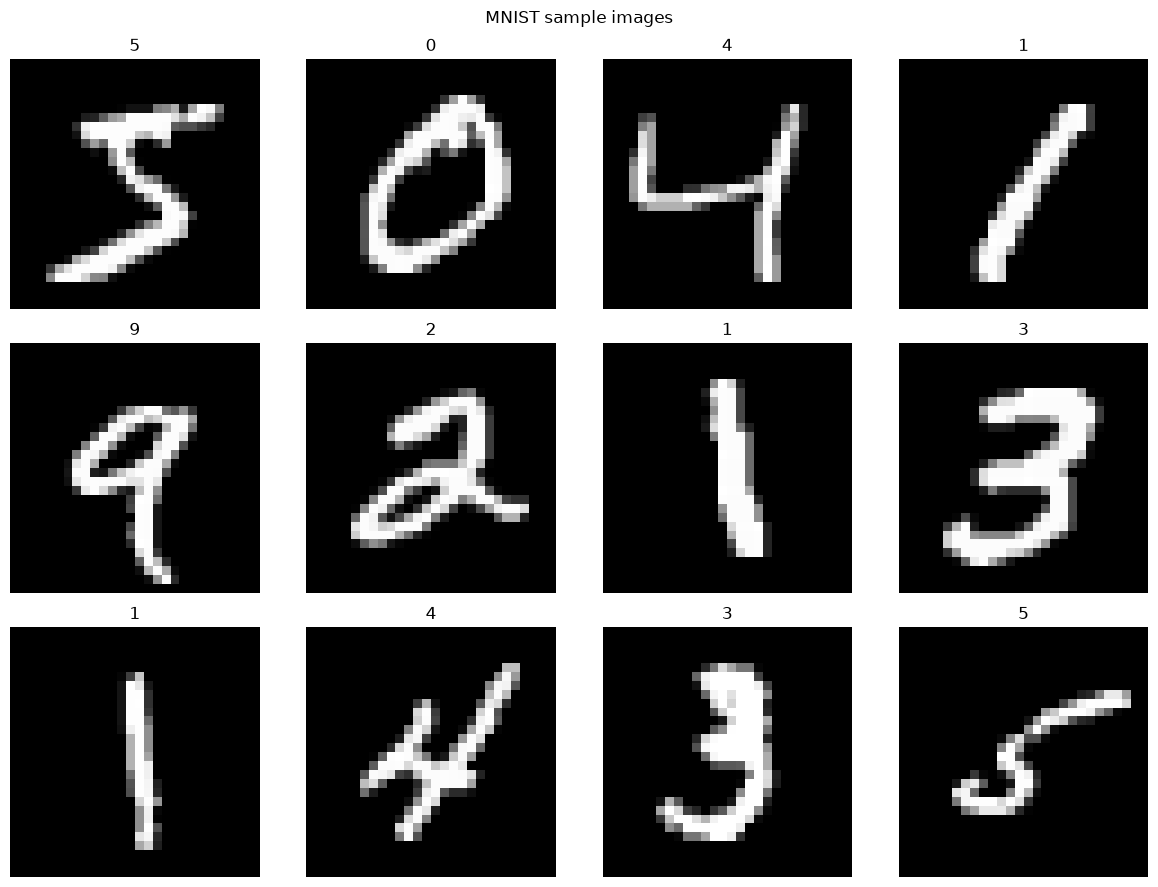

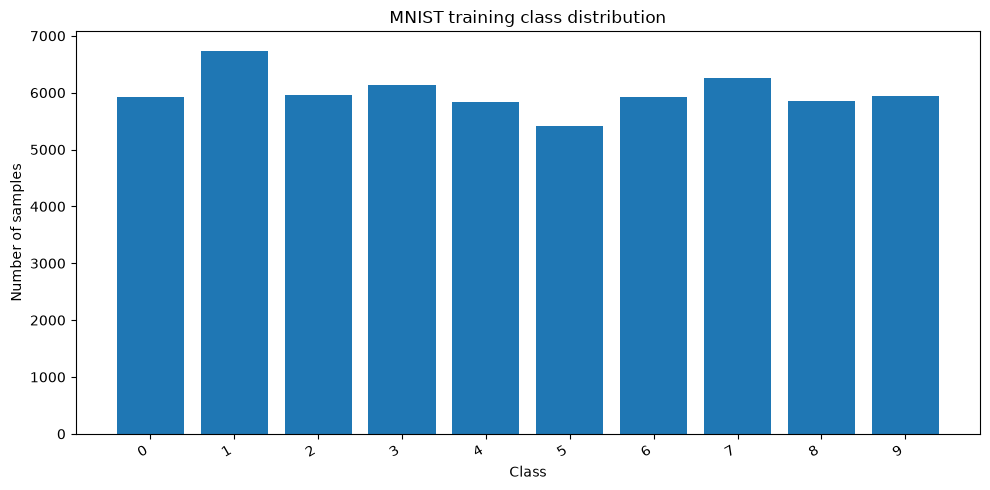

In [79]:
plot_image_grid(
    mnist_x_train[:100],
    mnist_y_train[:100],
    class_names=IMAGE_CLASS_NAMES["mnist"],
    n=12,
    title="MNIST sample images",
)

plot_class_distribution(
    mnist_y_train,
    class_names=IMAGE_CLASS_NAMES["mnist"],
    title="MNIST training class distribution",
)

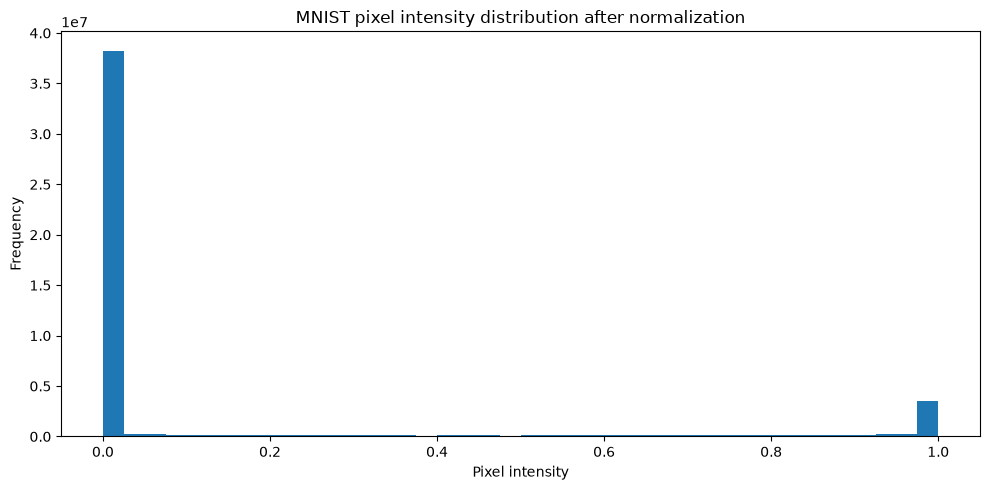

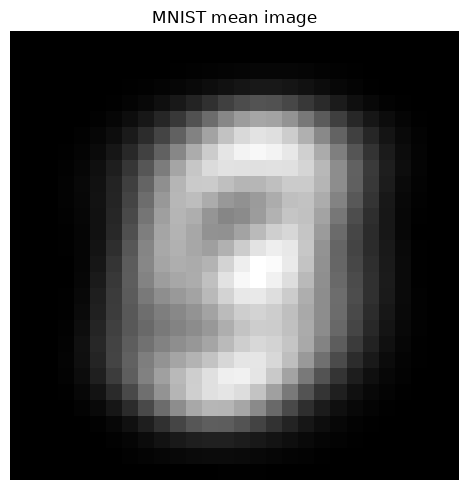

In [80]:
plt.figure(figsize=(10, 5))
plt.hist(mnist_x_train.reshape(-1), bins=40)
plt.title("MNIST pixel intensity distribution after normalization")
plt.xlabel("Pixel intensity")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

mean_mnist = mnist_x_train.mean(axis=0).squeeze()

plt.figure(figsize=(5, 5))
plt.imshow(mean_mnist, cmap="gray")
plt.title("MNIST mean image")
plt.axis("off")
plt.tight_layout()
plt.show()

## 7.1 MNIST split

The three implementations must use the same training and validation samples.

This makes the comparison meaningful because the models are not being tested on different data.

In [81]:
mnist_train_idx, mnist_val_idx = make_stratified_indices(
    mnist_y_train,
    val_size=VALIDATION_SIZE,
    seed=SEED,
    train_limit=COMPARISON_TRAIN_LIMIT if USE_COMPARISON_LIMITS else None,
    val_limit=COMPARISON_VAL_LIMIT if USE_COMPARISON_LIMITS else None,
)

mnist_X_tr = mnist_x_train[mnist_train_idx]
mnist_y_tr = mnist_y_train[mnist_train_idx]

mnist_X_val = mnist_x_train[mnist_val_idx]
mnist_y_val = mnist_y_train[mnist_val_idx]

mnist_X_te = mnist_x_test
mnist_y_te = mnist_y_test

report_split(
    "MNIST split",
    mnist_y_tr,
    mnist_y_val,
    mnist_y_te,
)

MNIST split
  train: 54000
  val  : 6000
  test : 10000
  train class counts: [5331 6068 5362 5518 5258 4879 5326 5638 5266 5354]
  val class counts  : [592 674 596 613 584 542 592 627 585 595]
  test class counts : [ 980 1135 1032 1010  982  892  958 1028  974 1009]


## 8. CNN architecture for MNIST

We will intentionally keep one simple architecture across all three implementations:

```text
Input
-> Conv2D
-> ReLU
-> MaxPool
-> Flatten
-> Linear
-> Class logits
```

The exact API syntax changes, but the computational structure does not.


In [82]:
MNIST_CHANNELS = 1
MNIST_HEIGHT = 28
MNIST_WIDTH = 28
MNIST_CLASSES = 10
MNIST_CONV_OUT = 16

MNIST_FLAT_FEATURES = MNIST_CONV_OUT * (MNIST_HEIGHT // 2) * (MNIST_WIDTH // 2)

print("MNIST classifier input features after Pool + Flatten:", MNIST_FLAT_FEATURES)
print("Expected shape after Conv + Pool:")
print(f"batch x {MNIST_CONV_OUT} x {MNIST_HEIGHT//2} x {MNIST_WIDTH//2}")

MNIST classifier input features after Pool + Flatten: 3136
Expected shape after Conv + Pool:
batch x 16 x 14 x 14


## 9. CNN from Scratch with NumPy

The Scratch implementation makes the operations visible.

The forward pass is written explicitly as a composition:

```text
Convolution
-> ReLU
-> MaxPool
-> Flatten
-> Linear
```

The training loop also makes the learning process visible:

```text
Forward
-> Loss
-> Backward
-> Parameter update
```

Unlike PyTorch and Keras, no CNN layer class is used to hide the convolution and pooling computations.

In [83]:
def im2col_nchw(x, kernel_size=3, padding=1, stride=1):
    x = np.asarray(x, dtype=np.float32)

    if x.ndim != 4:
        raise ValueError("Expected input with shape N x C x H x W.")

    n, c, h, w = x.shape
    kh = kw = kernel_size

    x_pad = np.pad(
        x,
        ((0, 0), (0, 0), (padding, padding), (padding, padding)),
        mode="constant",
    )

    windows = np.lib.stride_tricks.sliding_window_view(
        x_pad,
        (kh, kw),
        axis=(2, 3),
    )

    windows = windows[:, :, ::stride, ::stride, :, :]
    h_out = windows.shape[2]
    w_out = windows.shape[3]

    cols = windows.transpose(0, 2, 3, 1, 4, 5).reshape(
        n * h_out * w_out,
        c * kh * kw,
    )

    cache = {
        "input_shape": x.shape,
        "padding": padding,
        "stride": stride,
        "kernel_size": kernel_size,
        "h_out": h_out,
        "w_out": w_out,
    }

    return cols, cache


def col2im_nchw(dcols, cache):
    n, c, h, w = cache["input_shape"]
    padding = cache["padding"]
    stride = cache["stride"]
    kh = kw = cache["kernel_size"]
    h_out = cache["h_out"]
    w_out = cache["w_out"]

    dx_pad = np.zeros(
        (
            n,
            c,
            h + 2 * padding,
            w + 2 * padding,
        ),
        dtype=np.float32,
    )

    reshaped = dcols.reshape(
        n,
        h_out,
        w_out,
        c,
        kh,
        kw,
    ).transpose(0, 3, 1, 2, 4, 5)

    for i in range(kh):
        for j in range(kw):
            dx_pad[
                :,
                :,
                i : i + h_out * stride : stride,
                j : j + w_out * stride : stride,
            ] += reshaped[:, :, :, :, i, j]

    if padding > 0:
        return dx_pad[:, :, padding:-padding, padding:-padding]

    return dx_pad


def scratch_conv_forward(x, W, b, padding=1, stride=1):
    cols, cache = im2col_nchw(
        x,
        kernel_size=W.shape[2],
        padding=padding,
        stride=stride,
    )

    out = cols @ W.reshape(W.shape[0], -1).T
    out += b.reshape(1, -1)

    n = x.shape[0]
    h_out = cache["h_out"]
    w_out = cache["w_out"]
    filters = W.shape[0]

    out = out.reshape(n, h_out, w_out, filters).transpose(0, 3, 1, 2)

    cache["cols"] = cols
    cache["W"] = W
    cache["b"] = b

    return out, cache


def scratch_conv_backward(dout, cache):
    W = cache["W"]
    cols = cache["cols"]
    n, filters, h_out, w_out = dout.shape

    dout_flat = dout.transpose(0, 2, 3, 1).reshape(
        n * h_out * w_out,
        filters,
    )

    dW = dout_flat.T @ cols
    dW = dW.reshape(W.shape)

    db = dout_flat.sum(axis=0).reshape(W.shape[0])

    dcols = dout_flat @ W.reshape(W.shape[0], -1)
    dx = col2im_nchw(dcols, cache)

    return dx, dW, db


def scratch_relu_forward(x):
    out = np.maximum(0.0, x)
    return out, x


def scratch_relu_backward(dout, cache):
    x = cache
    return dout * (x > 0)


def scratch_maxpool_forward(x, pool_size=2, stride=2):
    n, c, h, w = x.shape

    if h % pool_size != 0 or w % pool_size != 0:
        raise ValueError("For this educational implementation, H and W must be divisible by pool size.")

    h_out = (h - pool_size) // stride + 1
    w_out = (w - pool_size) // stride + 1

    windows = np.lib.stride_tricks.sliding_window_view(
        x,
        (pool_size, pool_size),
        axis=(2, 3),
    )

    windows = windows[:, :, ::stride, ::stride, :, :]
    windows = windows[:, :, :h_out, :w_out, :, :]

    out = windows.max(axis=(-1, -2))

    cache = {
        "x_shape": x.shape,
        "windows": windows,
        "out": out,
        "pool_size": pool_size,
        "stride": stride,
    }

    return out, cache


def scratch_maxpool_backward(dout, cache):
    windows = cache["windows"]
    out = cache["out"]
    pool_size = cache["pool_size"]
    stride = cache["stride"]

    n, c, h_out, w_out = out.shape
    dx = np.zeros(cache["x_shape"], dtype=np.float32)

    mask = windows == out[:, :, :, :, None, None]

    grad = dout[:, :, :, :, None, None] * mask
    grad = grad.astype(np.float32)

    for i in range(pool_size):
        for j in range(pool_size):
            dx[
                :,
                :,
                i : i + h_out * stride : stride,
                j : j + w_out * stride : stride,
            ] += grad[:, :, :, :, i, j]

    return dx


def scratch_flatten_forward(x):
    return x.reshape(x.shape[0], -1), x.shape


def scratch_flatten_backward(dout, cache):
    return dout.reshape(cache)


def scratch_linear_forward(x, W, b):
    out = x @ W + b
    return out, x


def scratch_linear_backward(dout, cache, W):
    x = cache
    dW = x.T @ dout
    db = dout.sum(axis=0)
    dx = dout @ W.T
    return dx, dW, db

In [84]:
def softmax(logits):
    shifted = logits - logits.max(axis=1, keepdims=True)
    exp_values = np.exp(shifted)
    return exp_values / exp_values.sum(axis=1, keepdims=True)


def cross_entropy_loss_and_grad(logits, labels):
    probabilities = softmax(logits)
    batch_size = logits.shape[0]

    loss = -np.mean(
        np.log(
            np.clip(
                probabilities[np.arange(batch_size), labels],
                1e-12,
                1.0,
            )
        )
    )

    dlogits = probabilities.copy()
    dlogits[np.arange(batch_size), labels] -= 1.0
    dlogits /= batch_size

    return float(loss), dlogits, probabilities


def init_scratch_cnn(
    in_channels,
    height,
    width,
    num_classes,
    conv_out=16,
    kernel_size=3,
    seed=42,
):
    rng = np.random.default_rng(seed)

    fan_in = in_channels * kernel_size * kernel_size
    W1 = rng.normal(
        0,
        np.sqrt(2.0 / fan_in),
        size=(conv_out, in_channels, kernel_size, kernel_size),
    ).astype(np.float32)

    b1 = np.zeros(conv_out, dtype=np.float32)

    flat_features = conv_out * (height // 2) * (width // 2)

    W2 = rng.normal(
        0,
        np.sqrt(2.0 / flat_features),
        size=(flat_features, num_classes),
    ).astype(np.float32)

    b2 = np.zeros(num_classes, dtype=np.float32)

    return {
        "W1": W1,
        "b1": b1,
        "W2": W2,
        "b2": b2,
    }


def scratch_cnn_forward(x, params, training=True):
    z1, conv_cache = scratch_conv_forward(
        x,
        params["W1"],
        params["b1"],
        padding=1,
        stride=1,
    )

    a1, relu_cache = scratch_relu_forward(z1)

    p1, pool_cache = scratch_maxpool_forward(a1, pool_size=2, stride=2)

    flat, flat_cache = scratch_flatten_forward(p1)

    logits, linear_cache = scratch_linear_forward(
        flat,
        params["W2"],
        params["b2"],
    )

    cache = {
        "conv": conv_cache,
        "relu": relu_cache,
        "pool": pool_cache,
        "flatten": flat_cache,
        "linear": linear_cache,
    }

    return logits, cache


def scratch_cnn_backward(dlogits, params, cache):
    dflat, dW2, db2 = scratch_linear_backward(
        dlogits,
        cache["linear"],
        params["W2"],
    )

    dpool = scratch_flatten_backward(
        dflat,
        cache["flatten"],
    )

    drelu = scratch_maxpool_backward(
        dpool,
        cache["pool"],
    )

    dconv = scratch_relu_backward(
        drelu,
        cache["relu"],
    )

    _, dW1, db1 = scratch_conv_backward(
        dconv,
        cache["conv"],
    )

    grads = {
        "W1": dW1,
        "b1": db1,
        "W2": dW2,
        "b2": db2,
    }

    return grads


class AdamNumpy:
    def __init__(self, params, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.t = 0

        self.m = {k: np.zeros_like(v) for k, v in params.items()}
        self.v = {k: np.zeros_like(v) for k, v in params.items()}

    def step(self, params, grads):
        self.t += 1

        for key in params:
            self.m[key] = (
                self.beta1 * self.m[key]
                + (1 - self.beta1) * grads[key]
            )

            self.v[key] = (
                self.beta2 * self.v[key]
                + (1 - self.beta2) * np.square(grads[key])
            )

            m_hat = self.m[key] / (1 - self.beta1 ** self.t)
            v_hat = self.v[key] / (1 - self.beta2 ** self.t)

            params[key] -= (
                self.lr
                * m_hat
                / (np.sqrt(v_hat) + self.eps)
            )


def minibatches(X, y, batch_size=128, shuffle=True, seed=42):
    indices = np.arange(len(X))

    if shuffle:
        rng = np.random.default_rng(seed)
        rng.shuffle(indices)

    for start in range(0, len(indices), batch_size):
        batch_idx = indices[start:start + batch_size]
        yield X[batch_idx], y[batch_idx]


def train_scratch_cnn(
    X_train,
    y_train,
    X_val,
    y_val,
    in_channels,
    height,
    width,
    num_classes,
    epochs=5,
    batch_size=128,
    lr=1e-3,
    seed=42,
):
    params = init_scratch_cnn(
        in_channels,
        height,
        width,
        num_classes,
        conv_out=16,
        seed=seed,
    )

    optimizer = AdamNumpy(params, lr=lr)

    history = {
        "loss": [],
        "accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
    }

    best_state = None
    best_val = float("inf")

    start_time = time.perf_counter()

    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        seen = 0

        for batch_X, batch_y in minibatches(
            X_train,
            y_train,
            batch_size=batch_size,
            shuffle=True,
            seed=seed + epoch,
        ):
            logits, cache = scratch_cnn_forward(
                batch_X,
                params,
                training=True,
            )

            loss, dlogits, probabilities = cross_entropy_loss_and_grad(
                logits,
                batch_y,
            )

            grads = scratch_cnn_backward(
                dlogits,
                params,
                cache,
            )

            optimizer.step(params, grads)

            predictions = np.argmax(probabilities, axis=1)

            running_loss += loss * len(batch_X)
            correct += int(np.sum(predictions == batch_y))
            seen += len(batch_X)

        train_loss = running_loss / seen
        train_accuracy = correct / seen

        val_logits, _ = scratch_cnn_forward(
            X_val,
            params,
            training=False,
        )
        val_loss, _, val_prob = cross_entropy_loss_and_grad(
            val_logits,
            y_val,
        )
        val_pred = np.argmax(val_prob, axis=1)
        val_accuracy = accuracy_score(y_val, val_pred)

        history["loss"].append(float(train_loss))
        history["accuracy"].append(float(train_accuracy))
        history["val_loss"].append(float(val_loss))
        history["val_accuracy"].append(float(val_accuracy))

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"loss={train_loss:.4f} | "
            f"acc={train_accuracy:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_acc={val_accuracy:.4f}"
        )

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.copy() for k, v in params.items()}

    elapsed = time.perf_counter() - start_time

    params = best_state

    return params, history, elapsed


def predict_scratch_cnn(X, params, batch_size=256):
    all_prob = []

    for start in range(0, len(X), batch_size):
        batch_X = X[start:start + batch_size]

        logits, _ = scratch_cnn_forward(
            batch_X,
            params,
            training=False,
        )

        all_prob.append(softmax(logits))

    probabilities = np.concatenate(all_prob, axis=0)
    predictions = np.argmax(probabilities, axis=1)

    return predictions, probabilities

## 9.1 Train the Scratch CNN on MNIST

The default settings are intentionally small enough for a normal computer.

The implementation is mathematically explicit:

- convolution uses NumPy tensor operations;
- ReLU is a direct nonlinear function;
- max pooling is implemented explicitly;
- gradients are computed manually;
- Adam updates the parameters.

This is the Scratch interpretation of the phrase "CNN is a composition of functions".

Epoch 1/5 | loss=0.3324 | acc=0.9091 | val_loss=0.1624 | val_acc=0.9567
Epoch 2/5 | loss=0.1197 | acc=0.9663 | val_loss=0.1085 | val_acc=0.9698
Epoch 3/5 | loss=0.0840 | acc=0.9763 | val_loss=0.0931 | val_acc=0.9735
Epoch 4/5 | loss=0.0677 | acc=0.9810 | val_loss=0.0916 | val_acc=0.9723
Epoch 5/5 | loss=0.0584 | acc=0.9833 | val_loss=0.0782 | val_acc=0.9768


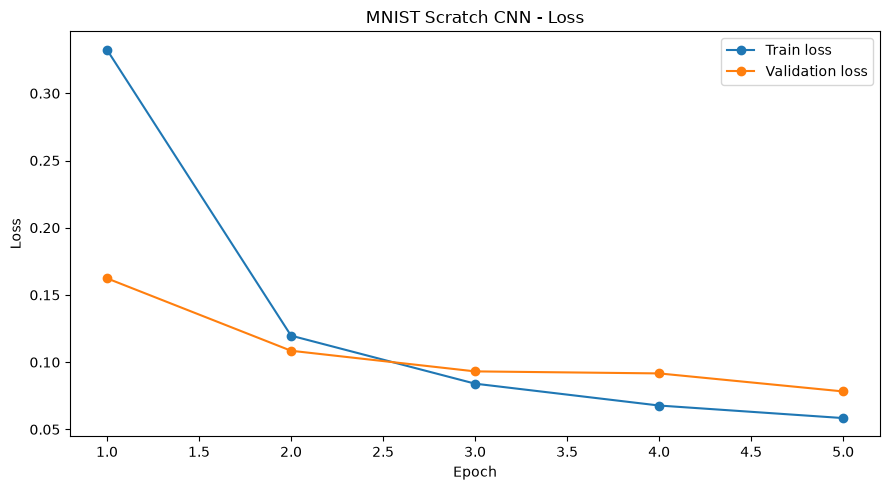

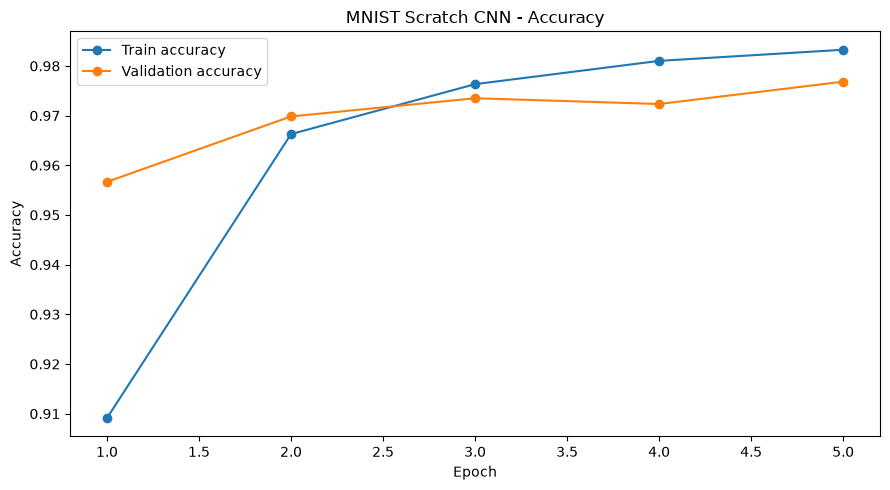

In [85]:
set_global_seed(SEED)

mnist_scratch_params, mnist_scratch_history, mnist_scratch_time = train_scratch_cnn(
    mnist_X_tr,
    mnist_y_tr,
    mnist_X_val,
    mnist_y_val,
    in_channels=MNIST_CHANNELS,
    height=MNIST_HEIGHT,
    width=MNIST_WIDTH,
    num_classes=MNIST_CLASSES,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LEARNING_RATE,
    seed=SEED,
)

plot_training_history(
    mnist_scratch_history,
    title="MNIST Scratch CNN",
)

accuracy                     0.979000
precision_macro              0.978987
recall_macro                 0.978883
f1_macro                     0.978831
precision_weighted           0.979139
recall_weighted              0.979000
f1_weighted                  0.978967
mean_confidence              0.974335
parameters               31530.000000
training_time_seconds      139.493802
epochs                       5.000000
dtype: float64


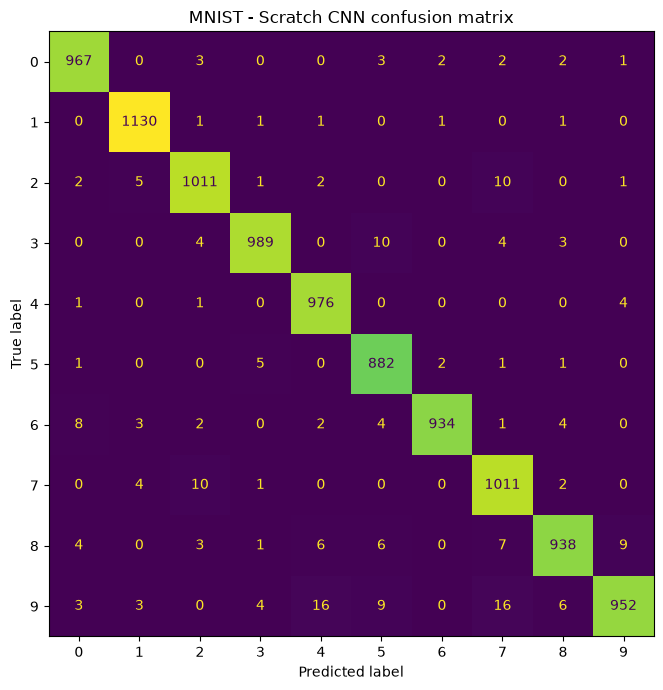

<Figure size 1000x600 with 0 Axes>

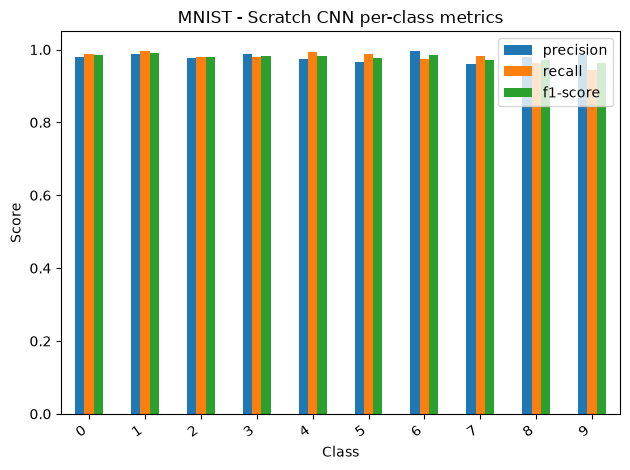

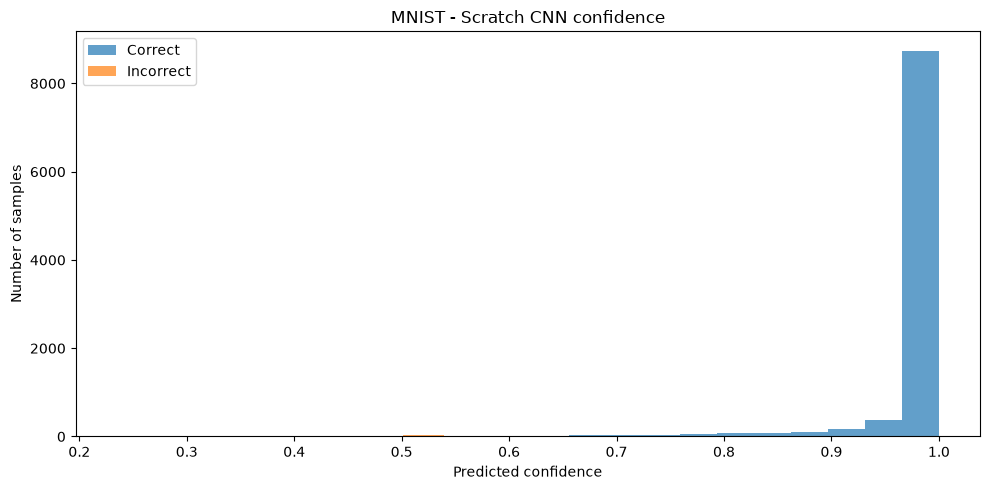

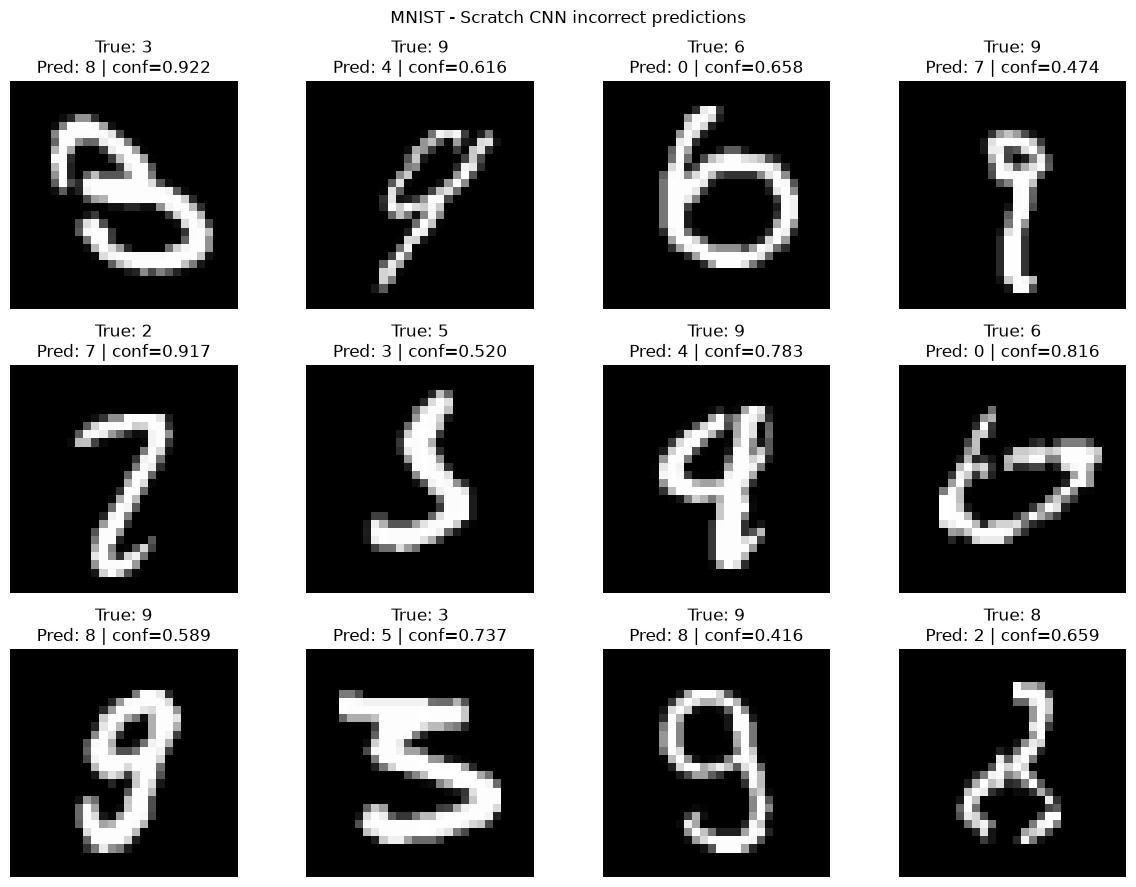

In [86]:
mnist_scratch_pred, mnist_scratch_prob = predict_scratch_cnn(
    mnist_X_te,
    mnist_scratch_params,
)

mnist_scratch_metrics = compute_classification_metrics(
    mnist_y_te,
    mnist_scratch_pred,
    mnist_scratch_prob,
)

mnist_scratch_metrics["parameters"] = count_numpy_parameters(mnist_scratch_params)
mnist_scratch_metrics["training_time_seconds"] = mnist_scratch_time
mnist_scratch_metrics["epochs"] = EPOCHS

print(pd.Series(mnist_scratch_metrics))

show_confusion_matrix(
    mnist_y_te,
    mnist_scratch_pred,
    IMAGE_CLASS_NAMES["mnist"],
    "MNIST - Scratch CNN confusion matrix",
)

show_classification_report(
    mnist_y_te,
    mnist_scratch_pred,
    IMAGE_CLASS_NAMES["mnist"],
    "MNIST - Scratch CNN per-class metrics",
)

show_confidence_distribution(
    mnist_scratch_prob,
    mnist_y_te == mnist_scratch_pred,
    "MNIST - Scratch CNN confidence",
)

show_prediction_examples(
    mnist_x_test,
    mnist_y_te,
    mnist_scratch_pred,
    mnist_scratch_prob,
    IMAGE_CLASS_NAMES["mnist"],
    "MNIST - Scratch CNN incorrect predictions",
    only_wrong=True,
    n=12,
)

## 10. CNN with PyTorch

The conceptual model stays the same:

```text
Conv -> ReLU -> Pool -> Flatten -> Linear
```

PyTorch changes the abstraction:

- `nn.Conv2d` represents convolution.
- `nn.ReLU` represents the nonlinearity.
- `nn.MaxPool2d` represents downsampling.
- `nn.Flatten` converts a tensor into a vector.
- `nn.Linear` performs the final affine transformation.
- `loss.backward()` computes gradients automatically.
- `optimizer.step()` updates parameters.

The `forward()` method makes the data flow explicit.

In [87]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch device:", DEVICE)


class SimpleCNNPyTorch(nn.Module):
    def __init__(self, in_channels, height, width, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        flat_features = 16 * (height // 2) * (width // 2)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_features, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


def create_torch_loaders(X_train, y_train, X_val, y_val, X_test, y_test, batch_size=128):
    train_ds = TensorDataset(
        torch.from_numpy(X_train),
        torch.from_numpy(y_train),
    )
    val_ds = TensorDataset(
        torch.from_numpy(X_val),
        torch.from_numpy(y_val),
    )
    test_ds = TensorDataset(
        torch.from_numpy(X_test),
        torch.from_numpy(y_test),
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader


def train_torch_cnn(
    X_train, y_train, X_val, y_val, X_test, y_test,
    in_channels, height, width, num_classes,
    epochs=5, batch_size=128, lr=1e-3, seed=42
):
    set_global_seed(seed)

    model = SimpleCNNPyTorch(
        in_channels,
        height,
        width,
        num_classes,
    ).to(DEVICE)

    train_loader, val_loader, test_loader = create_torch_loaders(
        X_train, y_train,
        X_val, y_val,
        X_test, y_test,
        batch_size=batch_size,
    )

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
    )

    history = {
        "loss": [],
        "accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
    }

    best_state = None
    best_val_loss = float("inf")

    start_time = time.perf_counter()

    for epoch in range(epochs):
        model.train()

        train_loss_sum = 0.0
        train_correct = 0
        train_seen = 0

        for images, labels in train_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * len(images)
            train_correct += int((outputs.argmax(dim=1) == labels).sum().item())
            train_seen += len(images)

        model.eval()

        val_loss_sum = 0.0
        val_correct = 0
        val_seen = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(DEVICE)
                labels = labels.to(DEVICE)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss_sum += loss.item() * len(images)
                val_correct += int((outputs.argmax(dim=1) == labels).sum().item())
                val_seen += len(images)

        train_loss = train_loss_sum / train_seen
        train_acc = train_correct / train_seen

        val_loss = val_loss_sum / val_seen
        val_acc = val_correct / val_seen

        history["loss"].append(float(train_loss))
        history["accuracy"].append(float(train_acc))
        history["val_loss"].append(float(val_loss))
        history["val_accuracy"].append(float(val_acc))

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"loss={train_loss:.4f} | "
            f"acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_acc={val_acc:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

    elapsed = time.perf_counter() - start_time

    model.load_state_dict(best_state)
    return model, history, elapsed, test_loader


def predict_torch(model, X, batch_size=256):
    loader = DataLoader(
        TensorDataset(torch.from_numpy(X)),
        batch_size=batch_size,
        shuffle=False,
    )

    model.eval()
    all_prob = []

    with torch.no_grad():
        for (images,) in loader:
            images = images.to(DEVICE)
            logits = model(images)
            probabilities = torch.softmax(logits, dim=1)
            all_prob.append(probabilities.cpu().numpy())

    probabilities = np.concatenate(all_prob, axis=0)
    predictions = np.argmax(probabilities, axis=1)

    return predictions, probabilities

PyTorch device: cpu


Epoch 1/5 | loss=0.4405 | acc=0.8808 | val_loss=0.2268 | val_acc=0.9347
Epoch 2/5 | loss=0.1762 | acc=0.9500 | val_loss=0.1610 | val_acc=0.9558
Epoch 3/5 | loss=0.1270 | acc=0.9641 | val_loss=0.1329 | val_acc=0.9647
Epoch 4/5 | loss=0.0998 | acc=0.9717 | val_loss=0.1071 | val_acc=0.9702
Epoch 5/5 | loss=0.0825 | acc=0.9764 | val_loss=0.0927 | val_acc=0.9757


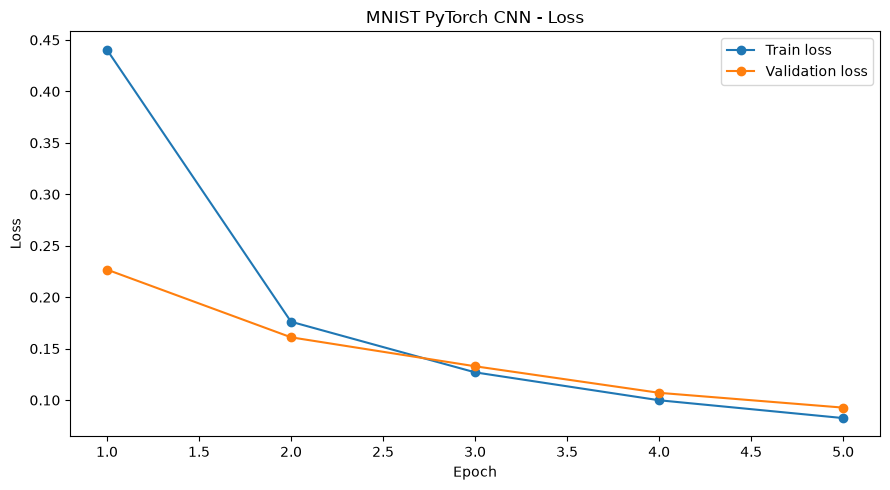

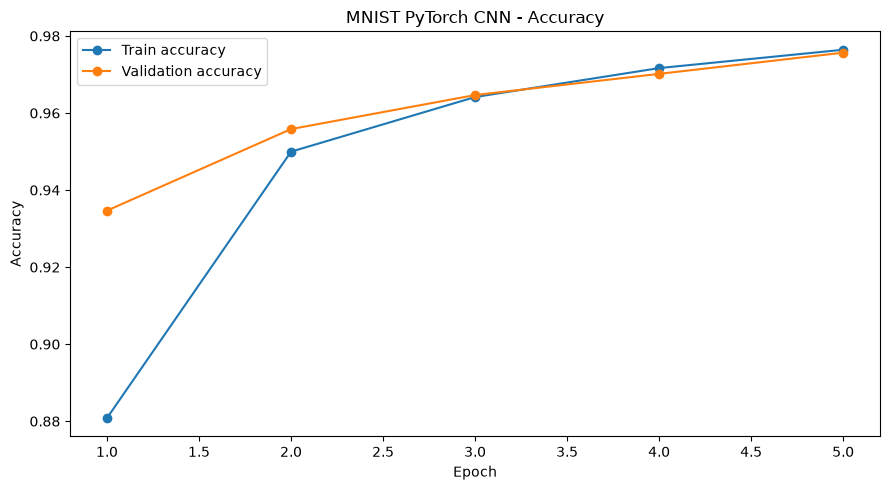

In [88]:
mnist_torch_model, mnist_torch_history, mnist_torch_time, _ = train_torch_cnn(
    mnist_X_tr,
    mnist_y_tr,
    mnist_X_val,
    mnist_y_val,
    mnist_X_te,
    mnist_y_te,
    in_channels=MNIST_CHANNELS,
    height=MNIST_HEIGHT,
    width=MNIST_WIDTH,
    num_classes=MNIST_CLASSES,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LEARNING_RATE,
    seed=SEED,
)

plot_training_history(
    mnist_torch_history,
    title="MNIST PyTorch CNN",
)

accuracy                     0.975300
precision_macro              0.975397
recall_macro                 0.975098
f1_macro                     0.975205
precision_weighted           0.975363
recall_weighted              0.975300
f1_weighted                  0.975289
mean_confidence              0.969117
parameters               31530.000000
training_time_seconds       26.547899
epochs                       5.000000
dtype: float64


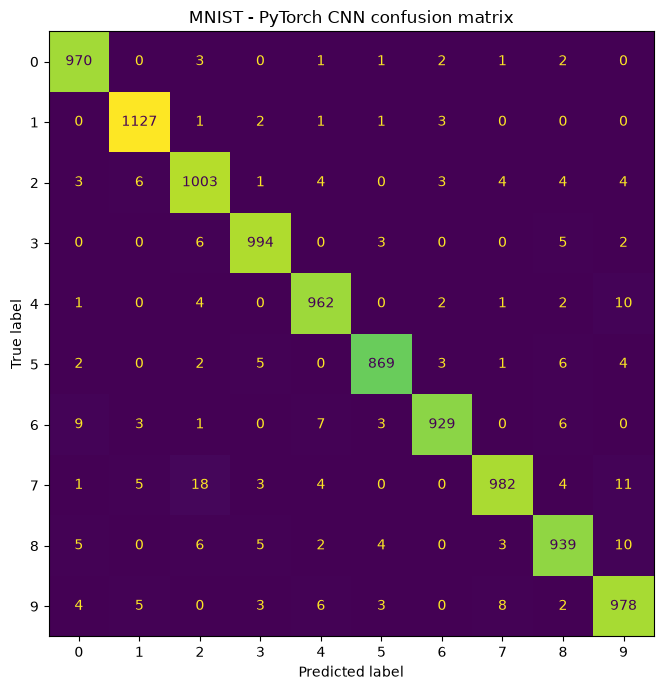

<Figure size 1000x600 with 0 Axes>

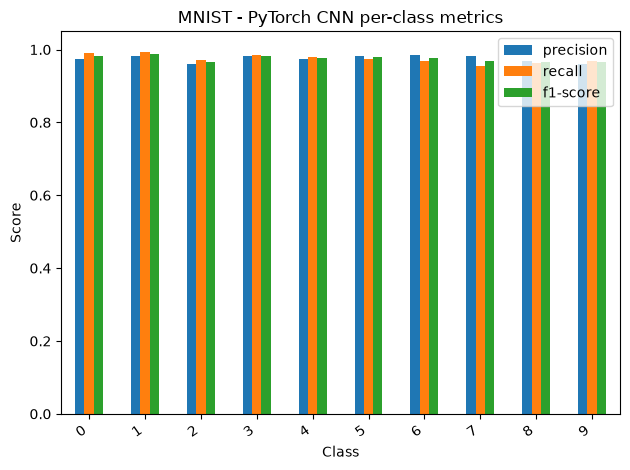

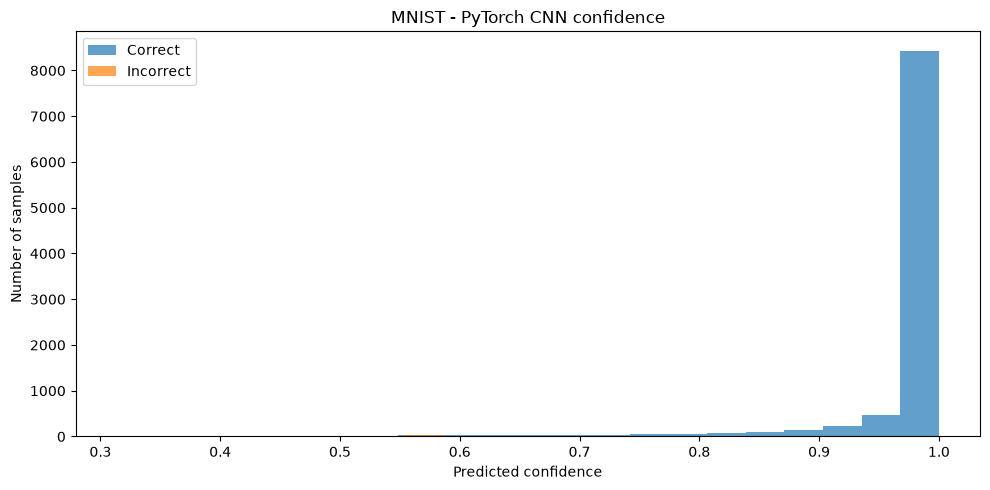

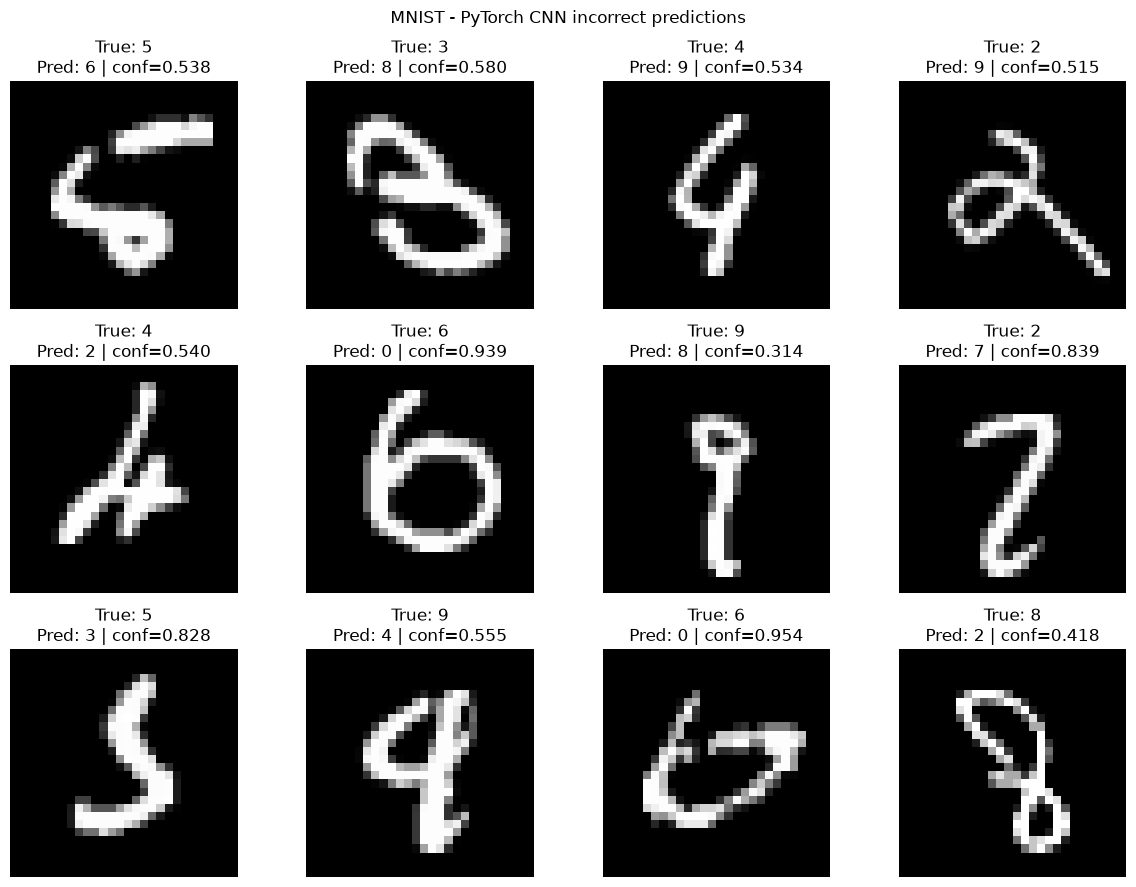

In [89]:
mnist_torch_pred, mnist_torch_prob = predict_torch(
    mnist_torch_model,
    mnist_X_te,
)

mnist_torch_metrics = compute_classification_metrics(
    mnist_y_te,
    mnist_torch_pred,
    mnist_torch_prob,
)

mnist_torch_metrics["parameters"] = int(
    sum(p.numel() for p in mnist_torch_model.parameters())
)
mnist_torch_metrics["training_time_seconds"] = mnist_torch_time
mnist_torch_metrics["epochs"] = EPOCHS

print(pd.Series(mnist_torch_metrics))

show_confusion_matrix(
    mnist_y_te,
    mnist_torch_pred,
    IMAGE_CLASS_NAMES["mnist"],
    "MNIST - PyTorch CNN confusion matrix",
)

show_classification_report(
    mnist_y_te,
    mnist_torch_pred,
    IMAGE_CLASS_NAMES["mnist"],
    "MNIST - PyTorch CNN per-class metrics",
)

show_confidence_distribution(
    mnist_torch_prob,
    mnist_y_te == mnist_torch_pred,
    "MNIST - PyTorch CNN confidence",
)

show_prediction_examples(
    mnist_x_test,
    mnist_y_te,
    mnist_torch_pred,
    mnist_torch_prob,
    IMAGE_CLASS_NAMES["mnist"],
    "MNIST - PyTorch CNN incorrect predictions",
    only_wrong=True,
    n=12,
)

## 11. CNN with TensorFlow/Keras

Keras provides a higher level of abstraction.

The same architecture becomes:

```text
Conv2D -> ReLU -> MaxPooling2D -> Flatten -> Dense
```

The important question from Lecture 04 is:

> What computation is hidden inside `model.fit()`?

Keras hides the training loop, automatic differentiation and parameter updates behind the training API.

The mathematics remains the same.

In [90]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)


def build_keras_cnn(in_channels, height, width, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(height, width, in_channels)),
        layers.Conv2D(16, kernel_size=3, padding="same", activation="relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Flatten(),
        layers.Dense(num_classes),
    ])

    return model


def train_keras_cnn(
    X_train, y_train, X_val, y_val,
    in_channels, height, width, num_classes,
    epochs=5, batch_size=128, lr=1e-3, seed=42
):
    set_global_seed(seed)

    model = build_keras_cnn(
        in_channels,
        height,
        width,
        num_classes,
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"],
    )

    start_time = time.perf_counter()

    history_obj = model.fit(
        np.transpose(X_train, (0, 2, 3, 1)),
        y_train,
        validation_data=(
            np.transpose(X_val, (0, 2, 3, 1)),
            y_val,
        ),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1,
    )

    elapsed = time.perf_counter() - start_time

    history = {
        "loss": history_obj.history["loss"],
        "accuracy": history_obj.history["accuracy"],
        "val_loss": history_obj.history["val_loss"],
        "val_accuracy": history_obj.history["val_accuracy"],
    }

    return model, history, elapsed

TensorFlow: 2.21.0


Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8889 - loss: 0.4237 - val_accuracy: 0.9430 - val_loss: 0.2057
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9551 - loss: 0.1566 - val_accuracy: 0.9627 - val_loss: 0.1385
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9691 - loss: 0.1095 - val_accuracy: 0.9693 - val_loss: 0.1102
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9757 - loss: 0.0876 - val_accuracy: 0.9727 - val_loss: 0.0953
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9790 - loss: 0.0749 - val_accuracy: 0.9755 - val_loss: 0.0869


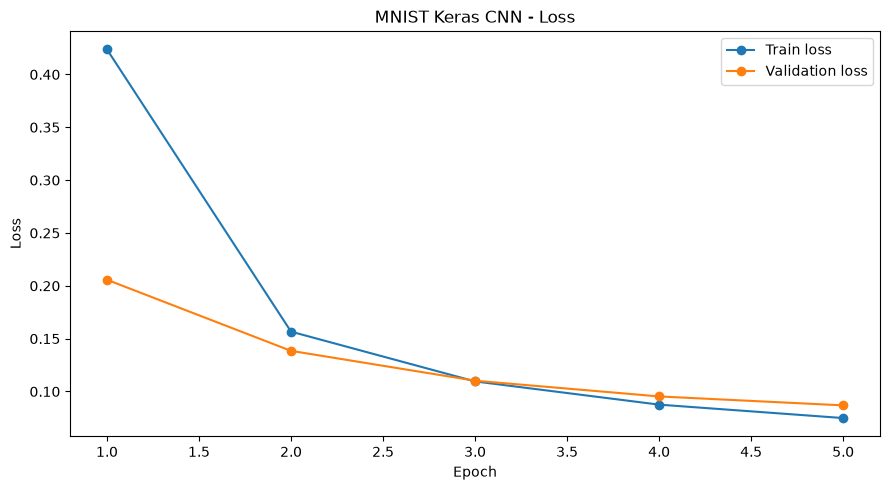

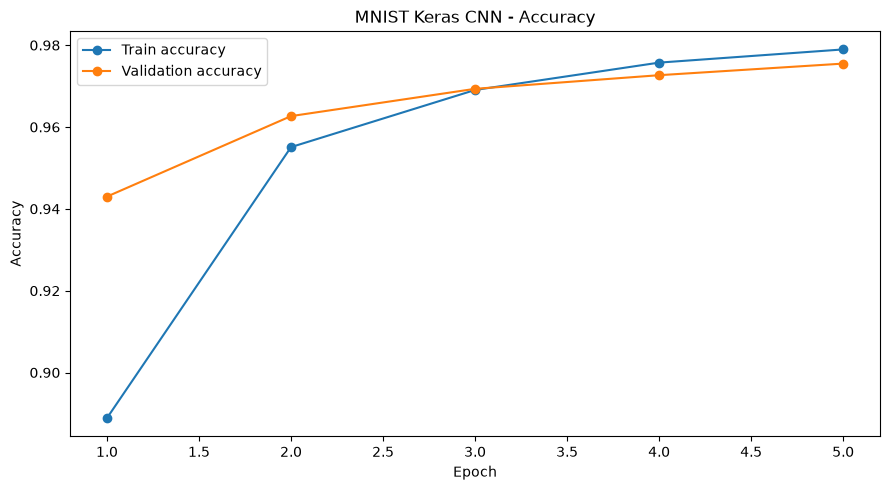

In [91]:
mnist_keras_model, mnist_keras_history, mnist_keras_time = train_keras_cnn(
    mnist_X_tr,
    mnist_y_tr,
    mnist_X_val,
    mnist_y_val,
    in_channels=MNIST_CHANNELS,
    height=MNIST_HEIGHT,
    width=MNIST_WIDTH,
    num_classes=MNIST_CLASSES,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LEARNING_RATE,
    seed=SEED,
)

plot_training_history(
    mnist_keras_history,
    title="MNIST Keras CNN",
)

accuracy                     0.978000
precision_macro              0.978049
recall_macro                 0.977922
f1_macro                     0.977931
precision_weighted           0.978043
recall_weighted              0.978000
f1_weighted                  0.977967
mean_confidence              0.970449
parameters               31530.000000
training_time_seconds       19.982689
epochs                       5.000000
dtype: float64


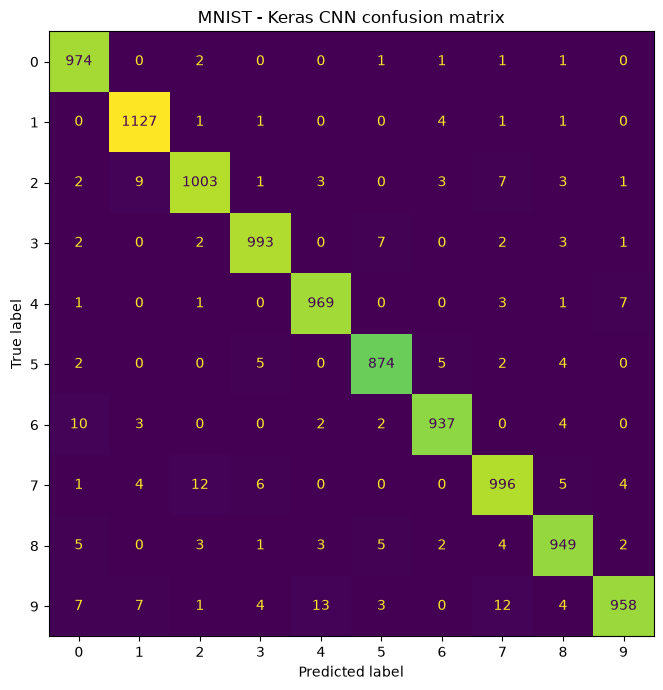

<Figure size 1000x600 with 0 Axes>

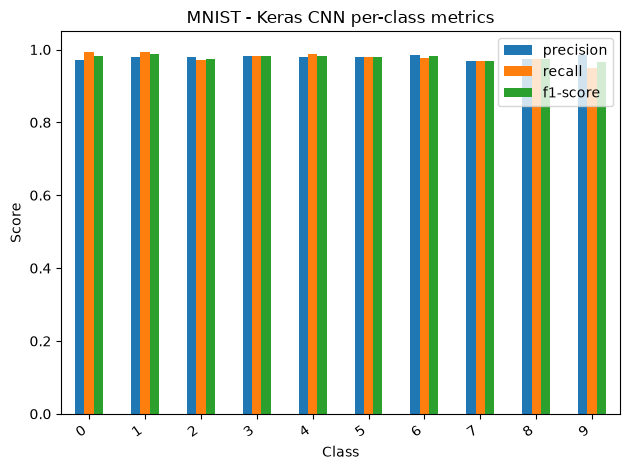

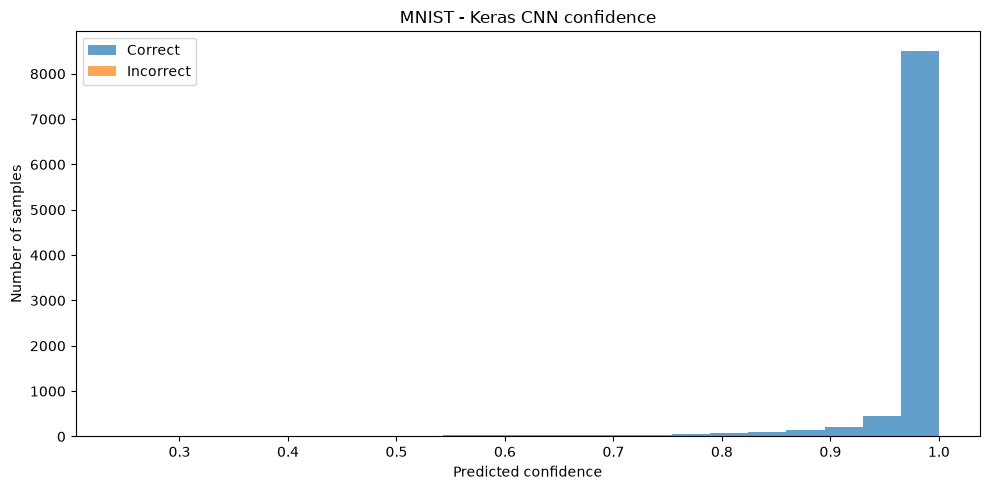

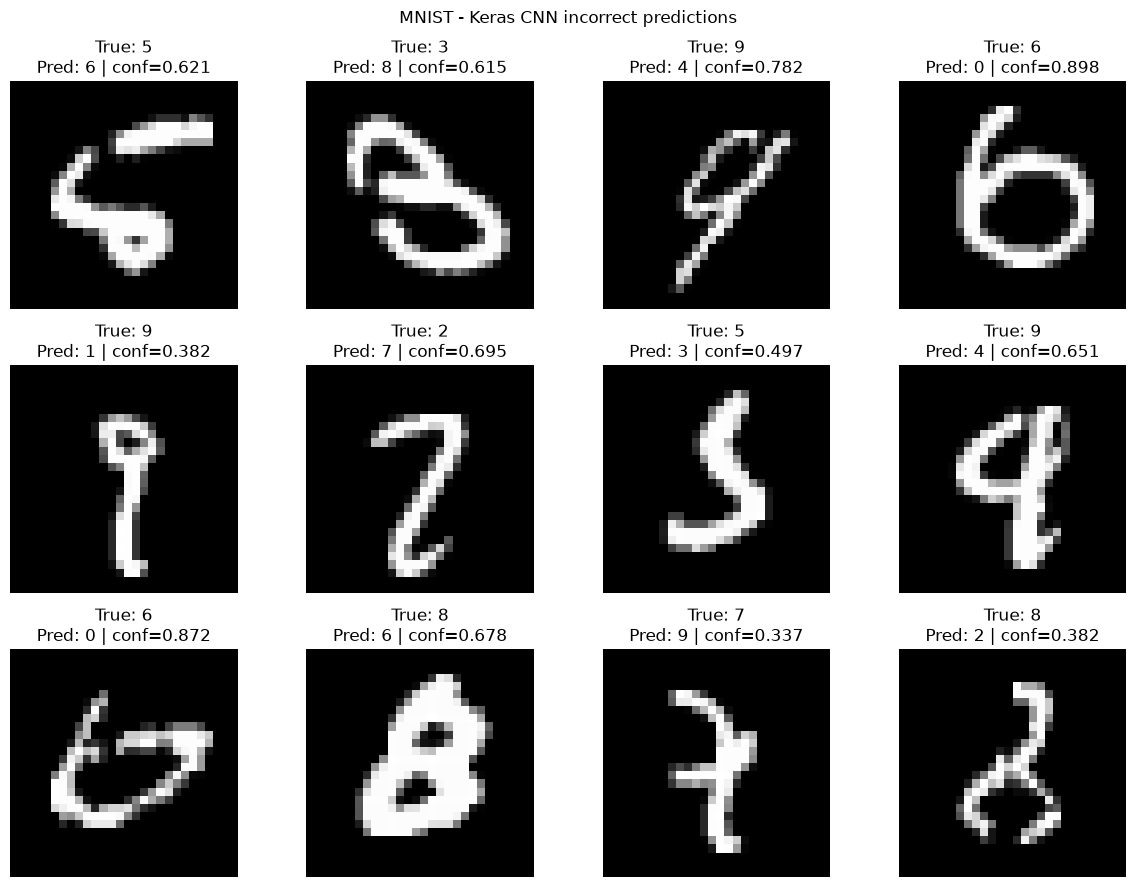

In [92]:
def predict_keras(model, X):
    logits = model.predict(
        np.transpose(X, (0, 2, 3, 1)),
        verbose=0,
    )

    probabilities = softmax(logits)
    predictions = np.argmax(probabilities, axis=1)

    return predictions, probabilities


mnist_keras_pred, mnist_keras_prob = predict_keras(
    mnist_keras_model,
    mnist_X_te,
)

mnist_keras_metrics = compute_classification_metrics(
    mnist_y_te,
    mnist_keras_pred,
    mnist_keras_prob,
)

mnist_keras_metrics["parameters"] = int(mnist_keras_model.count_params())
mnist_keras_metrics["training_time_seconds"] = mnist_keras_time
mnist_keras_metrics["epochs"] = EPOCHS

print(pd.Series(mnist_keras_metrics))

show_confusion_matrix(
    mnist_y_te,
    mnist_keras_pred,
    IMAGE_CLASS_NAMES["mnist"],
    "MNIST - Keras CNN confusion matrix",
)

show_classification_report(
    mnist_y_te,
    mnist_keras_pred,
    IMAGE_CLASS_NAMES["mnist"],
    "MNIST - Keras CNN per-class metrics",
)

show_confidence_distribution(
    mnist_keras_prob,
    mnist_y_te == mnist_keras_pred,
    "MNIST - Keras CNN confidence",
)

show_prediction_examples(
    mnist_x_test,
    mnist_y_te,
    mnist_keras_pred,
    mnist_keras_prob,
    IMAGE_CLASS_NAMES["mnist"],
    "MNIST - Keras CNN incorrect predictions",
    only_wrong=True,
    n=12,
)

## 12. MNIST representation visualization

CNNs are useful because they learn visual features.

The following visualization inspects the first convolution layer from PyTorch.

This is directly related to the conceptual hierarchy:

```text
pixels -> edges -> textures -> parts -> objects -> class
```

The hierarchy is a teaching model, not a strict guarantee for every CNN.

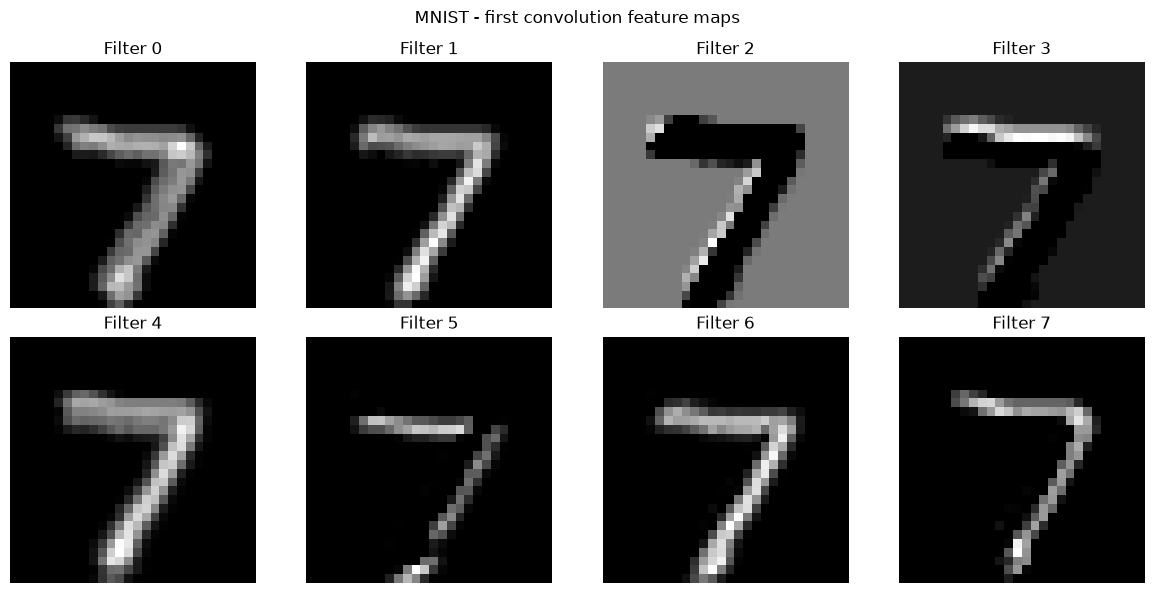

In [93]:
sample_index = 0
sample = torch.from_numpy(mnist_X_te[sample_index:sample_index + 1]).to(DEVICE)

mnist_torch_model.eval()

with torch.no_grad():
    feature_map = mnist_torch_model.features[0](sample)
    feature_map = torch.relu(feature_map).cpu().numpy()[0]

num_maps = min(8, feature_map.shape[0])

plt.figure(figsize=(12, 6))
for i in range(num_maps):
    ax = plt.subplot(2, 4, i + 1)
    ax.imshow(feature_map[i], cmap="gray")
    ax.set_title(f"Filter {i}")
    ax.axis("off")

plt.suptitle("MNIST - first convolution feature maps")
plt.tight_layout()
plt.show()

## 13. MNIST framework comparison

The same architecture has now been implemented three times.

Expected conceptual mapping:

| Concept | Scratch | Keras | PyTorch |
|---|---|---|---|
| Convolution | manual `conv2d` | `Conv2D` | `nn.Conv2d` |
| Activation | manual ReLU | `ReLU` or activation argument | `nn.ReLU` |
| Pooling | manual max pool | `MaxPooling2D` | `MaxPool2d` |
| Flatten | manual reshape | `Flatten` | `nn.Flatten` |
| Dense | manual matrix multiplication | `Dense` | `nn.Linear` |
| Loss | manual cross entropy | Keras loss | `CrossEntropyLoss` |
| Gradient | manual backpropagation | automatic | autograd |
| Optimizer | manual parameter update | optimizer API | optimizer API |
| Training loop | explicit | mostly hidden by `fit` | explicit |

In [94]:
mnist_results = pd.DataFrame([
    {"dataset": "MNIST", "framework": "Scratch", **mnist_scratch_metrics},
    {"dataset": "MNIST", "framework": "PyTorch", **mnist_torch_metrics},
    {"dataset": "MNIST", "framework": "Keras", **mnist_keras_metrics},
])

mnist_results = mnist_results[
    [
        "dataset",
        "framework",
        "accuracy",
        "precision_macro",
        "recall_macro",
        "f1_macro",
        "mean_confidence",
        "parameters",
        "training_time_seconds",
        "epochs",
    ]
]

mnist_results

,dataset,framework,accuracy,precision_macro,recall_macro,f1_macro,mean_confidence,parameters,training_time_seconds,epochs
0,MNIST,Scratch,0.9790,0.978987,0.978883,0.978831,0.974335,31530,139.493802,5
1,MNIST,PyTorch,0.9753,0.975397,0.975098,0.975205,0.969117,31530,26.547899,5
2,MNIST,Keras,0.9780,0.978049,0.977922,0.977931,0.970449,31530,19.982689,5


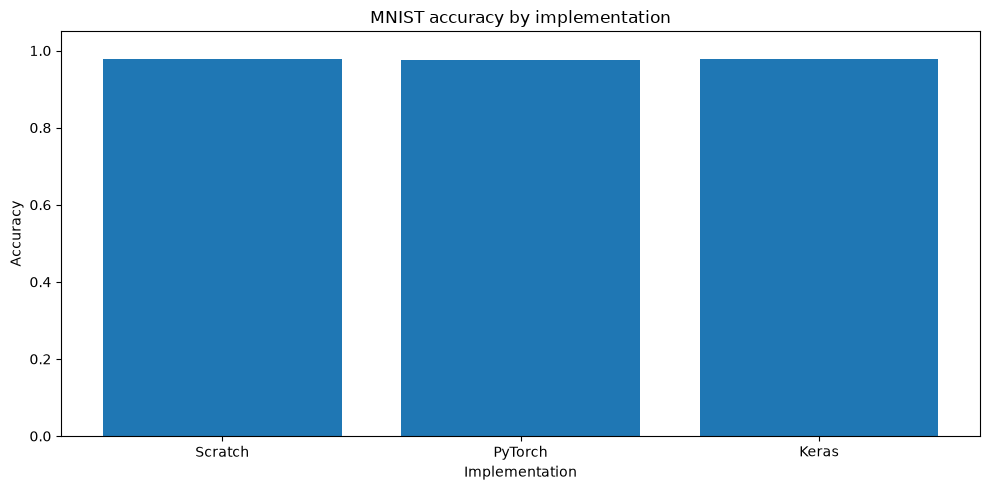

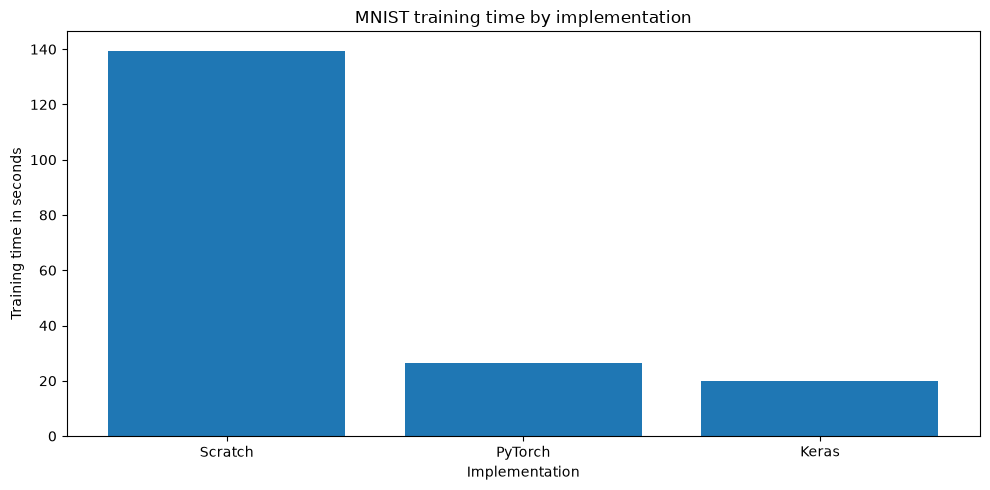

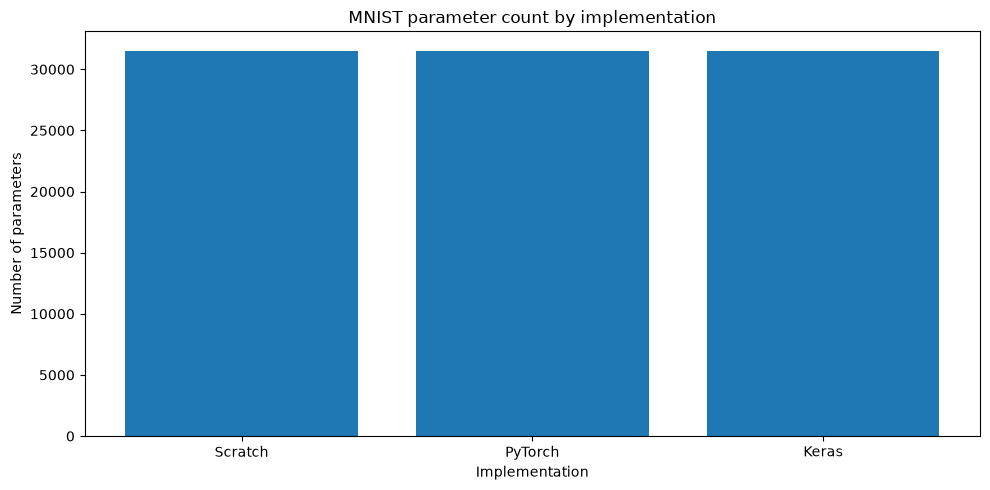

In [95]:
plt.figure(figsize=(10, 5))
plt.bar(
    mnist_results["framework"],
    mnist_results["accuracy"],
)
plt.title("MNIST accuracy by implementation")
plt.xlabel("Implementation")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(
    mnist_results["framework"],
    mnist_results["training_time_seconds"],
)
plt.title("MNIST training time by implementation")
plt.xlabel("Implementation")
plt.ylabel("Training time in seconds")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(
    mnist_results["framework"],
    mnist_results["parameters"],
)
plt.title("MNIST parameter count by implementation")
plt.xlabel("Implementation")
plt.ylabel("Number of parameters")
plt.tight_layout()
plt.show()

# Part C - Dataset 2: CIFAR-10

## 14. Load CIFAR-10

CIFAR-10 gives us an important contrast with MNIST:

- MNIST: one grayscale channel.
- CIFAR-10: three RGB channels.
- MNIST: 28 x 28.
- CIFAR-10: 32 x 32.

  Data source: https://www.tensorflow.org/datasets/catalog/cifar10

This lets us inspect how the number of channels affects tensor shape and parameter count.

In [96]:
cifar_data = np.load(cifar_npz)

cifar_x_train_raw = cifar_data["x_train"]
cifar_y_train = cifar_data["y_train"].astype(np.int64).reshape(-1)

cifar_x_test_raw = cifar_data["x_test"]
cifar_y_test = cifar_data["y_test"].astype(np.int64).reshape(-1)

# Convert from N x H x W x C to N x C x H x W.
cifar_x_train = cifar_x_train_raw.astype(np.float32) / 255.0
cifar_x_test = cifar_x_test_raw.astype(np.float32) / 255.0

cifar_x_train = np.transpose(cifar_x_train, (0, 3, 1, 2))
cifar_x_test = np.transpose(cifar_x_test, (0, 3, 1, 2))

print("Train:", cifar_x_train.shape, cifar_y_train.shape)
print("Test :", cifar_x_test.shape, cifar_y_test.shape)
print("Value range:", cifar_x_train.min(), "to", cifar_x_train.max())

Train: (50000, 3, 32, 32) (50000,)
Test : (10000, 3, 32, 32) (10000,)
Value range: 0.0 to 1.0


## 15. Explore CIFAR-10

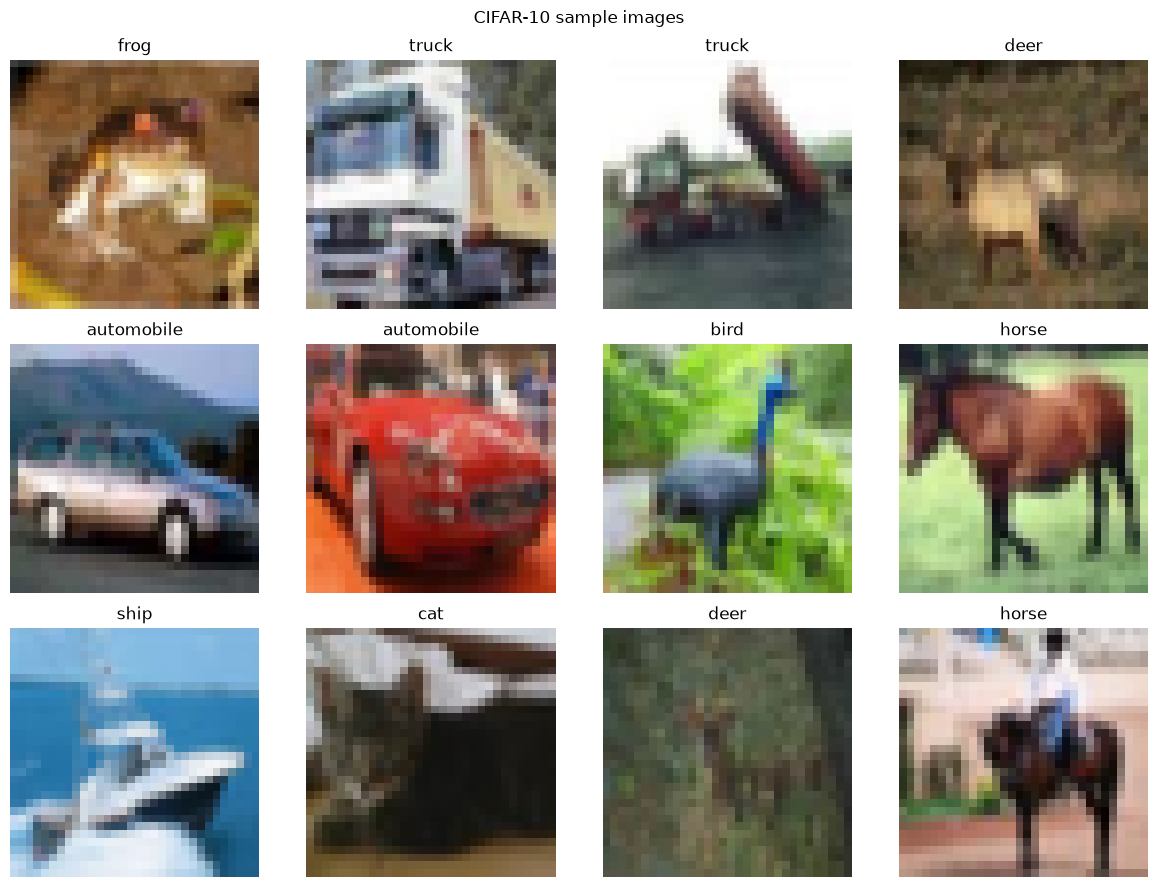

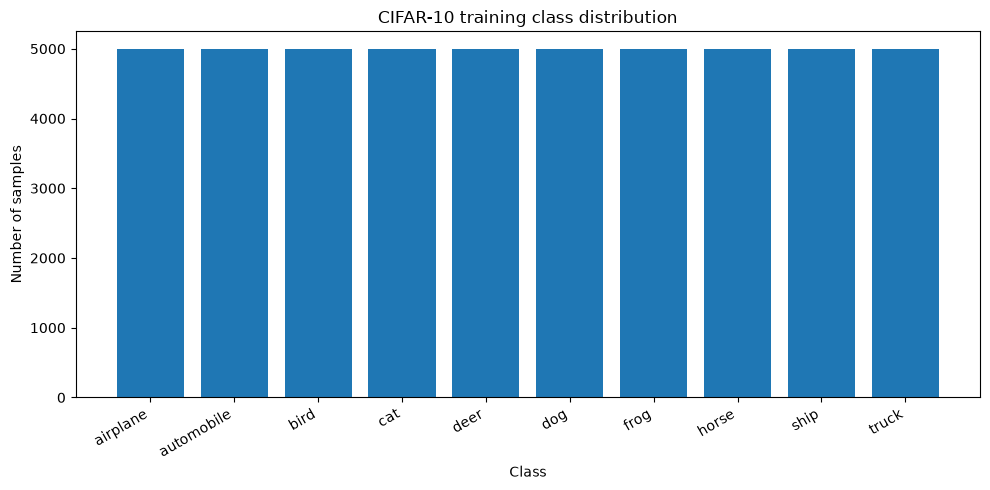

In [97]:
plot_image_grid(
    cifar_x_train[:100],
    cifar_y_train[:100],
    class_names=IMAGE_CLASS_NAMES["cifar10"],
    n=12,
    title="CIFAR-10 sample images",
)

plot_class_distribution(
    cifar_y_train,
    class_names=IMAGE_CLASS_NAMES["cifar10"],
    title="CIFAR-10 training class distribution",
)

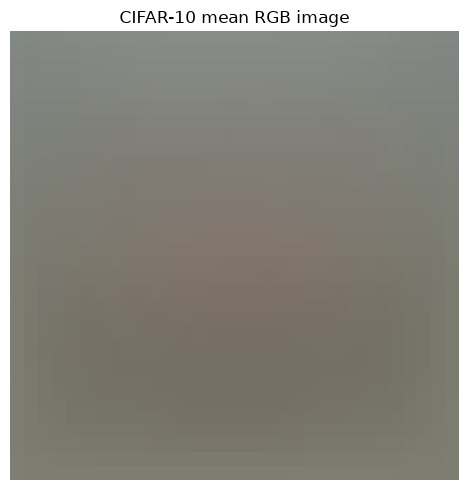

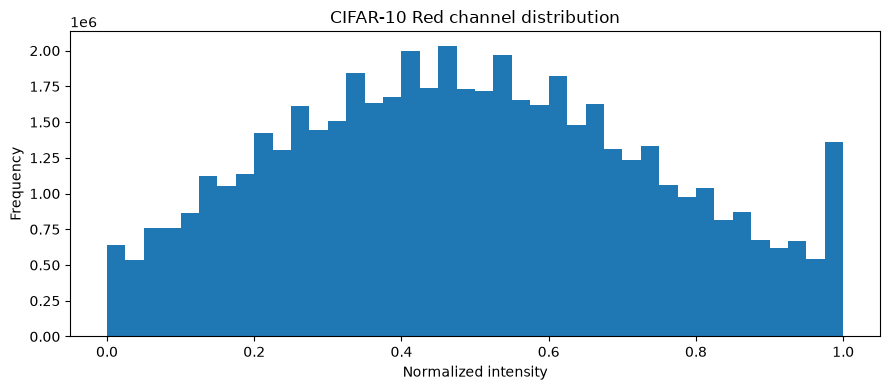

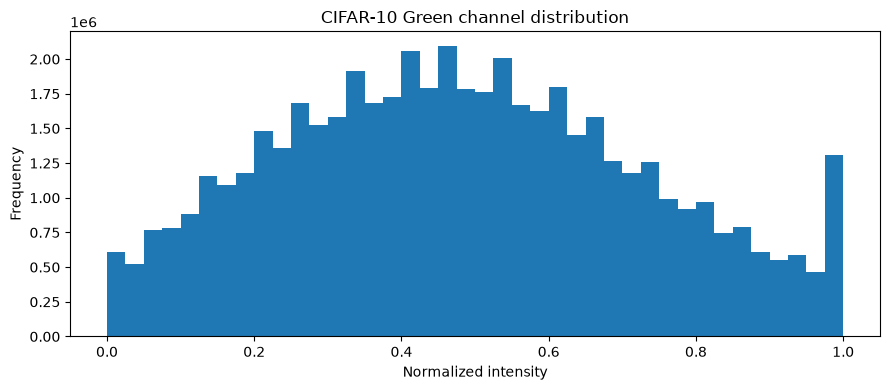

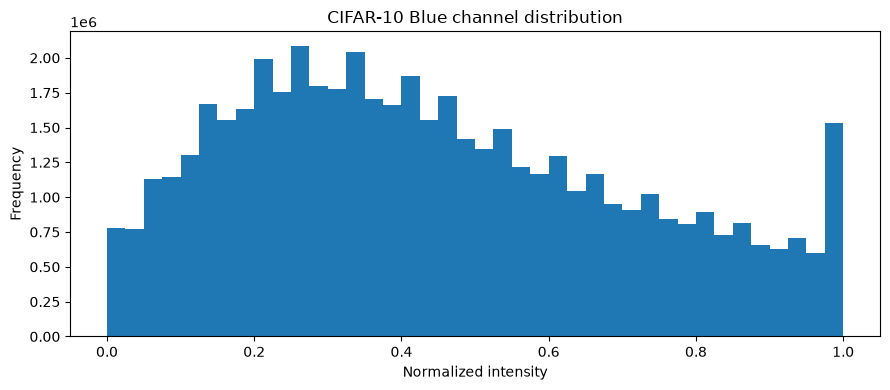

In [98]:
mean_cifar = cifar_x_train.mean(axis=0)
mean_cifar_display = np.transpose(mean_cifar, (1, 2, 0))

plt.figure(figsize=(5, 5))
plt.imshow(mean_cifar_display)
plt.title("CIFAR-10 mean RGB image")
plt.axis("off")
plt.tight_layout()
plt.show()

for channel, name in enumerate(["Red", "Green", "Blue"]):
    plt.figure(figsize=(9, 4))
    plt.hist(cifar_x_train[:, channel].reshape(-1), bins=40)
    plt.title(f"CIFAR-10 {name} channel distribution")
    plt.xlabel("Normalized intensity")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

In [99]:
cifar_train_idx, cifar_val_idx = make_stratified_indices(
    cifar_y_train,
    val_size=VALIDATION_SIZE,
    seed=SEED,
    train_limit=COMPARISON_TRAIN_LIMIT if USE_COMPARISON_LIMITS else None,
    val_limit=COMPARISON_VAL_LIMIT if USE_COMPARISON_LIMITS else None,
)

cifar_X_tr = cifar_x_train[cifar_train_idx]
cifar_y_tr = cifar_y_train[cifar_train_idx]

cifar_X_val = cifar_x_train[cifar_val_idx]
cifar_y_val = cifar_y_train[cifar_val_idx]

cifar_X_te = cifar_x_test
cifar_y_te = cifar_y_test

report_split(
    "CIFAR-10 split",
    cifar_y_tr,
    cifar_y_val,
    cifar_y_te,
)

CIFAR-10 split
  train: 45000
  val  : 5000
  test : 10000
  train class counts: [4500 4500 4500 4500 4500 4500 4500 4500 4500 4500]
  val class counts  : [500 500 500 500 500 500 500 500 500 500]
  test class counts : [1000 1000 1000 1000 1000 1000 1000 1000 1000 1000]


## 16. CIFAR-10 shape calculation before writing the Dense layer

The lecture requires shape tracking before defining the final dense layer.

For our architecture:

```text
Input: B x 3 x 32 x 32

Conv2d(3, 16, kernel=3, padding=1, stride=1)
-> B x 16 x 32 x 32

MaxPool(2)
-> B x 16 x 16 x 16

Flatten
-> B x 4096
```

Therefore the final linear layer must receive 4096 input features.

In [100]:
CIFAR_CHANNELS = 3
CIFAR_HEIGHT = 32
CIFAR_WIDTH = 32
CIFAR_CLASSES = 10

CIFAR_FLAT_FEATURES = (
    16
    * (CIFAR_HEIGHT // 2)
    * (CIFAR_WIDTH // 2)
)

print("CIFAR-10 classifier input features:", CIFAR_FLAT_FEATURES)

CIFAR-10 classifier input features: 4096


## 17. CIFAR-10 Scratch CNN

The same Scratch CNN code is reused with `in_channels=3`.

This demonstrates an important point:

The implementation is the same idea; only the input representation changes.

Epoch 1/5 | loss=1.6493 | acc=0.4161 | val_loss=1.4475 | val_acc=0.4874
Epoch 2/5 | loss=1.3824 | acc=0.5182 | val_loss=1.3629 | val_acc=0.5206
Epoch 3/5 | loss=1.2800 | acc=0.5567 | val_loss=1.2801 | val_acc=0.5578
Epoch 4/5 | loss=1.2186 | acc=0.5791 | val_loss=1.2406 | val_acc=0.5724
Epoch 5/5 | loss=1.1671 | acc=0.5976 | val_loss=1.2219 | val_acc=0.5798


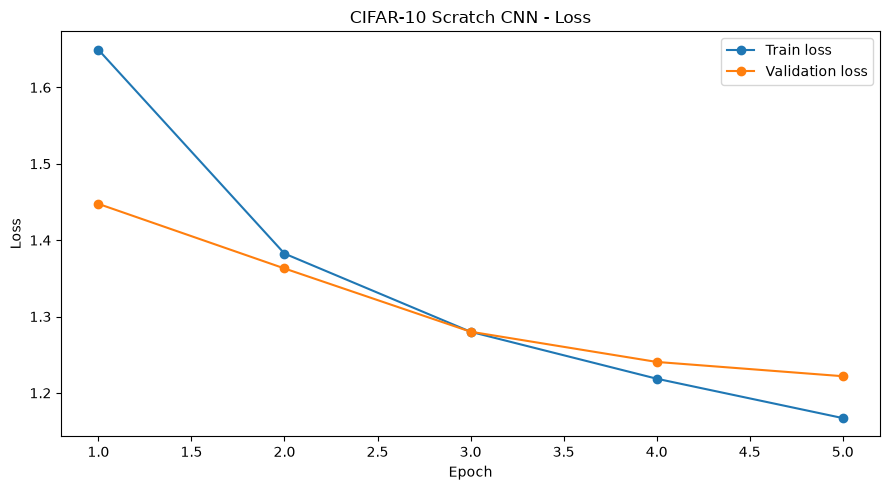

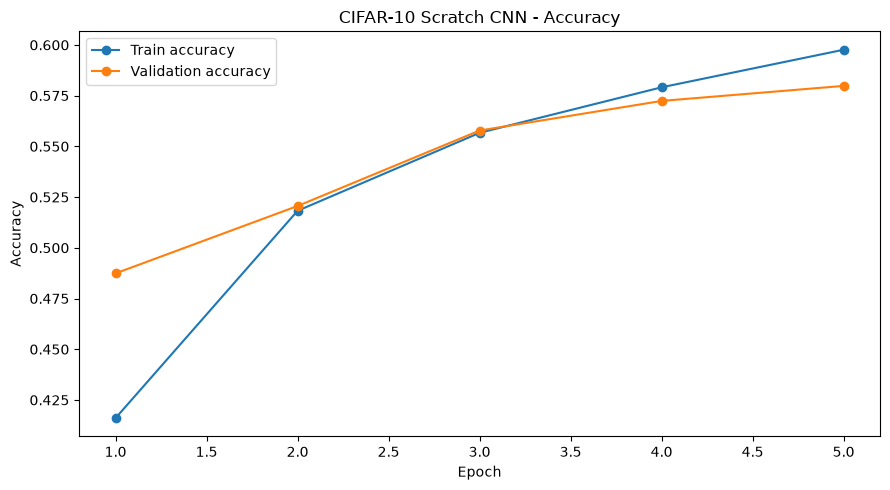

In [101]:
set_global_seed(SEED)

cifar_scratch_params, cifar_scratch_history, cifar_scratch_time = train_scratch_cnn(
    cifar_X_tr,
    cifar_y_tr,
    cifar_X_val,
    cifar_y_val,
    in_channels=CIFAR_CHANNELS,
    height=CIFAR_HEIGHT,
    width=CIFAR_WIDTH,
    num_classes=CIFAR_CLASSES,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LEARNING_RATE,
    seed=SEED,
)

plot_training_history(
    cifar_scratch_history,
    title="CIFAR-10 Scratch CNN",
)

accuracy                     0.572900
precision_macro              0.588441
recall_macro                 0.572900
f1_macro                     0.572666
precision_weighted           0.588441
recall_weighted              0.572900
f1_weighted                  0.572666
mean_confidence              0.546630
parameters               41418.000000
training_time_seconds      188.094851
epochs                       5.000000
dtype: float64


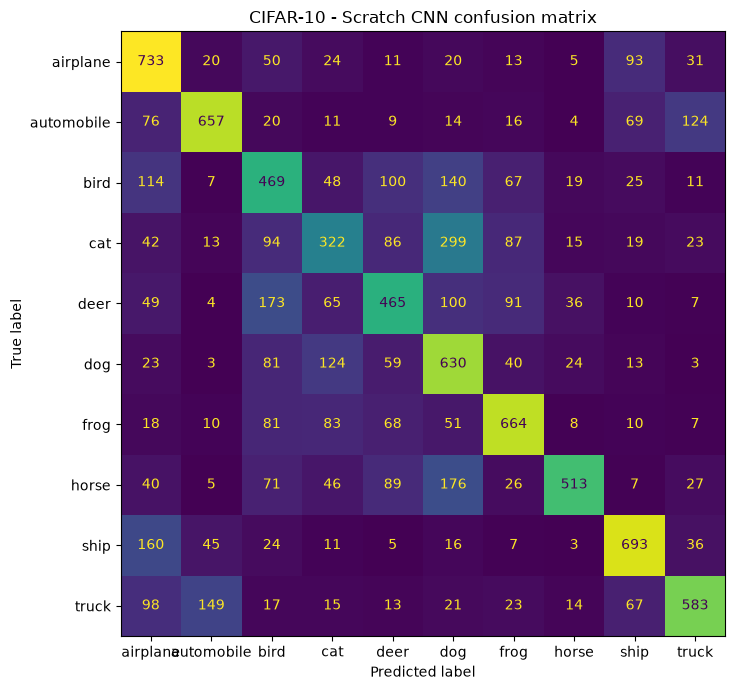

<Figure size 1000x600 with 0 Axes>

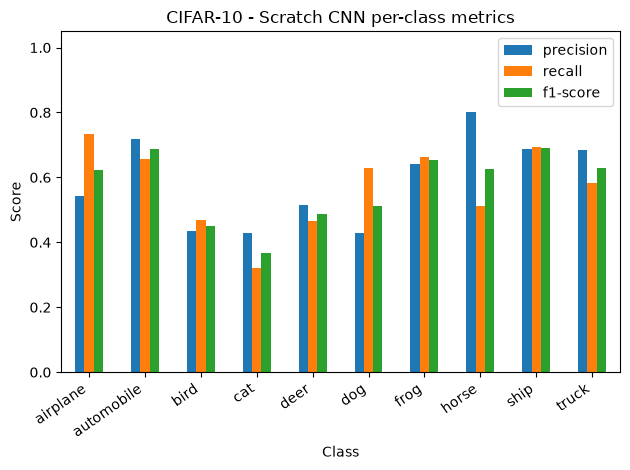

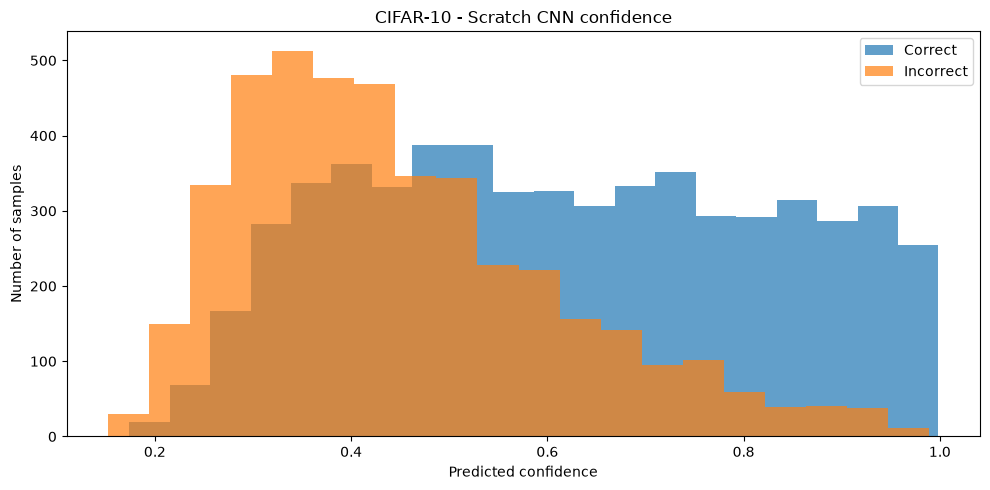

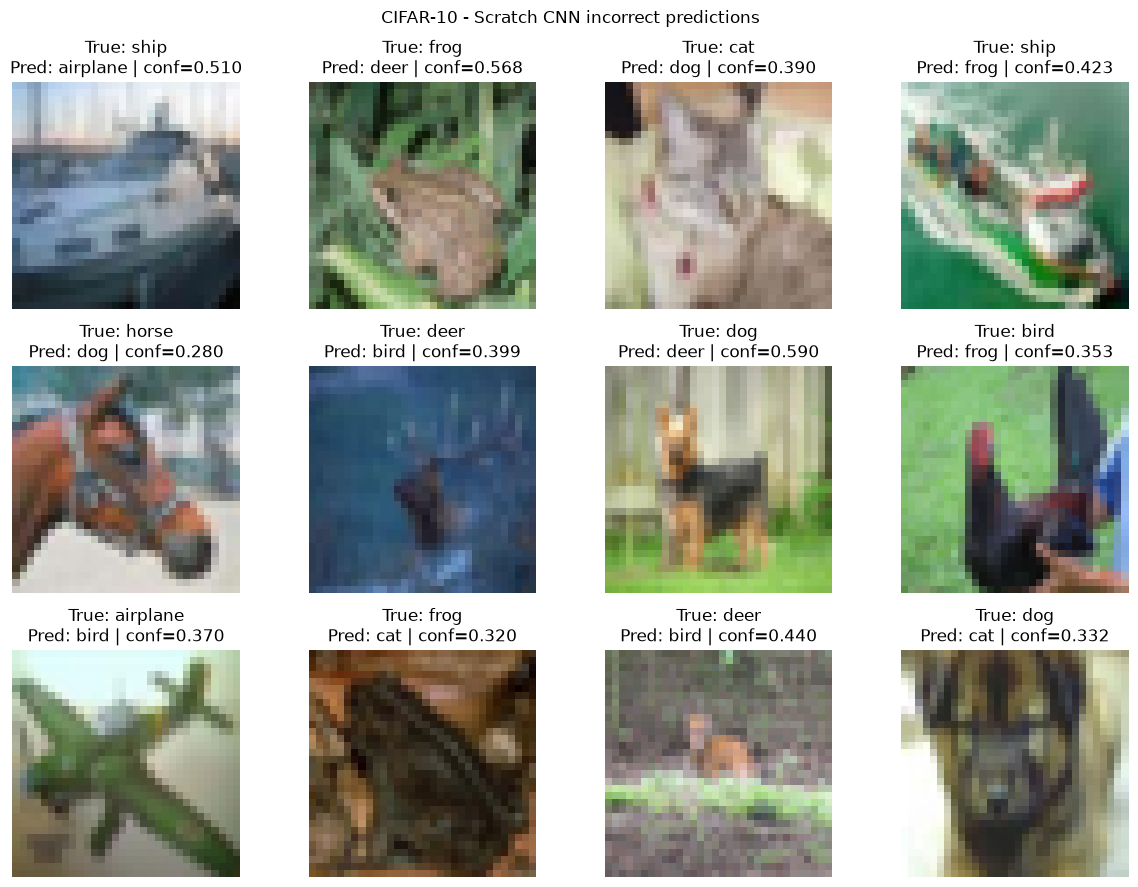

In [102]:
cifar_scratch_pred, cifar_scratch_prob = predict_scratch_cnn(
    cifar_X_te,
    cifar_scratch_params,
)

cifar_scratch_metrics = compute_classification_metrics(
    cifar_y_te,
    cifar_scratch_pred,
    cifar_scratch_prob,
)

cifar_scratch_metrics["parameters"] = count_numpy_parameters(cifar_scratch_params)
cifar_scratch_metrics["training_time_seconds"] = cifar_scratch_time
cifar_scratch_metrics["epochs"] = EPOCHS

print(pd.Series(cifar_scratch_metrics))

show_confusion_matrix(
    cifar_y_te,
    cifar_scratch_pred,
    IMAGE_CLASS_NAMES["cifar10"],
    "CIFAR-10 - Scratch CNN confusion matrix",
)

show_classification_report(
    cifar_y_te,
    cifar_scratch_pred,
    IMAGE_CLASS_NAMES["cifar10"],
    "CIFAR-10 - Scratch CNN per-class metrics",
)

show_confidence_distribution(
    cifar_scratch_prob,
    cifar_y_te == cifar_scratch_pred,
    "CIFAR-10 - Scratch CNN confidence",
)

show_prediction_examples(
    cifar_x_test,
    cifar_y_te,
    cifar_scratch_pred,
    cifar_scratch_prob,
    IMAGE_CLASS_NAMES["cifar10"],
    "CIFAR-10 - Scratch CNN incorrect predictions",
    only_wrong=True,
    n=12,
)

## 18. CIFAR-10 PyTorch CNN

Epoch 1/5 | loss=1.6746 | acc=0.4147 | val_loss=1.5004 | val_acc=0.4682
Epoch 2/5 | loss=1.3811 | acc=0.5211 | val_loss=1.3404 | val_acc=0.5328
Epoch 3/5 | loss=1.2753 | acc=0.5557 | val_loss=1.2555 | val_acc=0.5648
Epoch 4/5 | loss=1.2100 | acc=0.5798 | val_loss=1.2175 | val_acc=0.5712
Epoch 5/5 | loss=1.1673 | acc=0.5951 | val_loss=1.2012 | val_acc=0.5774


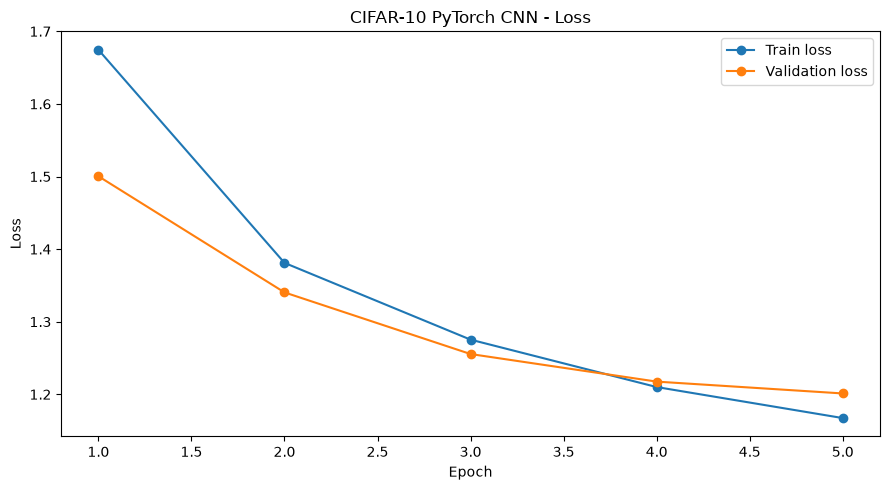

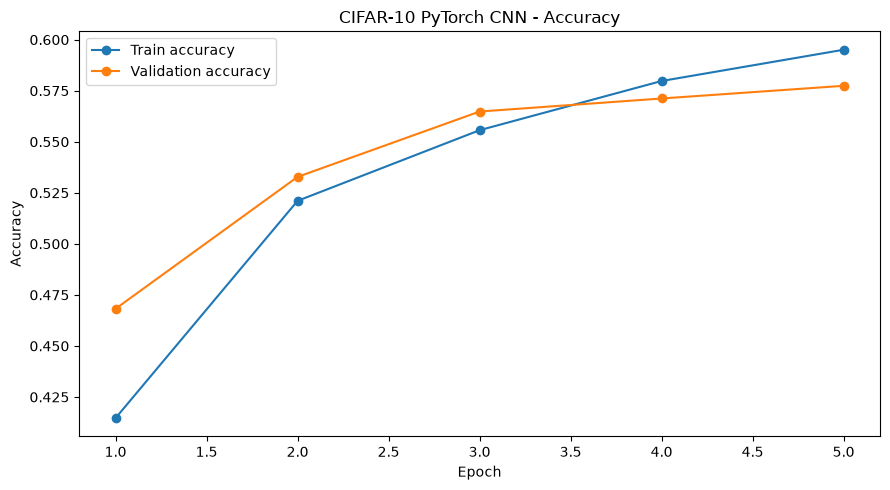

In [103]:
cifar_torch_model, cifar_torch_history, cifar_torch_time, _ = train_torch_cnn(
    cifar_X_tr,
    cifar_y_tr,
    cifar_X_val,
    cifar_y_val,
    cifar_X_te,
    cifar_y_te,
    in_channels=CIFAR_CHANNELS,
    height=CIFAR_HEIGHT,
    width=CIFAR_WIDTH,
    num_classes=CIFAR_CLASSES,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LEARNING_RATE,
    seed=SEED,
)

plot_training_history(
    cifar_torch_history,
    title="CIFAR-10 PyTorch CNN",
)

accuracy                     0.573700
precision_macro              0.576051
recall_macro                 0.573700
f1_macro                     0.564701
precision_weighted           0.576051
recall_weighted              0.573700
f1_weighted                  0.564701
mean_confidence              0.561211
parameters               41418.000000
training_time_seconds       45.944586
epochs                       5.000000
dtype: float64


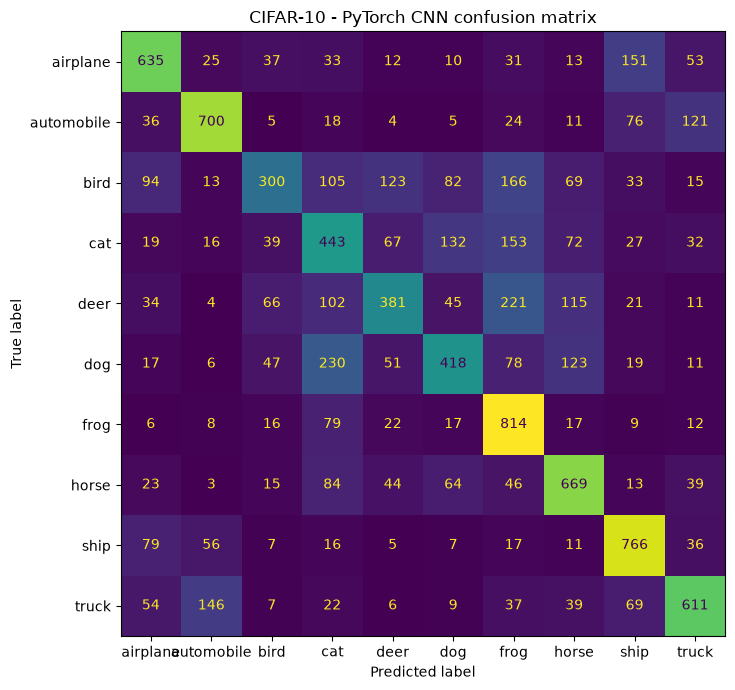

<Figure size 1000x600 with 0 Axes>

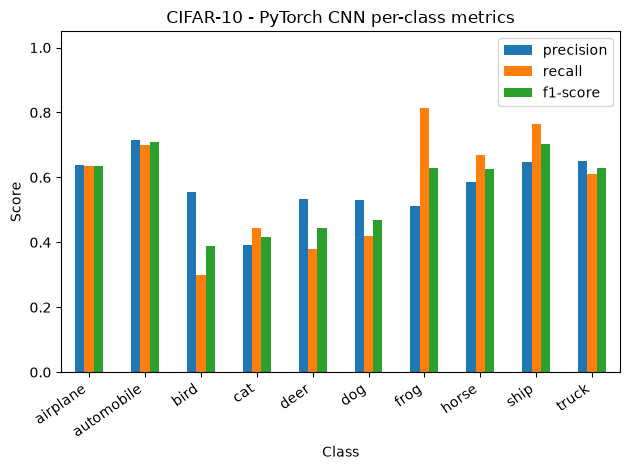

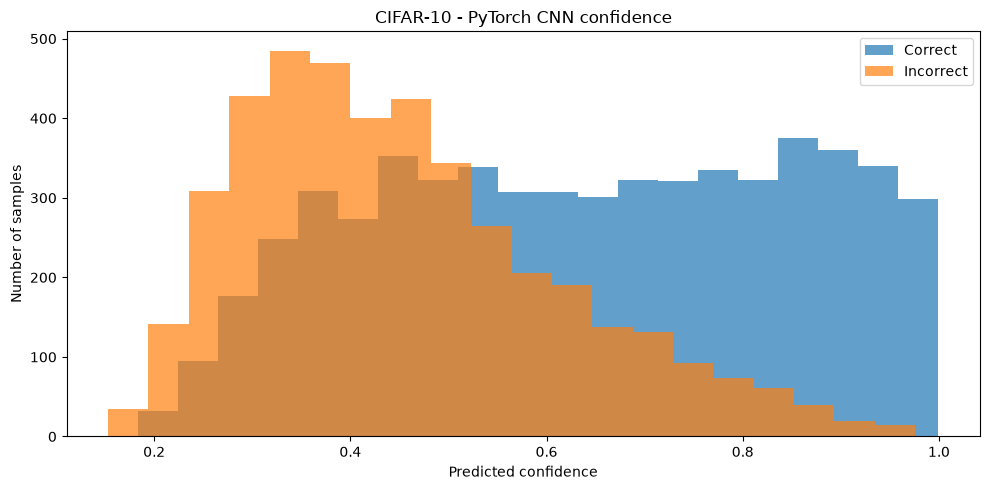

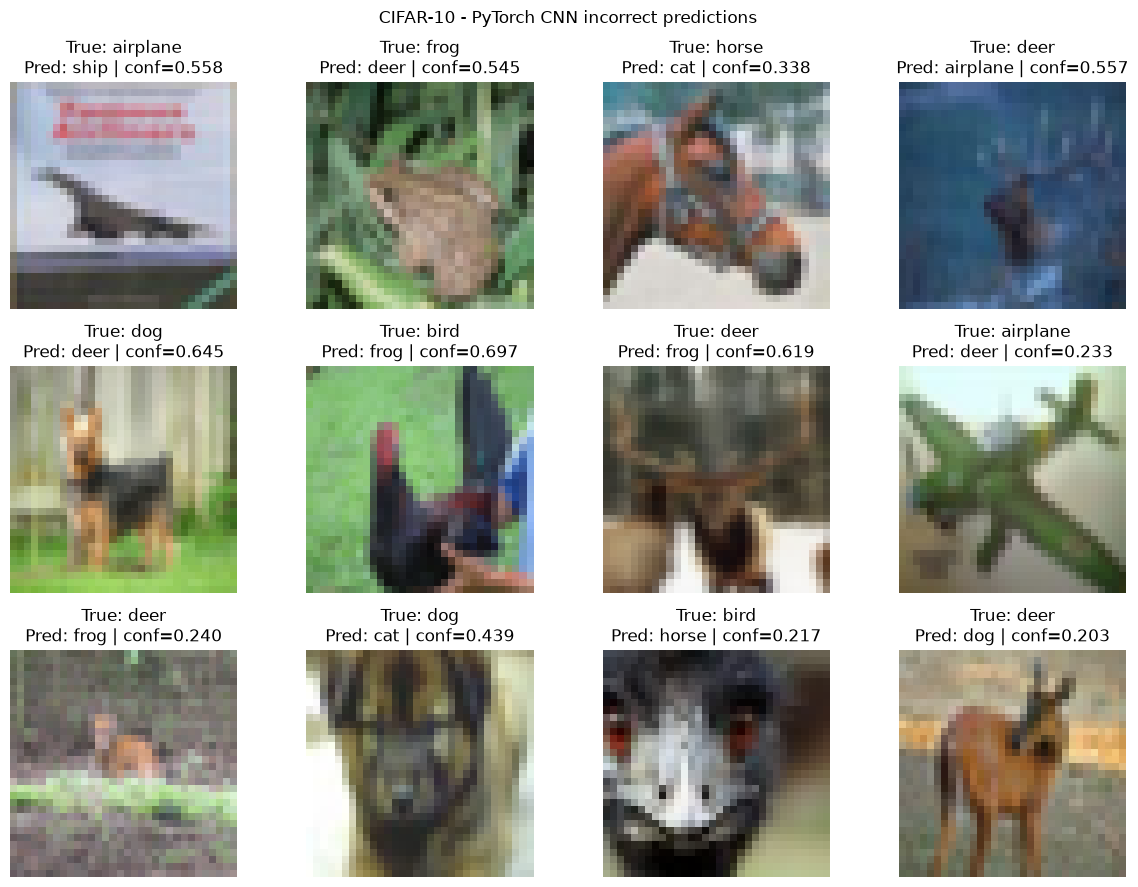

In [104]:
cifar_torch_pred, cifar_torch_prob = predict_torch(
    cifar_torch_model,
    cifar_X_te,
)

cifar_torch_metrics = compute_classification_metrics(
    cifar_y_te,
    cifar_torch_pred,
    cifar_torch_prob,
)

cifar_torch_metrics["parameters"] = int(
    sum(p.numel() for p in cifar_torch_model.parameters())
)
cifar_torch_metrics["training_time_seconds"] = cifar_torch_time
cifar_torch_metrics["epochs"] = EPOCHS

print(pd.Series(cifar_torch_metrics))

show_confusion_matrix(
    cifar_y_te,
    cifar_torch_pred,
    IMAGE_CLASS_NAMES["cifar10"],
    "CIFAR-10 - PyTorch CNN confusion matrix",
)

show_classification_report(
    cifar_y_te,
    cifar_torch_pred,
    IMAGE_CLASS_NAMES["cifar10"],
    "CIFAR-10 - PyTorch CNN per-class metrics",
)

show_confidence_distribution(
    cifar_torch_prob,
    cifar_y_te == cifar_torch_pred,
    "CIFAR-10 - PyTorch CNN confidence",
)

show_prediction_examples(
    cifar_x_test,
    cifar_y_te,
    cifar_torch_pred,
    cifar_torch_prob,
    IMAGE_CLASS_NAMES["cifar10"],
    "CIFAR-10 - PyTorch CNN incorrect predictions",
    only_wrong=True,
    n=12,
)

## 19. CIFAR-10 Keras CNN

Epoch 1/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.4182 - loss: 1.6689 - val_accuracy: 0.4896 - val_loss: 1.4667
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5198 - loss: 1.3804 - val_accuracy: 0.5318 - val_loss: 1.3557
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5539 - loss: 1.2857 - val_accuracy: 0.5474 - val_loss: 1.3006
Epoch 4/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5745 - loss: 1.2309 - val_accuracy: 0.5628 - val_loss: 1.2655
Epoch 5/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5906 - loss: 1.1907 - val_accuracy: 0.5750 - val_loss: 1.2405


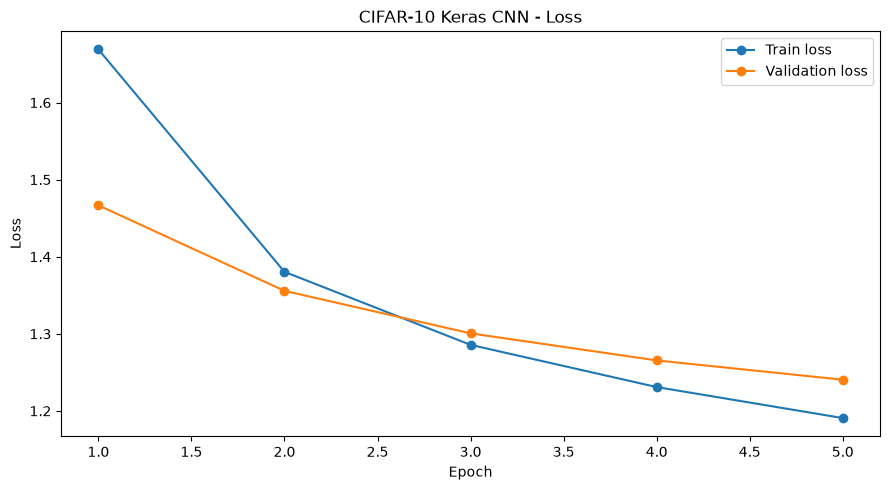

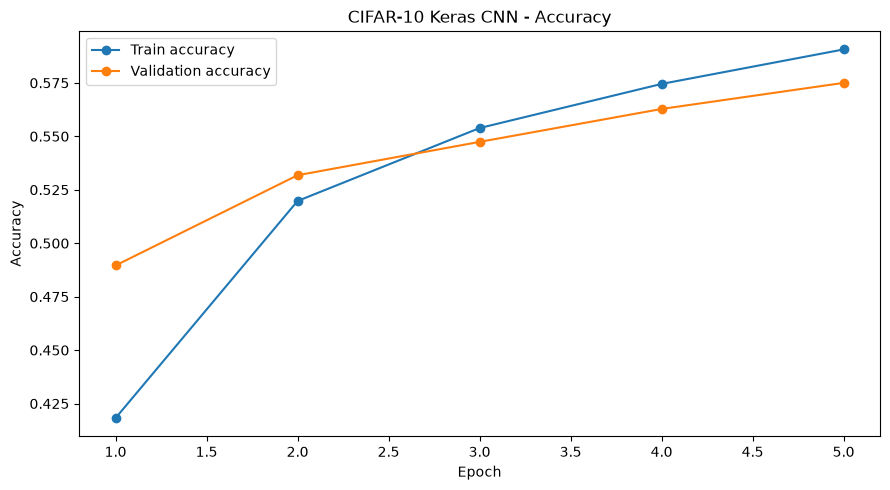

In [105]:
cifar_keras_model, cifar_keras_history, cifar_keras_time = train_keras_cnn(
    cifar_X_tr,
    cifar_y_tr,
    cifar_X_val,
    cifar_y_val,
    in_channels=CIFAR_CHANNELS,
    height=CIFAR_HEIGHT,
    width=CIFAR_WIDTH,
    num_classes=CIFAR_CLASSES,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LEARNING_RATE,
    seed=SEED,
)

plot_training_history(
    cifar_keras_history,
    title="CIFAR-10 Keras CNN",
)

accuracy                     0.568100
precision_macro              0.574029
recall_macro                 0.568100
f1_macro                     0.563815
precision_weighted           0.574029
recall_weighted              0.568100
f1_weighted                  0.563815
mean_confidence              0.548039
parameters               41418.000000
training_time_seconds       19.185502
epochs                       5.000000
dtype: float64


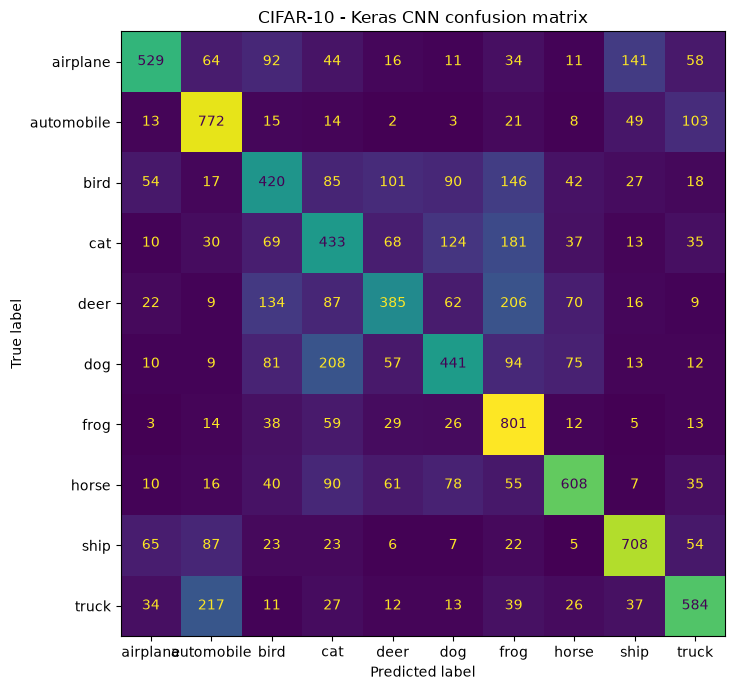

<Figure size 1000x600 with 0 Axes>

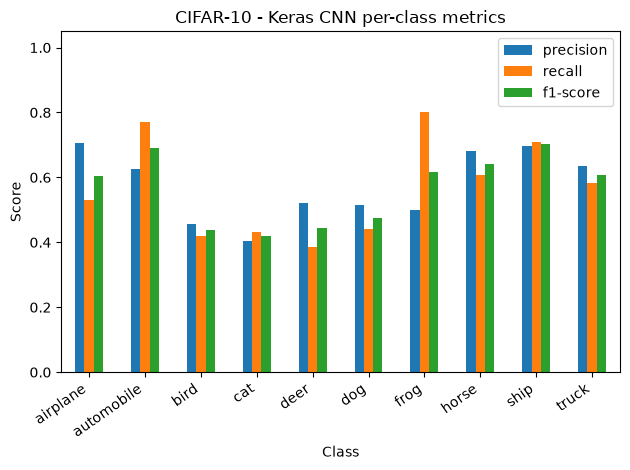

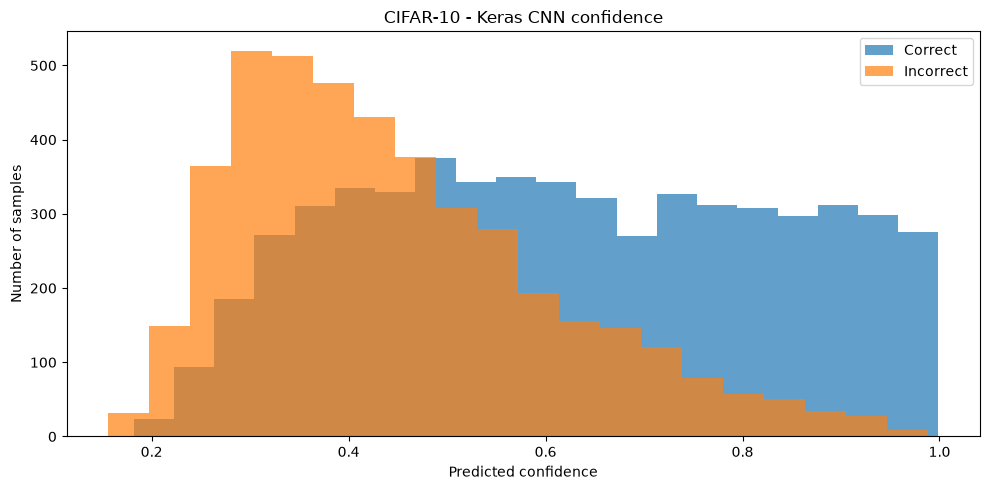

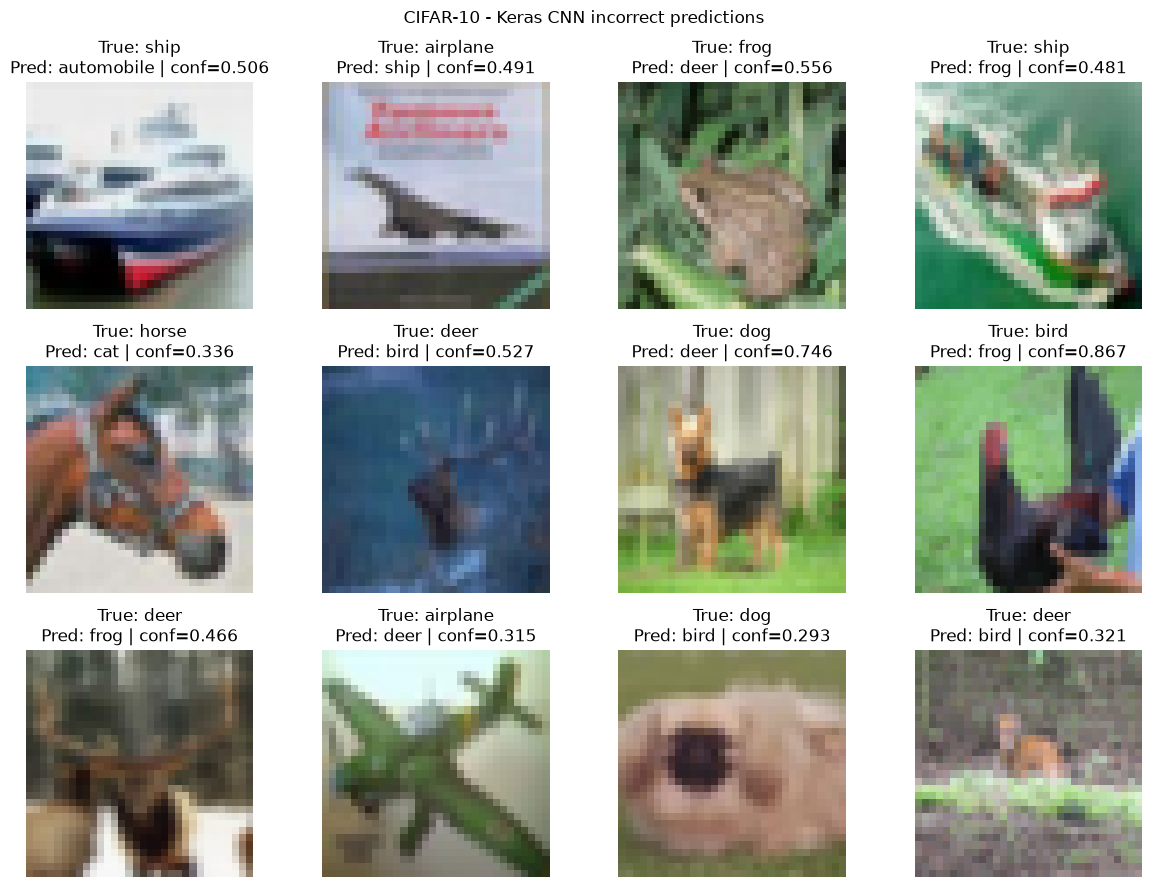

In [106]:
cifar_keras_pred, cifar_keras_prob = predict_keras(
    cifar_keras_model,
    cifar_X_te,
)

cifar_keras_metrics = compute_classification_metrics(
    cifar_y_te,
    cifar_keras_pred,
    cifar_keras_prob,
)

cifar_keras_metrics["parameters"] = int(cifar_keras_model.count_params())
cifar_keras_metrics["training_time_seconds"] = cifar_keras_time
cifar_keras_metrics["epochs"] = EPOCHS

print(pd.Series(cifar_keras_metrics))

show_confusion_matrix(
    cifar_y_te,
    cifar_keras_pred,
    IMAGE_CLASS_NAMES["cifar10"],
    "CIFAR-10 - Keras CNN confusion matrix",
)

show_classification_report(
    cifar_y_te,
    cifar_keras_pred,
    IMAGE_CLASS_NAMES["cifar10"],
    "CIFAR-10 - Keras CNN per-class metrics",
)

show_confidence_distribution(
    cifar_keras_prob,
    cifar_y_te == cifar_keras_pred,
    "CIFAR-10 - Keras CNN confidence",
)

show_prediction_examples(
    cifar_x_test,
    cifar_y_te,
    cifar_keras_pred,
    cifar_keras_prob,
    IMAGE_CLASS_NAMES["cifar10"],
    "CIFAR-10 - Keras CNN incorrect predictions",
    only_wrong=True,
    n=12,
)

## 20. CIFAR-10 representation visualization

Because CIFAR-10 is RGB, the learned feature maps are especially useful for showing that a convolution processes all input channels together while producing new feature channels.

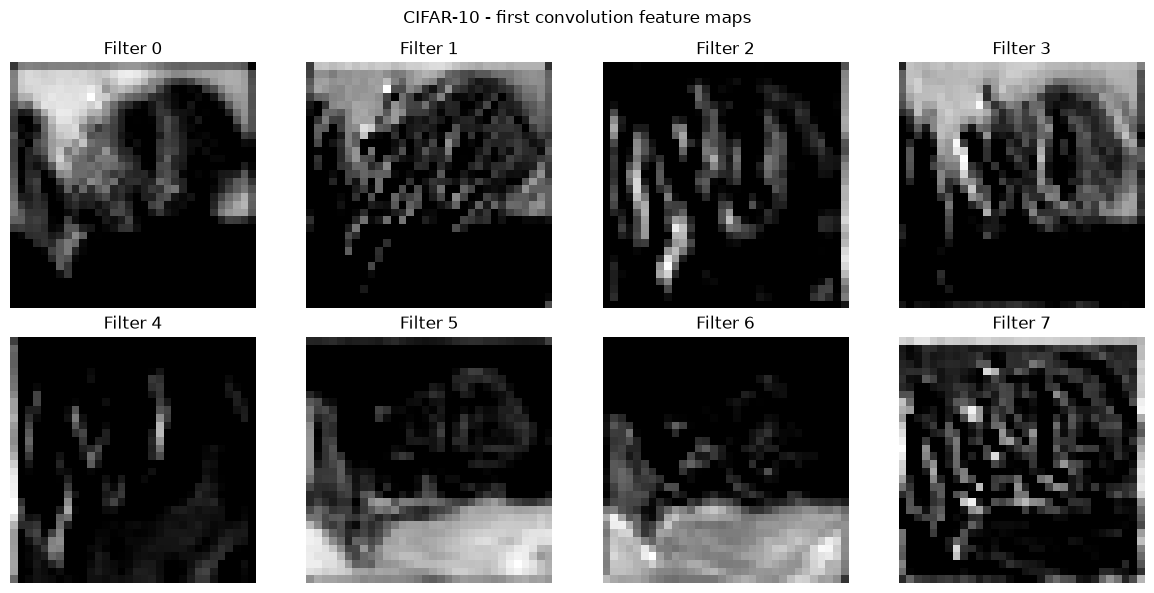

In [107]:
sample_index = 0
sample = torch.from_numpy(cifar_X_te[sample_index:sample_index + 1]).to(DEVICE)

cifar_torch_model.eval()

with torch.no_grad():
    feature_map = cifar_torch_model.features[0](sample)
    feature_map = torch.relu(feature_map).cpu().numpy()[0]

num_maps = min(8, feature_map.shape[0])

plt.figure(figsize=(12, 6))
for i in range(num_maps):
    ax = plt.subplot(2, 4, i + 1)
    ax.imshow(feature_map[i], cmap="gray")
    ax.set_title(f"Filter {i}")
    ax.axis("off")

plt.suptitle("CIFAR-10 - first convolution feature maps")
plt.tight_layout()
plt.show()

,dataset,framework,accuracy,precision_macro,recall_macro,f1_macro,mean_confidence,parameters,training_time_seconds,epochs
0,CIFAR-10,Scratch,0.5729,0.588441,0.5729,0.572666,0.546630,41418,188.094851,5
1,CIFAR-10,PyTorch,0.5737,0.576051,0.5737,0.564701,0.561211,41418,45.944586,5
2,CIFAR-10,Keras,0.5681,0.574029,0.5681,0.563815,0.548039,41418,19.185502,5


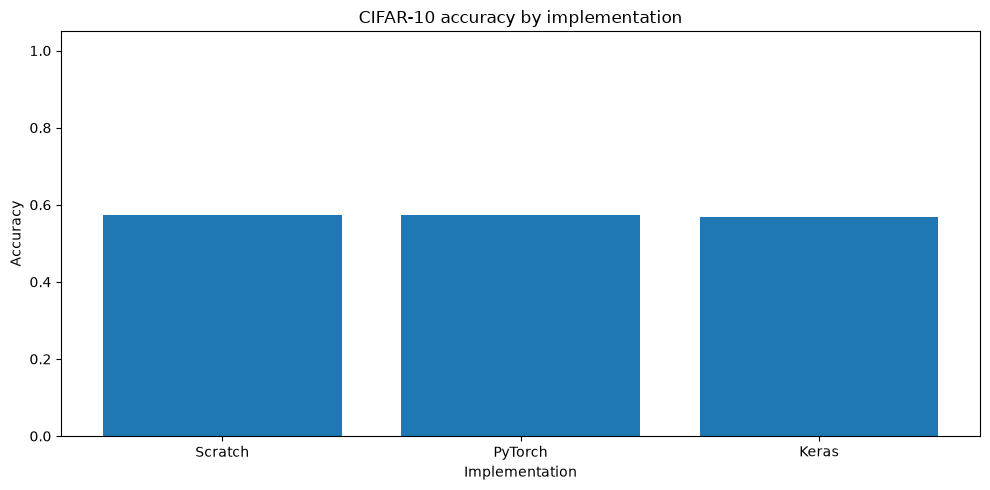

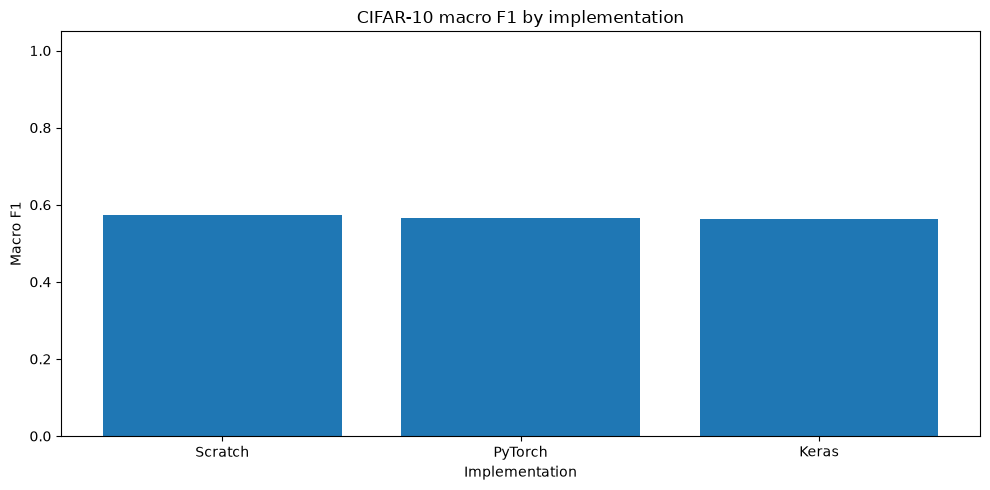

In [108]:
cifar_results = pd.DataFrame([
    {"dataset": "CIFAR-10", "framework": "Scratch", **cifar_scratch_metrics},
    {"dataset": "CIFAR-10", "framework": "PyTorch", **cifar_torch_metrics},
    {"dataset": "CIFAR-10", "framework": "Keras", **cifar_keras_metrics},
])

cifar_results = cifar_results[
    [
        "dataset",
        "framework",
        "accuracy",
        "precision_macro",
        "recall_macro",
        "f1_macro",
        "mean_confidence",
        "parameters",
        "training_time_seconds",
        "epochs",
    ]
]

display(cifar_results)

plt.figure(figsize=(10, 5))
plt.bar(cifar_results["framework"], cifar_results["accuracy"])
plt.title("CIFAR-10 accuracy by implementation")
plt.xlabel("Implementation")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(cifar_results["framework"], cifar_results["f1_macro"])
plt.title("CIFAR-10 macro F1 by implementation")
plt.xlabel("Implementation")
plt.ylabel("Macro F1")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

# Part D - Dataset 3: Diabetes

## 21. Load and inspect Diabetes

This dataset is tabular data, not image data.

A sample is represented as a feature vector:

```text
x = [x1, x2, ..., xd]
```

There is normally no meaningful 2D spatial neighborhood between adjacent tabular columns.

Therefore the natural neural-network baseline is an MLP:

```text
Features -> Linear -> ReLU -> Linear -> ReLU -> Linear -> Prediction
```
Data source: https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset

This is exactly the distinction emphasized in Lecture 04.

In [109]:
diabetes_df = pd.read_csv(DIABETES_PATH)

print("Shape:", diabetes_df.shape)
print("\nColumns:")
print(diabetes_df.columns.tolist())

display(diabetes_df.head())

Shape: (253680, 22)

Columns:
['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [110]:
print("Missing values by column:")
missing = diabetes_df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0].to_frame("missing_count"))

print("Duplicate rows:", diabetes_df.duplicated().sum())

print("Data types:")
display(diabetes_df.dtypes.to_frame("dtype"))

print("File size MB:", round(DIABETES_PATH.stat().st_size / (1024**2), 2))

Missing values by column:


,missing_count


Duplicate rows: 23899
Data types:


,dtype
Diabetes_012,float64
HighBP,float64
HighChol,float64
CholCheck,float64
BMI,float64
Smoker,float64
Stroke,float64
HeartDiseaseorAttack,float64
PhysActivity,float64
Fruits,float64


File size MB: 21.68


## 22. Diabetes target detection

The preferred target column for the selected dataset is `Diabetes_012`.

The code below keeps a small fallback list so the notebook can fail clearly if a different Diabetes file is placed in the folder.

In [111]:
TARGET_CANDIDATES = [
    "Diabetes_012",
    "Diabetes_binary",
    "diabetes",
    "target",
    "Target",
]

target_column = next(
    (name for name in TARGET_CANDIDATES if name in diabetes_df.columns),
    None,
)

if target_column is None:
    diabetes_like = [
        col for col in diabetes_df.columns
        if "diabetes" in col.lower()
    ]
    if len(diabetes_like) == 1:
        target_column = diabetes_like[0]

if target_column is None:
    raise ValueError(
        "Cannot identify the Diabetes target column. "
        "Expected Diabetes_012 or another target column."
    )

print("Target column:", target_column)

X_diabetes_df = diabetes_df.drop(columns=[target_column]).copy()
y_diabetes = diabetes_df[target_column].astype(int).to_numpy()

# Keep numeric columns only for this assignment.
non_numeric = X_diabetes_df.select_dtypes(exclude=[np.number]).columns.tolist()

if non_numeric:
    print("Dropping non-numeric columns:", non_numeric)
    X_diabetes_df = X_diabetes_df.drop(columns=non_numeric)

X_diabetes = X_diabetes_df.to_numpy(dtype=np.float32)

print("Input features:", X_diabetes.shape)
print("Target shape:", y_diabetes.shape)
print("Classes:", np.unique(y_diabetes))

Target column: Diabetes_012
Input features: (253680, 21)
Target shape: (253680,)
Classes: [0 1 2]


## 22.1 Diabetes data exploration

The visualization set is intentionally broader than a single histogram.

We inspect:

1. Target balance.
2. Feature distributions.
3. Correlation structure.
4. A PCA projection.
5. Example feature distributions by target.

This helps explain both the dataset and the later model behavior.

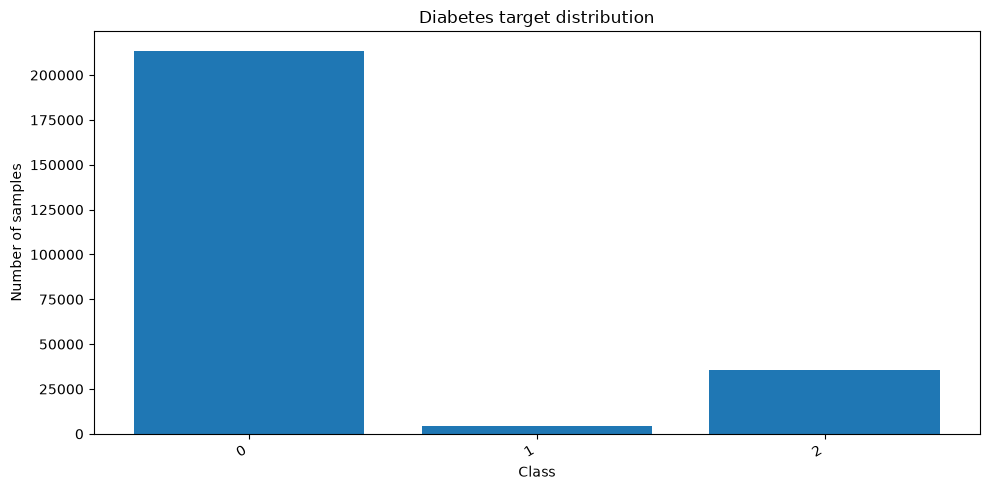

In [112]:
plot_class_distribution(
    y_diabetes,
    class_names=[str(v) for v in np.unique(y_diabetes)],
    title="Diabetes target distribution",
)

,count,mean,std,min,25%,50%,75%,max
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0
Veggies,253680.0,0.811420,0.391175,0.0,1.0,1.0,1.0,1.0


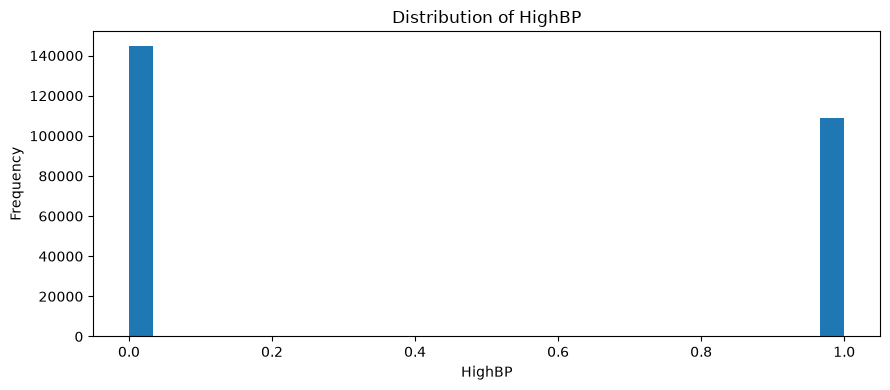

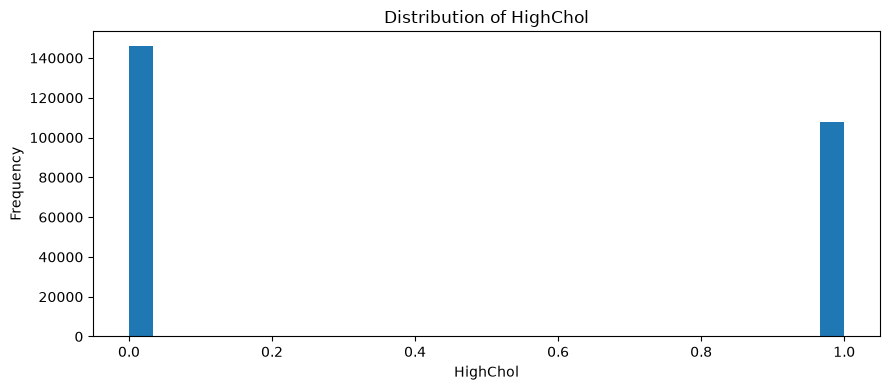

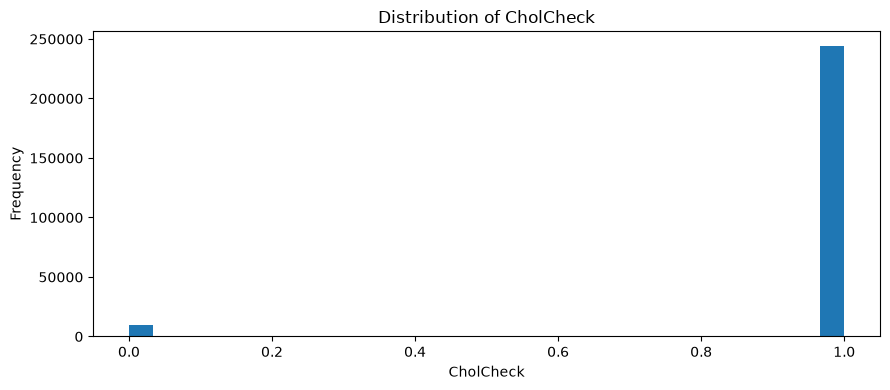

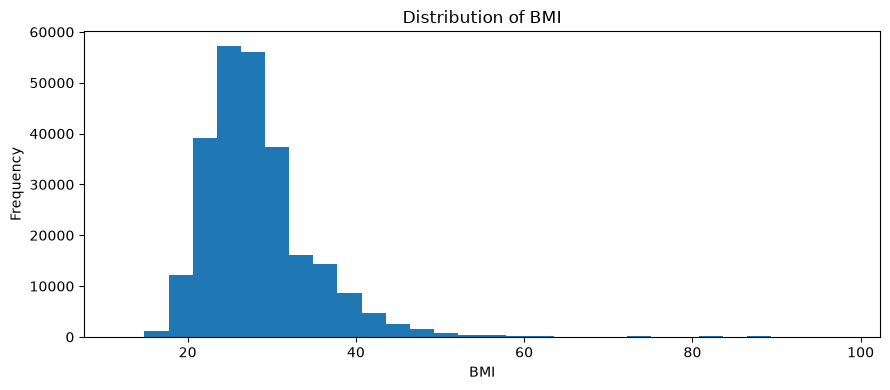

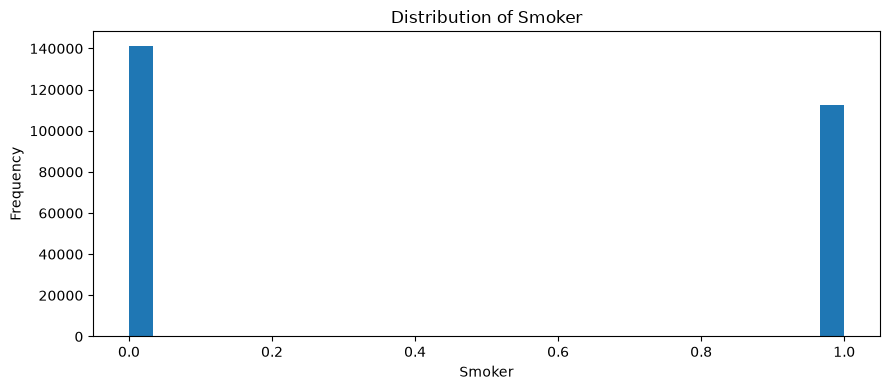

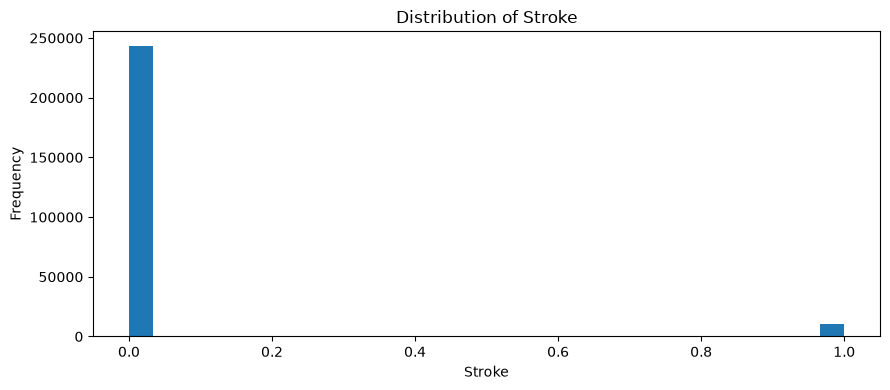

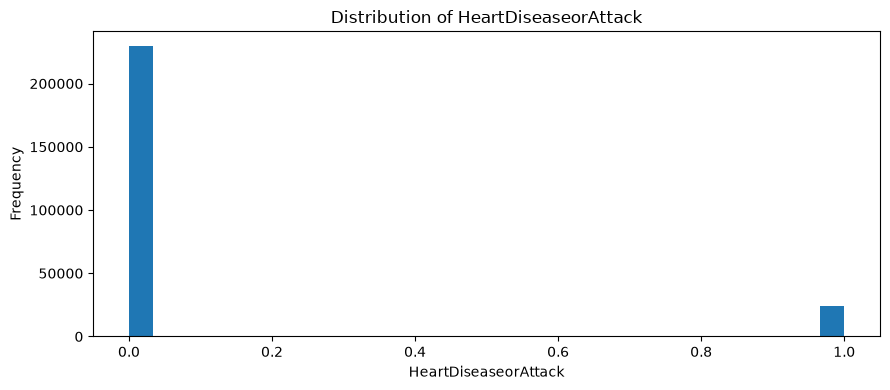

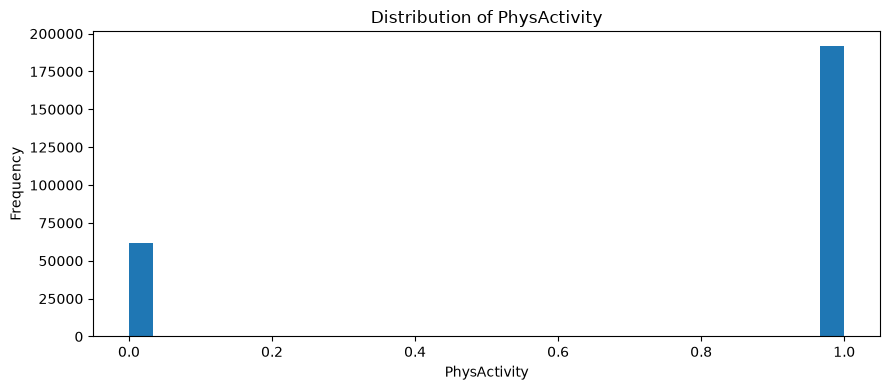

In [113]:
display(X_diabetes_df.describe().T)

numeric_features_for_plot = X_diabetes_df.columns[:8]

for feature in numeric_features_for_plot:
    plt.figure(figsize=(9, 4))
    plt.hist(X_diabetes_df[feature], bins=30)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

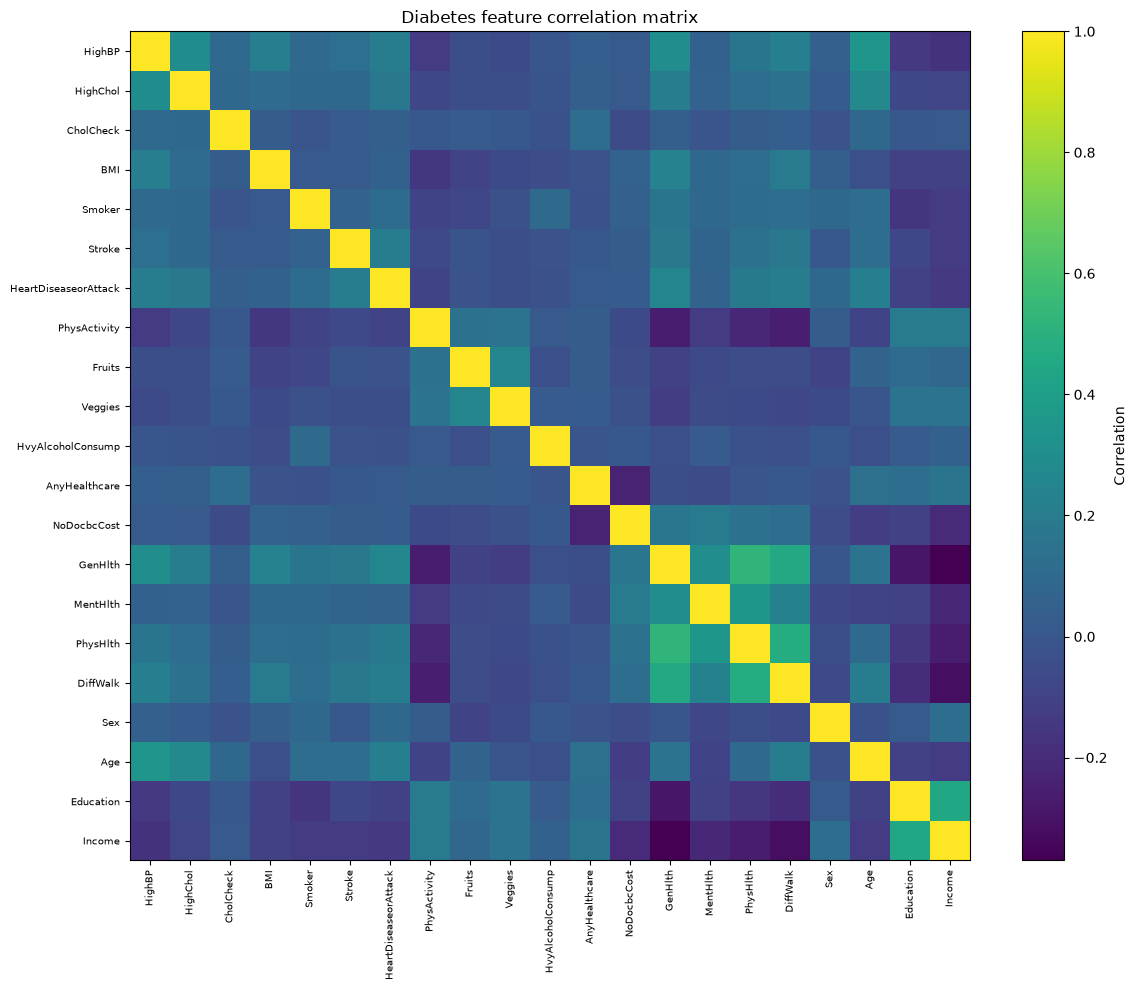

In [114]:
corr = X_diabetes_df.corr(numeric_only=True).to_numpy()
corr_labels = X_diabetes_df.corr(numeric_only=True).columns.tolist()

plt.figure(figsize=(12, 10))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_labels)), corr_labels, rotation=90, fontsize=7)
plt.yticks(range(len(corr_labels)), corr_labels, fontsize=7)
plt.title("Diabetes feature correlation matrix")
plt.tight_layout()
plt.show()

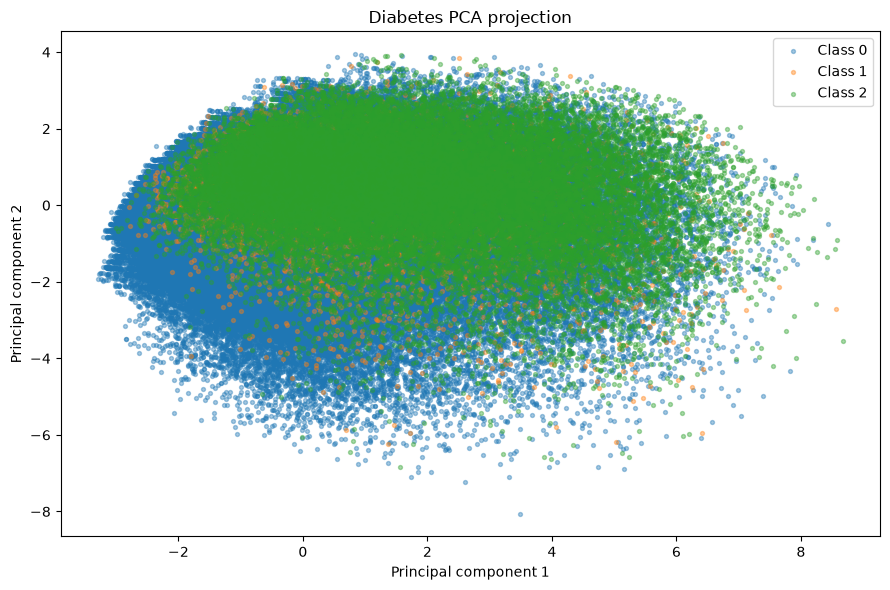

Explained variance ratio: [0.16713002 0.083967  ]


In [115]:
# PCA is used only for visualization.
scaler_for_pca = StandardScaler()
X_diabetes_scaled_for_pca = scaler_for_pca.fit_transform(X_diabetes)

pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_diabetes_scaled_for_pca)

plt.figure(figsize=(9, 6))
for label in np.unique(y_diabetes):
    mask = y_diabetes == label
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=8,
        alpha=0.4,
        label=f"Class {label}",
    )

plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.title("Diabetes PCA projection")
plt.legend()
plt.tight_layout()
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)

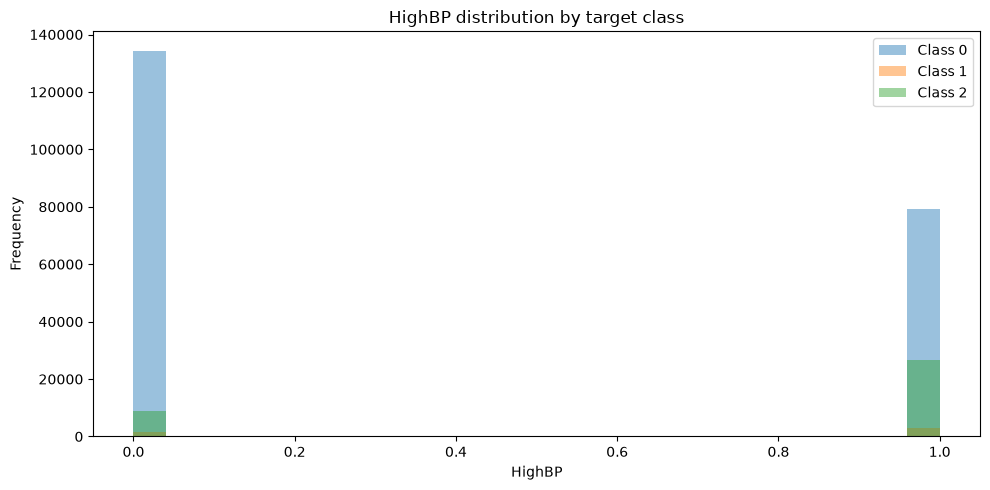

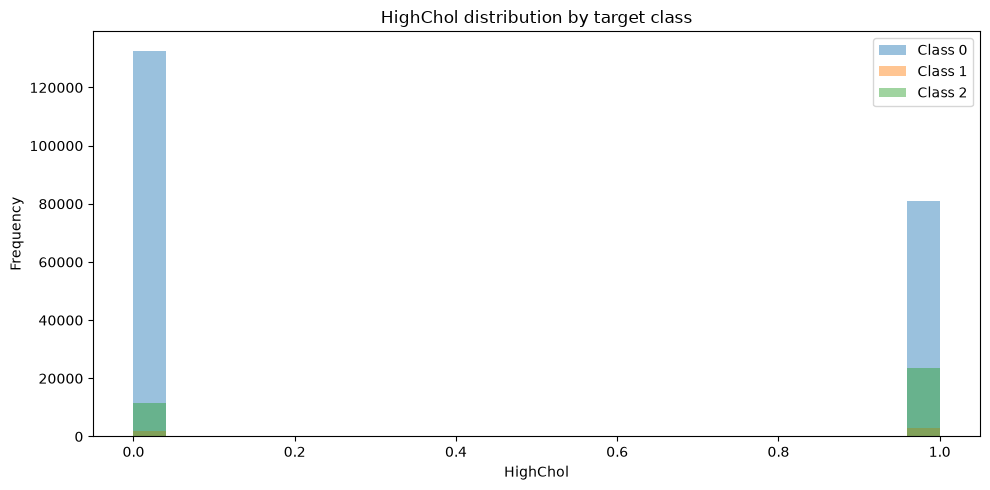

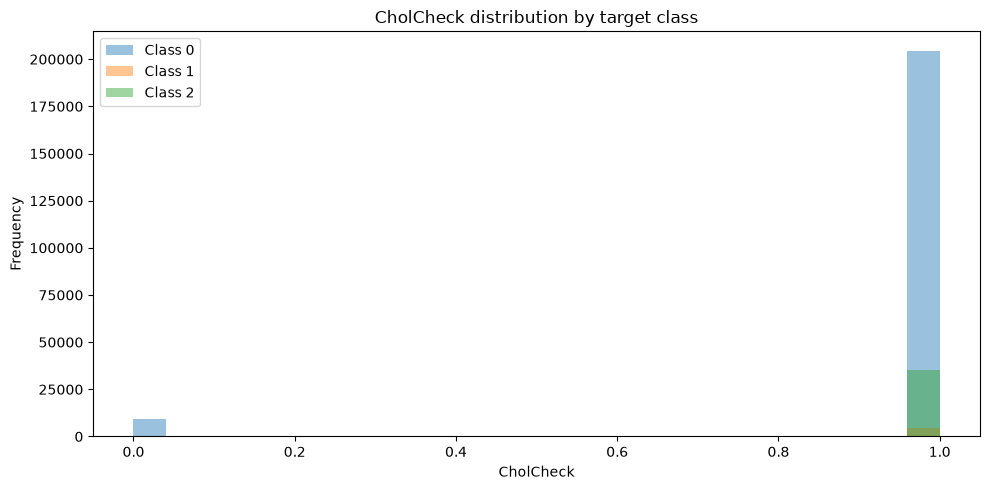

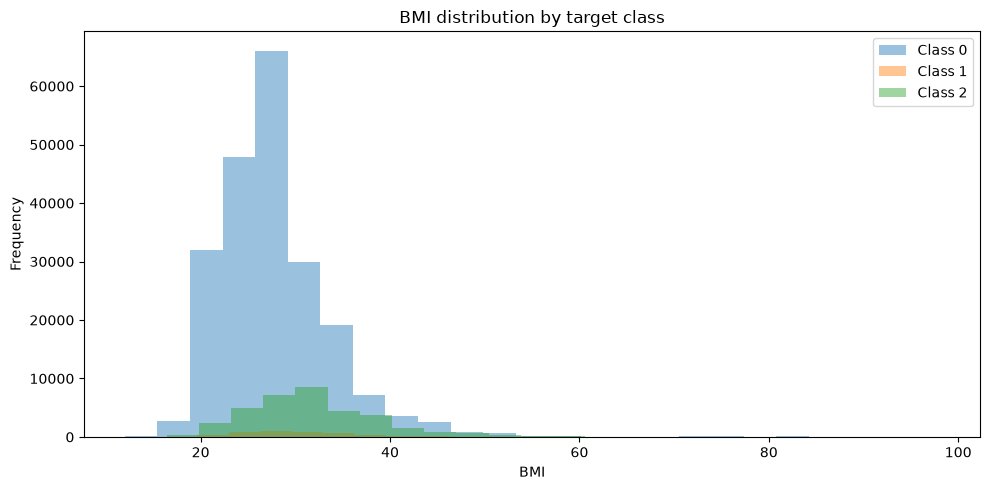

In [116]:
# A few feature distributions grouped by target.
selected_features = X_diabetes_df.columns[:4]

for feature in selected_features:
    plt.figure(figsize=(10, 5))

    for label in np.unique(y_diabetes):
        values = X_diabetes_df.loc[y_diabetes == label, feature]
        plt.hist(
            values,
            bins=25,
            alpha=0.45,
            label=f"Class {label}",
        )

    plt.title(f"{feature} distribution by target class")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 23. Diabetes preprocessing and split

The order matters:

```text
Split -> fit scaler on training data only -> transform train/validation/test
```

This avoids data leakage.

The same split and same scaler are then used conceptually for Scratch, PyTorch and Keras.

In [117]:
diabetes_train_idx, diabetes_test_idx = train_test_split(
    np.arange(len(y_diabetes)),
    test_size=0.20,
    stratify=y_diabetes,
    random_state=SEED,
)

diabetes_train_idx, diabetes_val_idx = train_test_split(
    diabetes_train_idx,
    test_size=VALIDATION_SIZE,
    stratify=y_diabetes[diabetes_train_idx],
    random_state=SEED,
)

if USE_COMPARISON_LIMITS:
    if COMPARISON_TRAIN_LIMIT is not None and COMPARISON_TRAIN_LIMIT < len(diabetes_train_idx):
        diabetes_train_idx, _ = train_test_split(
            diabetes_train_idx,
            train_size=COMPARISON_TRAIN_LIMIT,
            stratify=y_diabetes[diabetes_train_idx],
            random_state=SEED,
        )

    if COMPARISON_VAL_LIMIT is not None and COMPARISON_VAL_LIMIT < len(diabetes_val_idx):
        diabetes_val_idx, _ = train_test_split(
            diabetes_val_idx,
            train_size=COMPARISON_VAL_LIMIT,
            stratify=y_diabetes[diabetes_val_idx],
            random_state=SEED,
        )

X_diabetes_tr_raw = X_diabetes[diabetes_train_idx]
y_diabetes_tr = y_diabetes[diabetes_train_idx]

X_diabetes_val_raw = X_diabetes[diabetes_val_idx]
y_diabetes_val = y_diabetes[diabetes_val_idx]

X_diabetes_te_raw = X_diabetes[diabetes_test_idx]
y_diabetes_te = y_diabetes[diabetes_test_idx]

diabetes_scaler = StandardScaler()
X_diabetes_tr = diabetes_scaler.fit_transform(X_diabetes_tr_raw).astype(np.float32)
X_diabetes_val = diabetes_scaler.transform(X_diabetes_val_raw).astype(np.float32)
X_diabetes_te = diabetes_scaler.transform(X_diabetes_te_raw).astype(np.float32)

report_split(
    "Diabetes split",
    y_diabetes_tr,
    y_diabetes_val,
    y_diabetes_te,
)

classes = np.unique(y_diabetes_tr)
diabetes_class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_diabetes_tr,
)

diabetes_class_weights = np.asarray(
    diabetes_class_weights,
    dtype=np.float32,
)

print("Class weights:", dict(zip(classes, diabetes_class_weights)))

Diabetes split
  train: 182649
  val  : 20295
  test : 50736
  train class counts: [153865   3335  25449]
  val class counts  : [17097   370  2828]
  test class counts : [42741   926  7069]
Class weights: {np.int64(0): np.float32(0.39569104), np.int64(1): np.float32(18.255772), np.int64(2): np.float32(2.3923533)}


## 24. MLP from Scratch for Diabetes

The manual MLP is intentionally simple:

```text
Input
-> Linear(64)
-> ReLU
-> Linear(32)
-> ReLU
-> Linear(number_of_classes)
```

This demonstrates the same function-composition idea without forcing an image-specific operation onto tabular data.

In [118]:
def init_scratch_mlp(input_dim, hidden1, hidden2, num_classes, seed=42):
    rng = np.random.default_rng(seed)

    params = {}

    params["W1"] = rng.normal(
        0,
        np.sqrt(2.0 / input_dim),
        size=(input_dim, hidden1),
    ).astype(np.float32)
    params["b1"] = np.zeros(hidden1, dtype=np.float32)

    params["W2"] = rng.normal(
        0,
        np.sqrt(2.0 / hidden1),
        size=(hidden1, hidden2),
    ).astype(np.float32)
    params["b2"] = np.zeros(hidden2, dtype=np.float32)

    params["W3"] = rng.normal(
        0,
        np.sqrt(2.0 / hidden2),
        size=(hidden2, num_classes),
    ).astype(np.float32)
    params["b3"] = np.zeros(num_classes, dtype=np.float32)

    return params


def weighted_cross_entropy(logits, labels, class_weights):
    probabilities = softmax(logits)
    batch_size = len(labels)

    sample_weights = class_weights[labels]
    normalizer = np.mean(sample_weights)

    true_probs = probabilities[
        np.arange(batch_size),
        labels,
    ]

    loss = -np.mean(
        sample_weights
        * np.log(np.clip(true_probs, 1e-12, 1.0))
    ) / normalizer

    dlogits = probabilities.copy()
    dlogits[np.arange(batch_size), labels] -= 1.0
    dlogits *= sample_weights[:, None]
    dlogits /= (batch_size * normalizer)

    return float(loss), dlogits, probabilities


def train_scratch_mlp(
    X_train, y_train, X_val, y_val,
    input_dim, num_classes,
    class_weights,
    epochs=5,
    batch_size=128,
    lr=1e-3,
    seed=42,
):
    params = init_scratch_mlp(
        input_dim=input_dim,
        hidden1=64,
        hidden2=32,
        num_classes=num_classes,
        seed=seed,
    )

    optimizer = AdamNumpy(params, lr=lr)

    history = {
        "loss": [],
        "accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
    }

    best_state = None
    best_val_loss = float("inf")

    start_time = time.perf_counter()

    for epoch in range(epochs):
        train_loss_sum = 0.0
        train_correct = 0
        train_seen = 0

        for batch_X, batch_y in minibatches(
            X_train,
            y_train,
            batch_size=batch_size,
            shuffle=True,
            seed=seed + epoch,
        ):
            z1 = batch_X @ params["W1"] + params["b1"]
            a1 = np.maximum(0.0, z1)

            z2 = a1 @ params["W2"] + params["b2"]
            a2 = np.maximum(0.0, z2)

            logits = a2 @ params["W3"] + params["b3"]

            loss, dlogits, probabilities = weighted_cross_entropy(
                logits,
                batch_y,
                class_weights,
            )

            dW3 = a2.T @ dlogits
            db3 = dlogits.sum(axis=0)
            da2 = dlogits @ params["W3"].T

            dz2 = da2 * (z2 > 0)
            dW2 = a1.T @ dz2
            db2 = dz2.sum(axis=0)
            da1 = dz2 @ params["W2"].T

            dz1 = da1 * (z1 > 0)
            dW1 = batch_X.T @ dz1
            db1 = dz1.sum(axis=0)

            grads = {
                "W1": dW1,
                "b1": db1,
                "W2": dW2,
                "b2": db2,
                "W3": dW3,
                "b3": db3,
            }

            optimizer.step(params, grads)

            predictions = np.argmax(probabilities, axis=1)

            train_loss_sum += loss * len(batch_X)
            train_correct += int(np.sum(predictions == batch_y))
            train_seen += len(batch_X)

        train_loss = train_loss_sum / train_seen
        train_acc = train_correct / train_seen

        z1 = X_val @ params["W1"] + params["b1"]
        a1 = np.maximum(0.0, z1)
        z2 = a1 @ params["W2"] + params["b2"]
        a2 = np.maximum(0.0, z2)
        val_logits = a2 @ params["W3"] + params["b3"]

        val_loss, _, val_prob = weighted_cross_entropy(
            val_logits,
            y_val,
            class_weights,
        )
        val_pred = np.argmax(val_prob, axis=1)
        val_acc = accuracy_score(y_val, val_pred)

        history["loss"].append(float(train_loss))
        history["accuracy"].append(float(train_acc))
        history["val_loss"].append(float(val_loss))
        history["val_accuracy"].append(float(val_acc))

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"loss={train_loss:.4f} | "
            f"acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_acc={val_acc:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.copy() for k, v in params.items()}

    elapsed = time.perf_counter() - start_time

    return best_state, history, elapsed


def predict_scratch_mlp(X, params):
    z1 = X @ params["W1"] + params["b1"]
    a1 = np.maximum(0.0, z1)

    z2 = a1 @ params["W2"] + params["b2"]
    a2 = np.maximum(0.0, z2)

    logits = a2 @ params["W3"] + params["b3"]

    probabilities = softmax(logits)
    predictions = np.argmax(probabilities, axis=1)

    return predictions, probabilities

Epoch 1/5 | loss=0.9845 | acc=0.6285 | val_loss=0.9587 | val_acc=0.5984
Epoch 2/5 | loss=0.9425 | acc=0.6467 | val_loss=0.9529 | val_acc=0.6455
Epoch 3/5 | loss=0.9358 | acc=0.6469 | val_loss=0.9564 | val_acc=0.6707
Epoch 4/5 | loss=0.9317 | acc=0.6464 | val_loss=0.9561 | val_acc=0.6451
Epoch 5/5 | loss=0.9280 | acc=0.6445 | val_loss=0.9601 | val_acc=0.6502


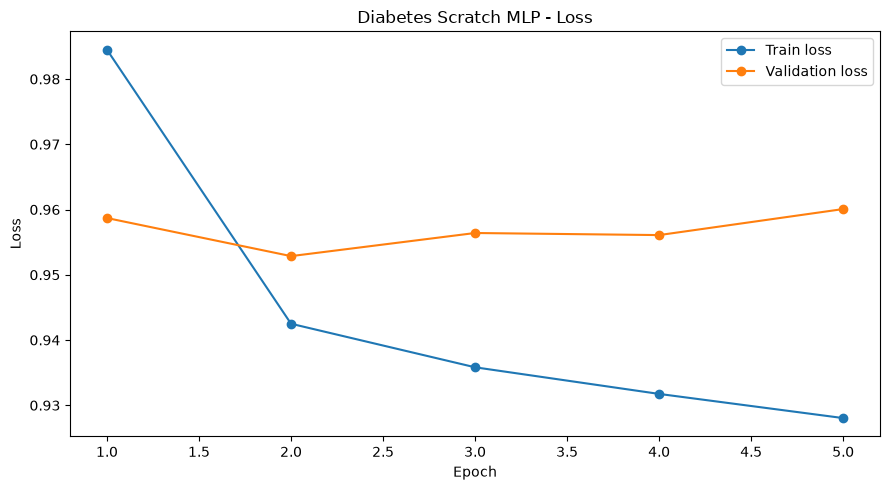

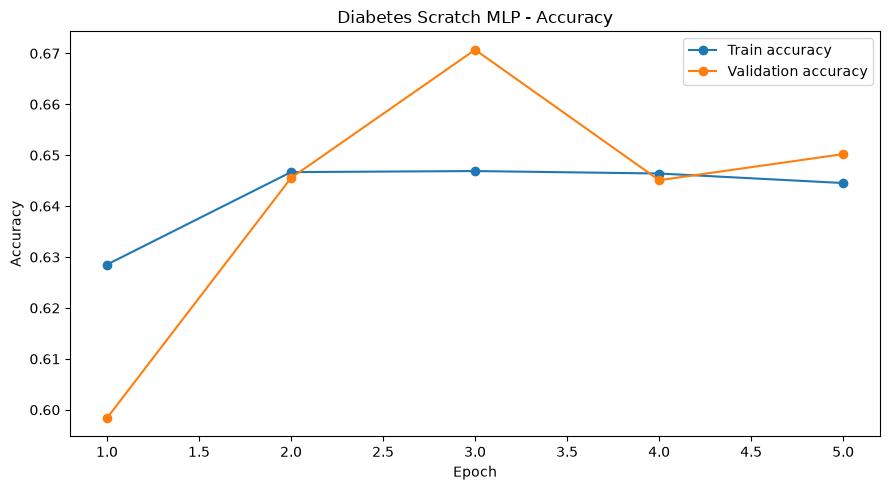

In [119]:
set_global_seed(SEED)

diabetes_num_classes = len(np.unique(y_diabetes_tr))

diabetes_scratch_params, diabetes_scratch_history, diabetes_scratch_time = train_scratch_mlp(
    X_diabetes_tr,
    y_diabetes_tr,
    X_diabetes_val,
    y_diabetes_val,
    input_dim=X_diabetes_tr.shape[1],
    num_classes=diabetes_num_classes,
    class_weights=diabetes_class_weights,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LEARNING_RATE,
    seed=SEED,
)

plot_training_history(
    diabetes_scratch_history,
    title="Diabetes Scratch MLP",
)

accuracy                    0.644513
precision_macro             0.436117
recall_macro                0.525018
f1_macro                    0.422389
precision_weighted          0.849747
recall_weighted             0.644513
f1_weighted                 0.709948
mean_confidence             0.589493
parameters               3587.000000
training_time_seconds       2.660124
epochs                      5.000000
dtype: float64


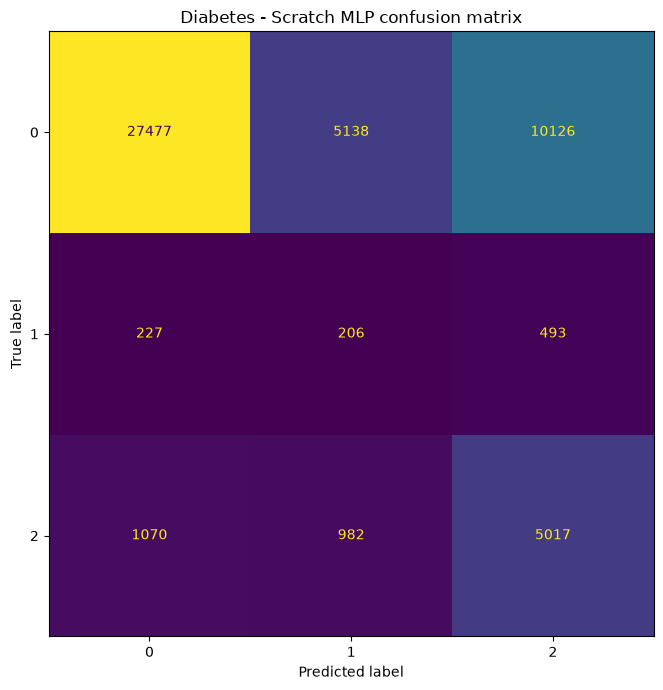

<Figure size 1000x600 with 0 Axes>

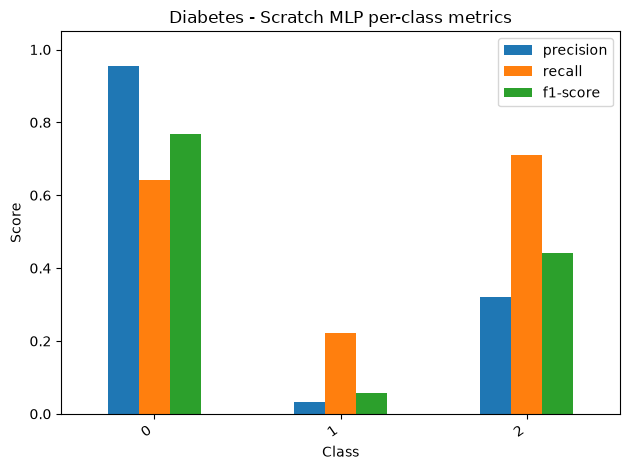

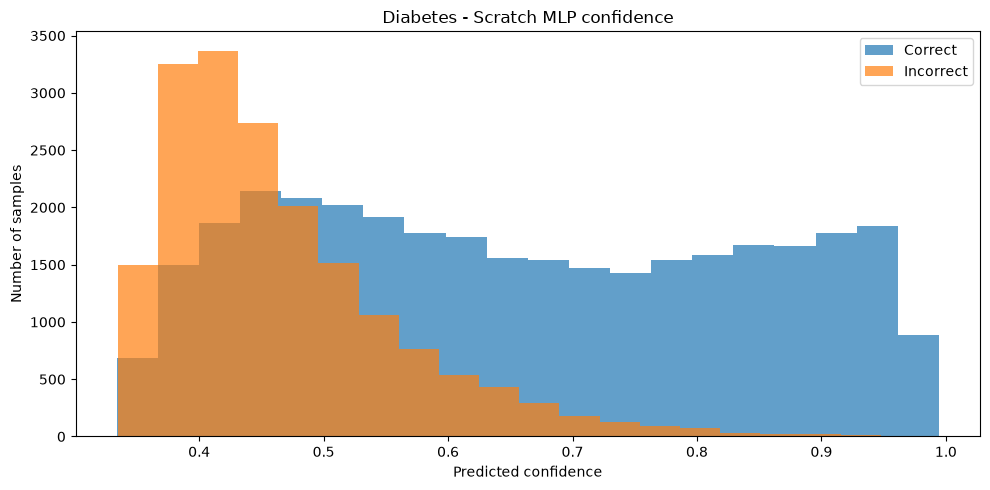

In [120]:
diabetes_scratch_pred, diabetes_scratch_prob = predict_scratch_mlp(
    X_diabetes_te,
    diabetes_scratch_params,
)

diabetes_scratch_metrics = compute_classification_metrics(
    y_diabetes_te,
    diabetes_scratch_pred,
    diabetes_scratch_prob,
)

diabetes_scratch_metrics["parameters"] = count_numpy_parameters(diabetes_scratch_params)
diabetes_scratch_metrics["training_time_seconds"] = diabetes_scratch_time
diabetes_scratch_metrics["epochs"] = EPOCHS

print(pd.Series(diabetes_scratch_metrics))

show_confusion_matrix(
    y_diabetes_te,
    diabetes_scratch_pred,
    [str(v) for v in sorted(np.unique(y_diabetes_te))],
    "Diabetes - Scratch MLP confusion matrix",
)

diabetes_scratch_report = show_classification_report(
    y_diabetes_te,
    diabetes_scratch_pred,
    [str(v) for v in sorted(np.unique(y_diabetes_te))],
    "Diabetes - Scratch MLP per-class metrics",
)

show_confidence_distribution(
    diabetes_scratch_prob,
    y_diabetes_te == diabetes_scratch_pred,
    "Diabetes - Scratch MLP confidence",
)

## 25. Diabetes with PyTorch

The architecture is kept equivalent to the Scratch MLP:

```text
Linear(64) -> ReLU -> Linear(32) -> ReLU -> Linear(3)
```

The main difference is who performs the low-level work:

- Scratch: the notebook implements the formulas and gradients.
- PyTorch: autograd calculates gradients.

In [121]:
class SimpleMLPPyTorch(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes),
        )

    def forward(self, x):
        return self.network(x)


def train_torch_mlp(
    X_train, y_train,
    X_val, y_val,
    input_dim,
    num_classes,
    class_weights,
    epochs=5,
    batch_size=128,
    lr=1e-3,
    seed=42,
):
    set_global_seed(seed)

    model = SimpleMLPPyTorch(
        input_dim,
        num_classes,
    ).to(DEVICE)

    train_ds = TensorDataset(
        torch.from_numpy(X_train),
        torch.from_numpy(y_train),
    )
    val_ds = TensorDataset(
        torch.from_numpy(X_val),
        torch.from_numpy(y_val),
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
    )

    weight_tensor = torch.tensor(
        class_weights,
        dtype=torch.float32,
        device=DEVICE,
    )

    criterion = nn.CrossEntropyLoss(weight=weight_tensor)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
    )

    history = {
        "loss": [],
        "accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
    }

    best_state = None
    best_val_loss = float("inf")

    start_time = time.perf_counter()

    for epoch in range(epochs):
        model.train()

        train_loss_sum = 0.0
        train_correct = 0
        train_seen = 0

        for features, labels in train_loader:
            features = features.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()

            outputs = model(features)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * len(features)
            train_correct += int((outputs.argmax(dim=1) == labels).sum().item())
            train_seen += len(features)

        model.eval()

        val_loss_sum = 0.0
        val_correct = 0
        val_seen = 0

        with torch.no_grad():
            for features, labels in val_loader:
                features = features.to(DEVICE)
                labels = labels.to(DEVICE)

                outputs = model(features)
                loss = criterion(outputs, labels)

                val_loss_sum += loss.item() * len(features)
                val_correct += int((outputs.argmax(dim=1) == labels).sum().item())
                val_seen += len(features)

        train_loss = train_loss_sum / train_seen
        train_acc = train_correct / train_seen
        val_loss = val_loss_sum / val_seen
        val_acc = val_correct / val_seen

        history["loss"].append(float(train_loss))
        history["accuracy"].append(float(train_acc))
        history["val_loss"].append(float(val_loss))
        history["val_accuracy"].append(float(val_acc))

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"loss={train_loss:.4f} | "
            f"acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_acc={val_acc:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

    elapsed = time.perf_counter() - start_time
    model.load_state_dict(best_state)

    return model, history, elapsed

Epoch 1/5 | loss=0.9513 | acc=0.6360 | val_loss=0.9443 | val_acc=0.6926
Epoch 2/5 | loss=0.9388 | acc=0.6558 | val_loss=0.9433 | val_acc=0.6257
Epoch 3/5 | loss=0.9339 | acc=0.6508 | val_loss=0.9411 | val_acc=0.6488
Epoch 4/5 | loss=0.9328 | acc=0.6501 | val_loss=0.9436 | val_acc=0.6791
Epoch 5/5 | loss=0.9307 | acc=0.6464 | val_loss=0.9411 | val_acc=0.6404


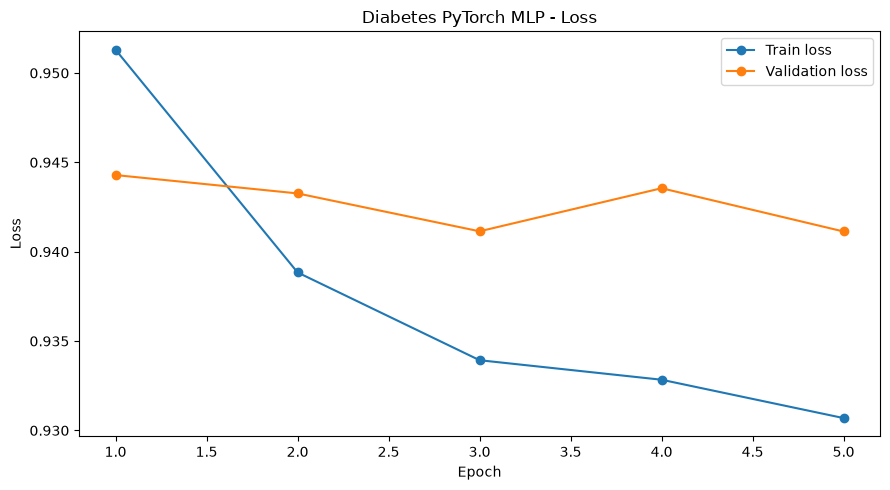

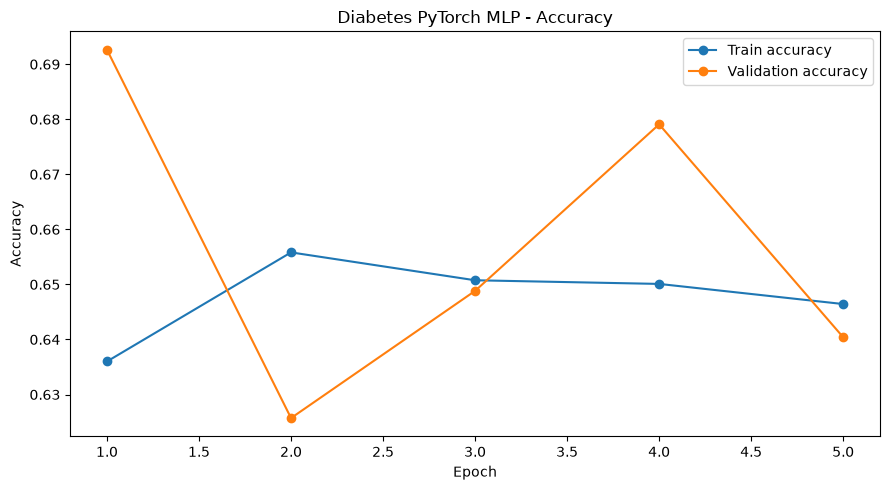

In [122]:
diabetes_torch_model, diabetes_torch_history, diabetes_torch_time = train_torch_mlp(
    X_diabetes_tr,
    y_diabetes_tr,
    X_diabetes_val,
    y_diabetes_val,
    input_dim=X_diabetes_tr.shape[1],
    num_classes=diabetes_num_classes,
    class_weights=diabetes_class_weights,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LEARNING_RATE,
    seed=SEED,
)

plot_training_history(
    diabetes_torch_history,
    title="Diabetes PyTorch MLP",
)

accuracy                    0.639999
precision_macro             0.442533
recall_macro                0.527373
f1_macro                    0.425242
precision_weighted          0.852344
recall_weighted             0.639999
f1_weighted                 0.712216
mean_confidence             0.591627
parameters               3587.000000
training_time_seconds      31.134991
epochs                      5.000000
dtype: float64


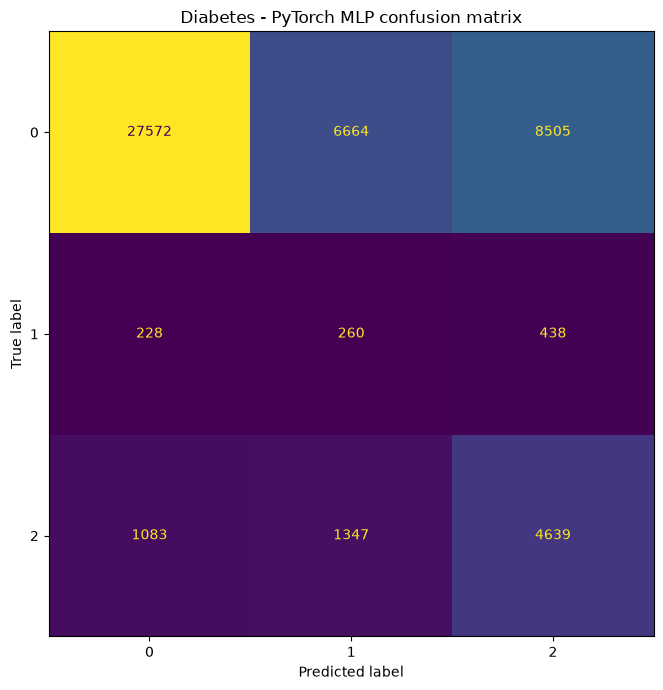

<Figure size 1000x600 with 0 Axes>

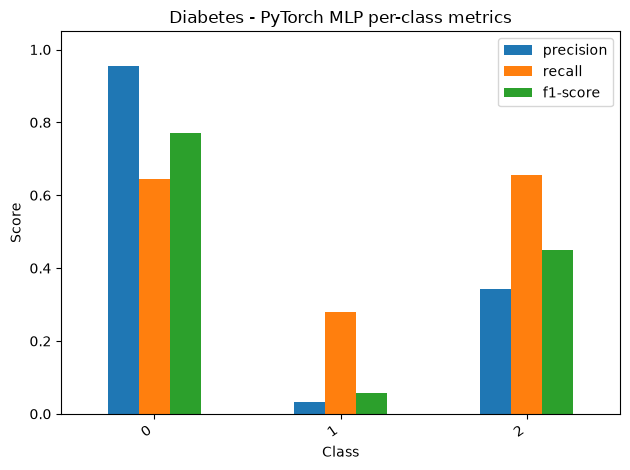

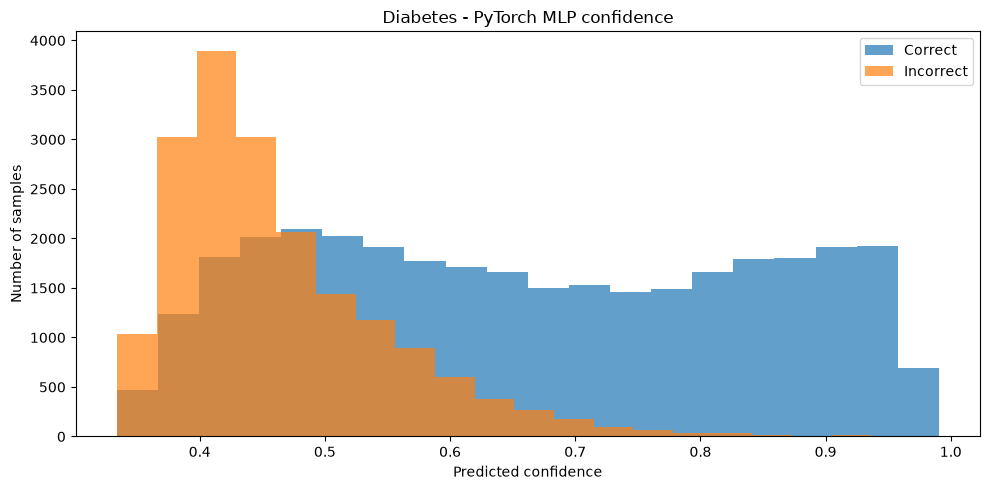

In [123]:
def predict_torch_mlp(model, X, batch_size=256):
    loader = DataLoader(
        TensorDataset(torch.from_numpy(X)),
        batch_size=batch_size,
        shuffle=False,
    )

    model.eval()
    all_prob = []

    with torch.no_grad():
        for (features,) in loader:
            features = features.to(DEVICE)
            logits = model(features)
            probabilities = torch.softmax(logits, dim=1)
            all_prob.append(probabilities.cpu().numpy())

    probabilities = np.concatenate(all_prob, axis=0)
    predictions = np.argmax(probabilities, axis=1)

    return predictions, probabilities


diabetes_torch_pred, diabetes_torch_prob = predict_torch_mlp(
    diabetes_torch_model,
    X_diabetes_te,
)

diabetes_torch_metrics = compute_classification_metrics(
    y_diabetes_te,
    diabetes_torch_pred,
    diabetes_torch_prob,
)

diabetes_torch_metrics["parameters"] = int(
    sum(p.numel() for p in diabetes_torch_model.parameters())
)
diabetes_torch_metrics["training_time_seconds"] = diabetes_torch_time
diabetes_torch_metrics["epochs"] = EPOCHS

print(pd.Series(diabetes_torch_metrics))

show_confusion_matrix(
    y_diabetes_te,
    diabetes_torch_pred,
    [str(v) for v in sorted(np.unique(y_diabetes_te))],
    "Diabetes - PyTorch MLP confusion matrix",
)

show_classification_report(
    y_diabetes_te,
    diabetes_torch_pred,
    [str(v) for v in sorted(np.unique(y_diabetes_te))],
    "Diabetes - PyTorch MLP per-class metrics",
)

show_confidence_distribution(
    diabetes_torch_prob,
    y_diabetes_te == diabetes_torch_pred,
    "Diabetes - PyTorch MLP confidence",
)

## 26. Diabetes with Keras

Keras gives the same MLP structure with a higher abstraction:

```text
Dense -> ReLU -> Dense -> ReLU -> Dense
```

The training loop is compressed into `model.fit()`.

In [124]:
def build_keras_mlp(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(num_classes),
    ])

    return model


def train_keras_mlp(
    X_train, y_train,
    X_val, y_val,
    input_dim,
    num_classes,
    class_weights,
    epochs=5,
    batch_size=128,
    lr=1e-3,
    seed=42,
):
    set_global_seed(seed)

    model = build_keras_mlp(
        input_dim,
        num_classes,
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"],
    )

    class_weight_dict = {
        int(cls): float(weight)
        for cls, weight in zip(
            np.unique(y_train),
            class_weights,
        )
    }

    start_time = time.perf_counter()

    history_obj = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        class_weight=class_weight_dict,
        epochs=epochs,
        batch_size=batch_size,
        verbose=1,
    )

    elapsed = time.perf_counter() - start_time

    history = {
        "loss": history_obj.history["loss"],
        "accuracy": history_obj.history["accuracy"],
        "val_loss": history_obj.history["val_loss"],
        "val_accuracy": history_obj.history["val_accuracy"],
    }

    return model, history, elapsed

Epoch 1/5
1427/1427 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6153 - loss: 0.9626 - val_accuracy: 0.6162 - val_loss: 0.8807
Epoch 2/5
1427/1427 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6105 - loss: 0.9450 - val_accuracy: 0.6175 - val_loss: 0.8710
Epoch 3/5
1427/1427 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6101 - loss: 0.9406 - val_accuracy: 0.6130 - val_loss: 0.8693
Epoch 4/5
1427/1427 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6087 - loss: 0.9366 - val_accuracy: 0.6102 - val_loss: 0.8720
Epoch 5/5
1427/1427 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6086 - loss: 0.9335 - val_accuracy: 0.6093 - val_loss: 0.8666


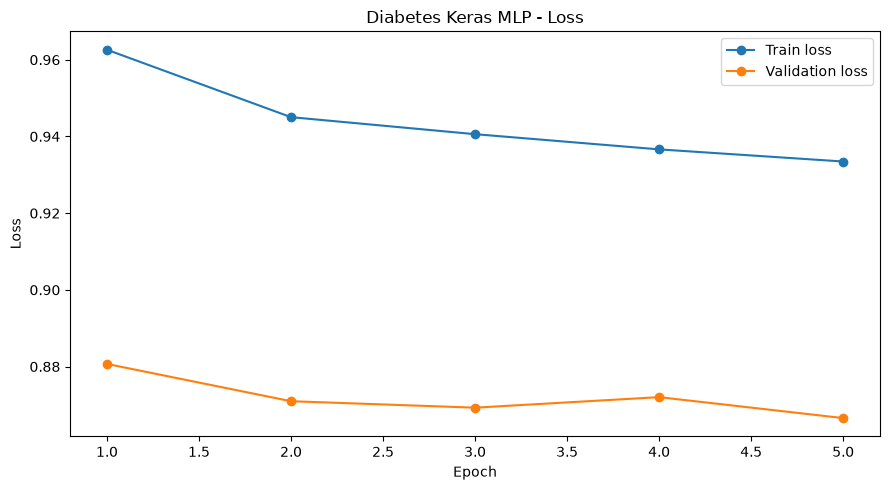

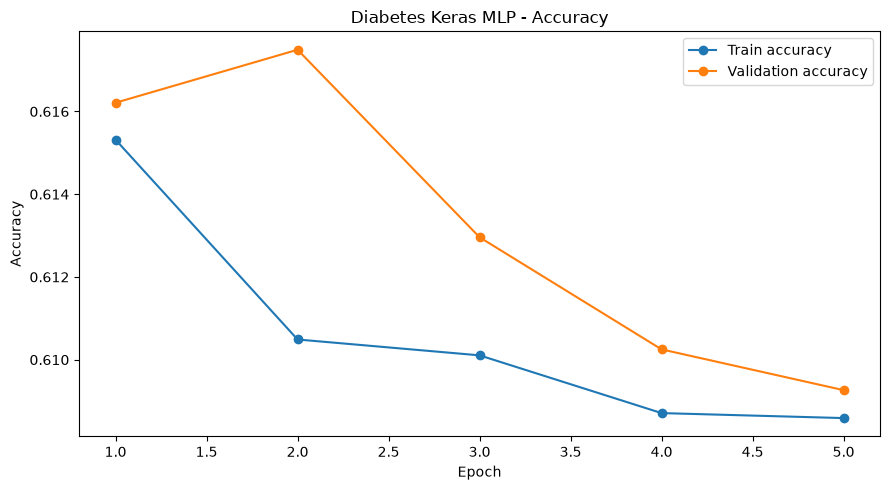

In [125]:
diabetes_keras_model, diabetes_keras_history, diabetes_keras_time = train_keras_mlp(
    X_diabetes_tr,
    y_diabetes_tr,
    X_diabetes_val,
    y_diabetes_val,
    input_dim=X_diabetes_tr.shape[1],
    num_classes=diabetes_num_classes,
    class_weights=diabetes_class_weights,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LEARNING_RATE,
    seed=SEED,
)

plot_training_history(
    diabetes_keras_history,
    title="Diabetes Keras MLP",
)

In [126]:
def predict_keras_mlp(model, X):
    # Diabetes là dữ liệu tabular nên giữ nguyên dạng (N, features)
    logits = model.predict(
        X,
        verbose=0
    )

    probabilities = softmax(logits)
    predictions = np.argmax(probabilities, axis=1)

    return predictions, probabilities

accuracy                    0.611440
precision_macro             0.440206
recall_macro                0.517610
f1_macro                    0.412757
precision_weighted          0.854727
recall_weighted             0.611440
f1_weighted                 0.692423
mean_confidence             0.591156
parameters               3587.000000
training_time_seconds      12.515781
epochs                      5.000000
dtype: float64


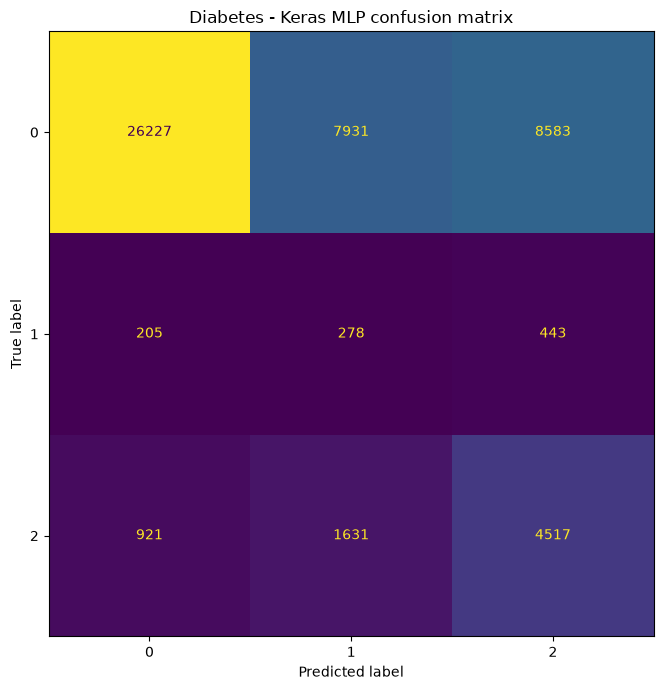

<Figure size 1000x600 with 0 Axes>

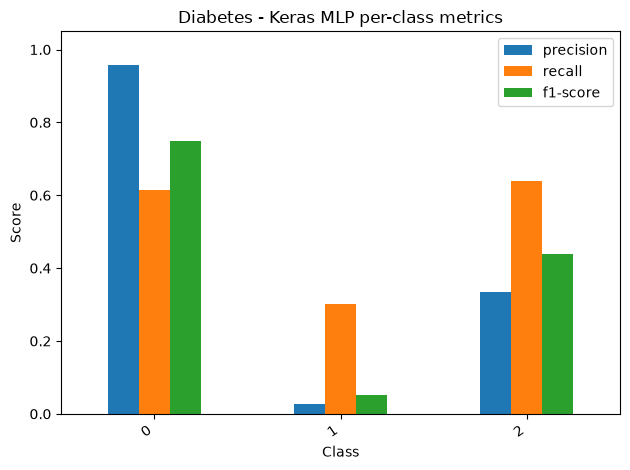

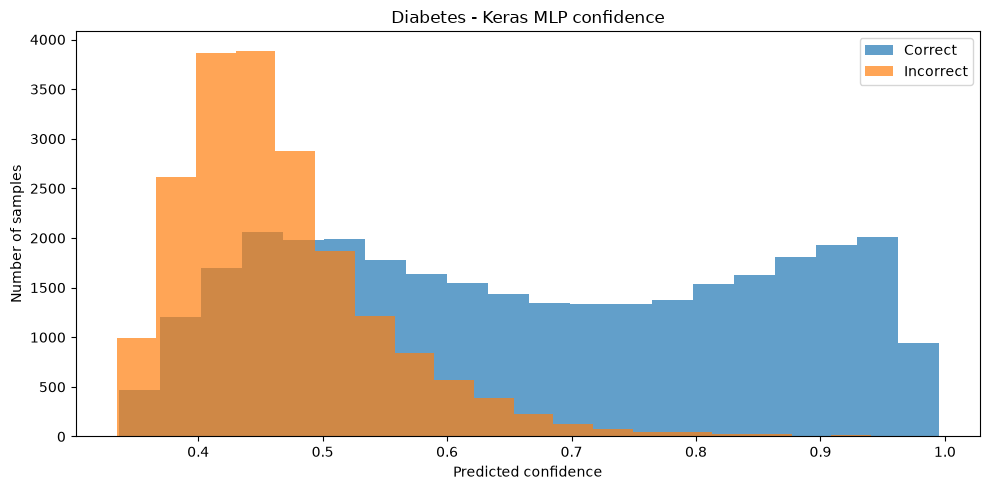

In [127]:
diabetes_keras_pred, diabetes_keras_prob = predict_keras_mlp(
    diabetes_keras_model,
    X_diabetes_te,
)

diabetes_keras_metrics = compute_classification_metrics(
    y_diabetes_te,
    diabetes_keras_pred,
    diabetes_keras_prob,
)

diabetes_keras_metrics["parameters"] = int(
    diabetes_keras_model.count_params()
)

diabetes_keras_metrics["training_time_seconds"] = diabetes_keras_time
diabetes_keras_metrics["epochs"] = EPOCHS

print(pd.Series(diabetes_keras_metrics))

show_confusion_matrix(
    y_diabetes_te,
    diabetes_keras_pred,
    [str(v) for v in sorted(np.unique(y_diabetes_te))],
    "Diabetes - Keras MLP confusion matrix",
)

show_classification_report(
    y_diabetes_te,
    diabetes_keras_pred,
    [str(v) for v in sorted(np.unique(y_diabetes_te))],
    "Diabetes - Keras MLP per-class metrics",
)

show_confidence_distribution(
    diabetes_keras_prob,
    y_diabetes_te == diabetes_keras_pred,
    "Diabetes - Keras MLP confidence",
)

## 27. Diabetes visual analysis

For a tabular dataset, an image grid is not meaningful.

Instead, we inspect:

- confusion matrix;
- class-level precision, recall and F1;
- confidence;
- PCA space;
- target distribution.

This is an example of visualization matching the data representation.

,dataset,framework,accuracy,precision_macro,recall_macro,f1_macro,mean_confidence,parameters,training_time_seconds,epochs
0,Diabetes,Scratch,0.644513,0.436117,0.525018,0.422389,0.589493,3587,2.660124,5
1,Diabetes,PyTorch,0.639999,0.442533,0.527373,0.425242,0.591627,3587,31.134991,5
2,Diabetes,Keras,0.611440,0.440206,0.517610,0.412757,0.591156,3587,12.515781,5


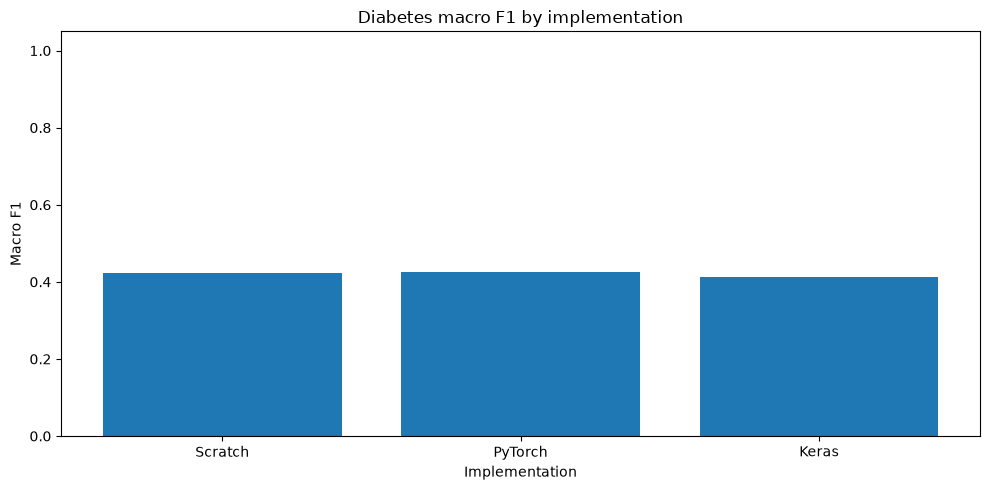

In [128]:
diabetes_results = pd.DataFrame([
    {"dataset": "Diabetes", "framework": "Scratch", **diabetes_scratch_metrics},
    {"dataset": "Diabetes", "framework": "PyTorch", **diabetes_torch_metrics},
    {"dataset": "Diabetes", "framework": "Keras", **diabetes_keras_metrics},
])

diabetes_results = diabetes_results[
    [
        "dataset",
        "framework",
        "accuracy",
        "precision_macro",
        "recall_macro",
        "f1_macro",
        "mean_confidence",
        "parameters",
        "training_time_seconds",
        "epochs",
    ]
]

display(diabetes_results)

plt.figure(figsize=(10, 5))
plt.bar(diabetes_results["framework"], diabetes_results["f1_macro"])
plt.title("Diabetes macro F1 by implementation")
plt.xlabel("Implementation")
plt.ylabel("Macro F1")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

# Part E - Final comparison and report

## 28. Framework comparison

The key lesson from Lecture 04 is:

> The same learning idea can be implemented at different levels of abstraction.

The comparison is therefore about visibility and programming structure, not only about the score.

In [129]:
all_results = pd.concat(
    [
        mnist_results,
        cifar_results,
        diabetes_results,
    ],
    ignore_index=True,
)

display(all_results)

,dataset,framework,accuracy,precision_macro,recall_macro,f1_macro,mean_confidence,parameters,training_time_seconds,epochs
0,MNIST,Scratch,0.979000,0.978987,0.978883,0.978831,0.974335,31530,139.493802,5
1,MNIST,PyTorch,0.975300,0.975397,0.975098,0.975205,0.969117,31530,26.547899,5
2,MNIST,Keras,0.978000,0.978049,0.977922,0.977931,0.970449,31530,19.982689,5
3,CIFAR-10,Scratch,0.572900,0.588441,0.572900,0.572666,0.546630,41418,188.094851,5
4,CIFAR-10,PyTorch,0.573700,0.576051,0.573700,0.564701,0.561211,41418,45.944586,5
5,CIFAR-10,Keras,0.568100,0.574029,0.568100,0.563815,0.548039,41418,19.185502,5
6,Diabetes,Scratch,0.644513,0.436117,0.525018,0.422389,0.589493,3587,2.660124,5
7,Diabetes,PyTorch,0.639999,0.442533,0.527373,0.425242,0.591627,3587,31.134991,5
8,Diabetes,Keras,0.611440,0.440206,0.517610,0.412757,0.591156,3587,12.515781,5


## 28.1 What remains the same?

Across Scratch, PyTorch and Keras, the following concepts remain:

1. Data representation.
2. The sequence of transformations.
3. The loss function idea.
4. Gradient-based optimization.
5. Evaluation with predictions and metrics.

What changes is the amount of implementation detail visible to the programmer.

### Scratch

Most details are explicit:

- convolution arithmetic;
- pooling arithmetic;
- parameter arrays;
- forward pass;
- backward pass;
- parameter update.

### PyTorch

The model structure is explicit through modules and `forward()`, while autograd handles the derivative calculations.

### Keras

The model definition is compact and the training process is largely hidden inside `compile()` and `fit()`.

## 29. Performance comparison

The report should not stop at accuracy.

The lecture asks us to record:

- Number of parameters.
- Training time.
- Number of epochs.
- Training loss.
- Validation/test accuracy.
- Precision.
- Recall.
- F1.
- Confusion matrix.

A fair comparison uses the same:

- dataset;
- split;
- architecture;
- comparable hyperparameters.

The notebook follows that principle by reusing the same selected train/validation indices for the three implementations on each dataset.

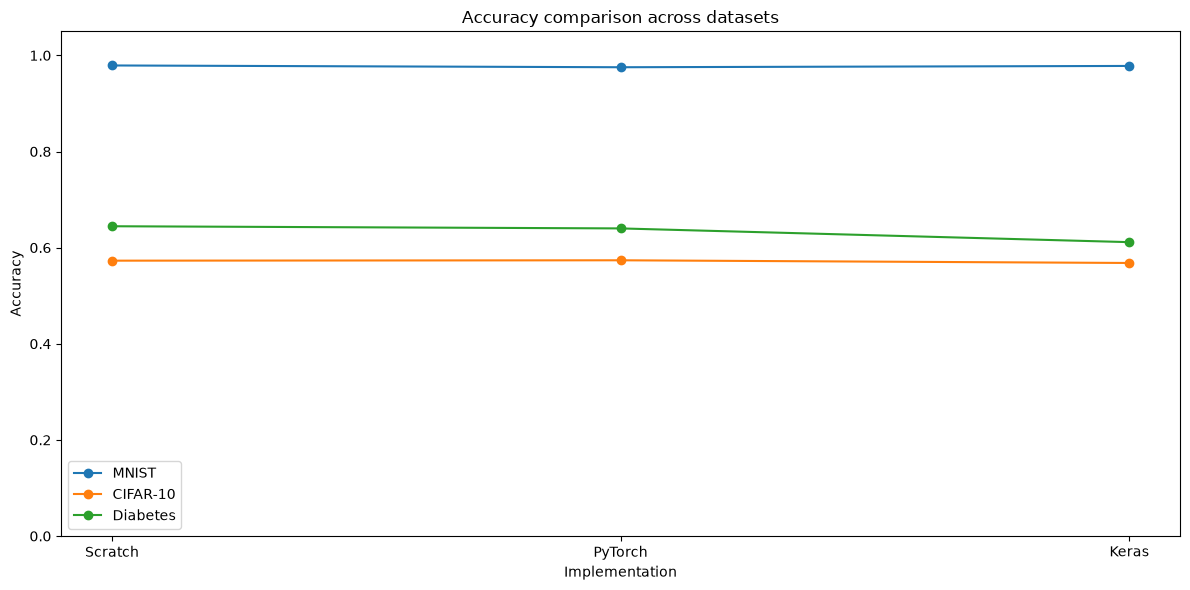

In [130]:
# Accuracy comparison across datasets.
plt.figure(figsize=(12, 6))

for dataset_name in all_results["dataset"].unique():
    subset = all_results[all_results["dataset"] == dataset_name]
    plt.plot(
        subset["framework"],
        subset["accuracy"],
        marker="o",
        label=dataset_name,
    )

plt.xlabel("Implementation")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.title("Accuracy comparison across datasets")
plt.legend()
plt.tight_layout()
plt.show()

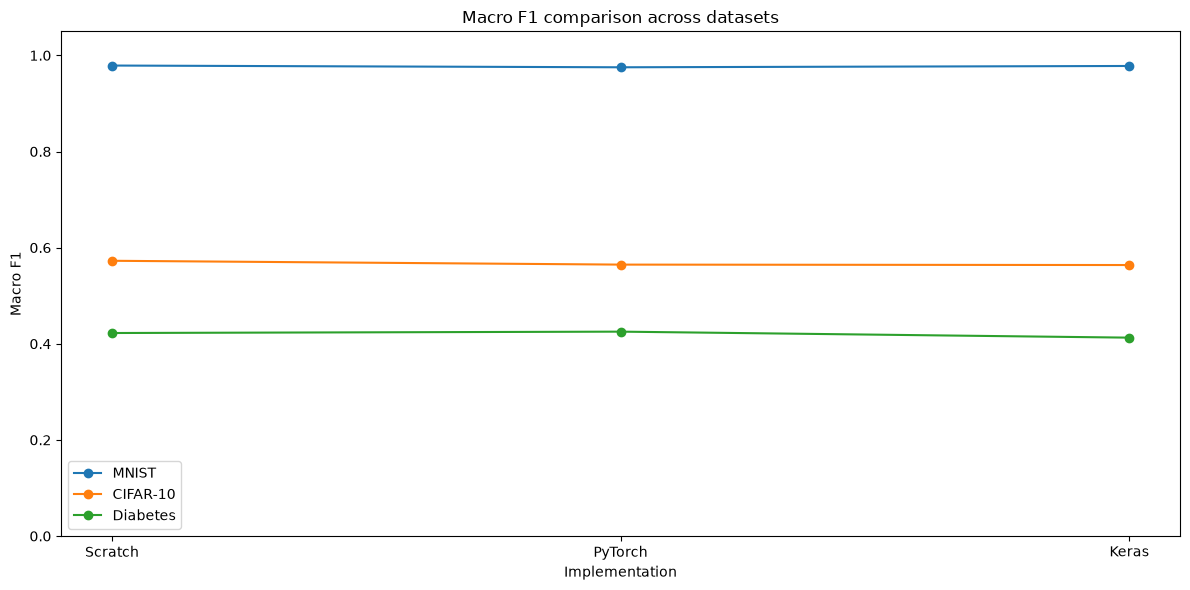

In [131]:
# Macro F1 comparison.
plt.figure(figsize=(12, 6))

for dataset_name in all_results["dataset"].unique():
    subset = all_results[all_results["dataset"] == dataset_name]
    plt.plot(
        subset["framework"],
        subset["f1_macro"],
        marker="o",
        label=dataset_name,
    )

plt.xlabel("Implementation")
plt.ylabel("Macro F1")
plt.ylim(0, 1.05)
plt.title("Macro F1 comparison across datasets")
plt.legend()
plt.tight_layout()
plt.show()

dataset,CIFAR-10,MNIST
framework,,
Keras,41418,31530
PyTorch,41418,31530
Scratch,41418,31530


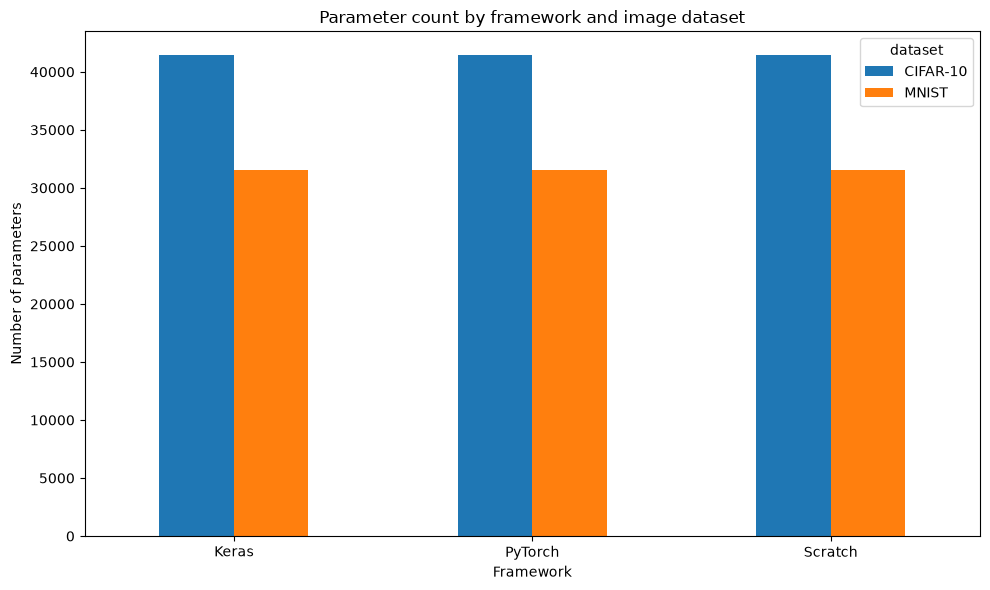

In [132]:
# Parameter count comparison for the image datasets.
image_results = all_results[
    all_results["dataset"].isin(["MNIST", "CIFAR-10"])
]

pivot_params = image_results.pivot(
    index="framework",
    columns="dataset",
    values="parameters",
)

display(pivot_params)

pivot_params.plot(kind="bar", figsize=(10, 6))
plt.title("Parameter count by framework and image dataset")
plt.xlabel("Framework")
plt.ylabel("Number of parameters")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

dataset,CIFAR-10,Diabetes,MNIST
framework,,,
Keras,19.185502,12.515781,19.982689
PyTorch,45.944586,31.134991,26.547899
Scratch,188.094851,2.660124,139.493802


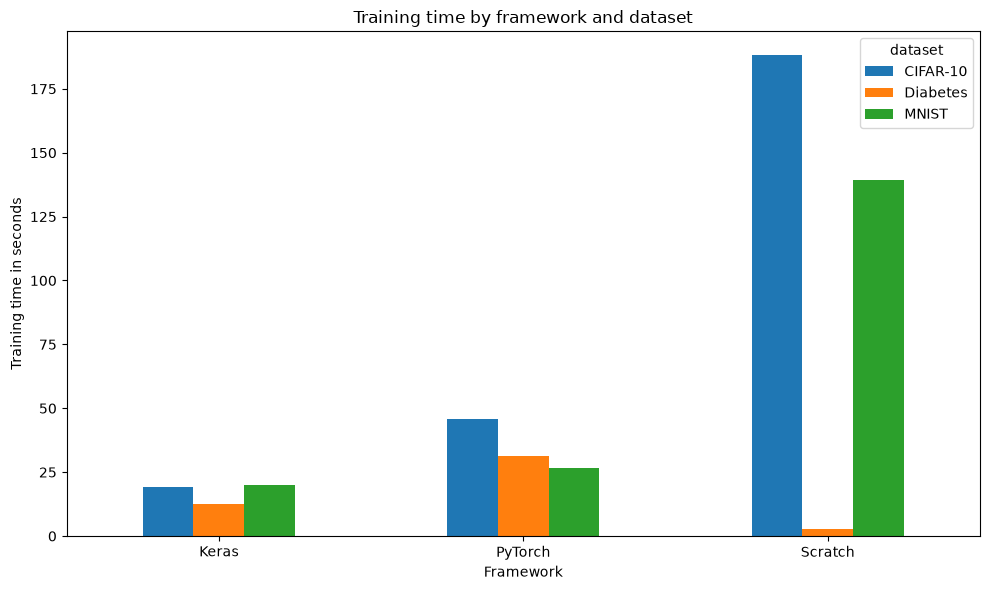

In [133]:
# Training time comparison.
pivot_time = all_results.pivot(
    index="framework",
    columns="dataset",
    values="training_time_seconds",
)

display(pivot_time)

pivot_time.plot(kind="bar", figsize=(10, 6))
plt.title("Training time by framework and dataset")
plt.xlabel("Framework")
plt.ylabel("Training time in seconds")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 30. Answers to the important questions from Lecture 04

### Question 1. What is the same, and what is different?

The mathematical learning idea is the same:

```text
Input -> transformations -> loss -> gradient -> parameter update
```

The syntax and abstraction level differ.

Scratch exposes the operations.
Keras packages them into high-level layers and training utilities.
PyTorch exposes modules and the training loop while providing automatic differentiation.

### Question 2. What computational work is hidden inside Keras `fit()`?

Conceptually, `fit()` performs repeated:

```text
Batch loading
-> Forward pass
-> Loss calculation
-> Gradient calculation
-> Parameter update
-> Metric calculation
```

The user does not have to write each of these operations explicitly.

### Question 3. Which implementation hides the most details?

Keras hides more low-level implementation details in the student-facing code, especially the training loop and differentiation.

### Question 4. Which implementation gives the programmer the most direct control?

Scratch exposes the most operations directly because the programmer writes the mathematical transformations and training mechanics.

PyTorch sits between Scratch and Keras in the notebook's comparison:

```text
Scratch -> maximum visibility
PyTorch -> modular control plus automatic differentiation
Keras -> high-level convenience
```

### Question 5. Why must tensor shapes be calculated before the Dense or Linear layer?

Because the classifier's input dimension must exactly match the flattened feature size.

For MNIST:

```text
B x 1 x 28 x 28
-> Conv
B x 16 x 28 x 28
-> Pool
B x 16 x 14 x 14
-> Flatten
B x 3136
```

Therefore the final linear layer receives 3136 features.

For CIFAR-10:

```text
B x 3 x 32 x 32
-> Conv
B x 16 x 32 x 32
-> Pool
B x 16 x 16 x 16
-> Flatten
B x 4096
```

Therefore the final linear layer receives 4096 features.

### Question 6. Why is Diabetes modeled with MLP instead of CNN?

Because Diabetes is tabular data represented as a feature vector, not a 2D image.

Lecture 04 explicitly presents:

```text
Diabetes -> MLP
MNIST -> CNN
```

The model should match the representation of the data.

### Question 7. Why should accuracy not be the only metric?

A single accuracy number can hide class-specific problems, especially with imbalanced data.

Precision, recall and F1 show class-level behavior.
The confusion matrix shows which classes are being confused.
Confidence visualization shows whether errors are made with high or low confidence.

## 31. Save trained models and website-ready outputs

The later web demo should not have to retrain a model.

This section saves:

- Scratch parameters as `.joblib`.
- PyTorch weights as `.pth`.
- Keras models as `.keras`.
- Metric summaries as JSON/CSV.
- Test predictions as CSV.

The output directory is therefore also the bridge from the Jupyter notebook to the future web application.

In [134]:
import joblib

# -----------------------------
# Save Scratch models
# -----------------------------
joblib.dump(
    mnist_scratch_params,
    MODELS_DIR / "mnist_cnn_scratch.joblib",
)

joblib.dump(
    cifar_scratch_params,
    MODELS_DIR / "cifar10_cnn_scratch.joblib",
)

joblib.dump(
    diabetes_scratch_params,
    MODELS_DIR / "diabetes_mlp_scratch.joblib",
)

# Save preprocessing object for Diabetes.
joblib.dump(
    diabetes_scaler,
    MODELS_DIR / "diabetes_standard_scaler.joblib",
)

# -----------------------------
# Save PyTorch models
# -----------------------------
torch.save(
    mnist_torch_model.state_dict(),
    MODELS_DIR / "mnist_cnn_pytorch.pth",
)

torch.save(
    cifar_torch_model.state_dict(),
    MODELS_DIR / "cifar10_cnn_pytorch.pth",
)

torch.save(
    diabetes_torch_model.state_dict(),
    MODELS_DIR / "diabetes_mlp_pytorch.pth",
)

# -----------------------------
# Save Keras models
# -----------------------------
mnist_keras_model.save(
    MODELS_DIR / "mnist_cnn_keras.keras"
)

cifar_keras_model.save(
    MODELS_DIR / "cifar10_cnn_keras.keras"
)

diabetes_keras_model.save(
    MODELS_DIR / "diabetes_mlp_keras.keras"
)

print("Models saved to:", MODELS_DIR)

Models saved to: C:\Users\ADMIN\Downloads\Intelligent System\assignment 4\DATA\models


In [135]:
# Save metrics.
save_metrics(
    mnist_scratch_metrics,
    METRICS_DIR / "mnist_scratch_metrics.json",
)
save_metrics(
    mnist_torch_metrics,
    METRICS_DIR / "mnist_pytorch_metrics.json",
)
save_metrics(
    mnist_keras_metrics,
    METRICS_DIR / "mnist_keras_metrics.json",
)

save_metrics(
    cifar_scratch_metrics,
    METRICS_DIR / "cifar10_scratch_metrics.json",
)
save_metrics(
    cifar_torch_metrics,
    METRICS_DIR / "cifar10_pytorch_metrics.json",
)
save_metrics(
    cifar_keras_metrics,
    METRICS_DIR / "cifar10_keras_metrics.json",
)

save_metrics(
    diabetes_scratch_metrics,
    METRICS_DIR / "diabetes_scratch_metrics.json",
)
save_metrics(
    diabetes_torch_metrics,
    METRICS_DIR / "diabetes_pytorch_metrics.json",
)
save_metrics(
    diabetes_keras_metrics,
    METRICS_DIR / "diabetes_keras_metrics.json",
)

all_results.to_csv(
    METRICS_DIR / "all_model_comparison.csv",
    index=False,
)

print("Metrics saved to:", METRICS_DIR)

Metrics saved to: C:\Users\ADMIN\Downloads\Intelligent System\assignment 4\DATA\outputs\metrics


In [136]:
# Save website-friendly prediction tables.

mnist_demo_df = pd.DataFrame({
    "true_label": mnist_y_te,
    "scratch_prediction": mnist_scratch_pred,
    "scratch_confidence": np.max(mnist_scratch_prob, axis=1),
    "pytorch_prediction": mnist_torch_pred,
    "pytorch_confidence": np.max(mnist_torch_prob, axis=1),
    "keras_prediction": mnist_keras_pred,
    "keras_confidence": np.max(mnist_keras_prob, axis=1),
})

cifar_demo_df = pd.DataFrame({
    "true_label": cifar_y_te,
    "scratch_prediction": cifar_scratch_pred,
    "scratch_confidence": np.max(cifar_scratch_prob, axis=1),
    "pytorch_prediction": cifar_torch_pred,
    "pytorch_confidence": np.max(cifar_torch_prob, axis=1),
    "keras_prediction": cifar_keras_pred,
    "keras_confidence": np.max(cifar_keras_prob, axis=1),
})

diabetes_demo_df = pd.DataFrame({
    "true_label": y_diabetes_te,
    "scratch_prediction": diabetes_scratch_pred,
    "scratch_confidence": np.max(diabetes_scratch_prob, axis=1),
    "pytorch_prediction": diabetes_torch_pred,
    "pytorch_confidence": np.max(diabetes_torch_prob, axis=1),
    "keras_prediction": diabetes_keras_pred,
    "keras_confidence": np.max(diabetes_keras_prob, axis=1),
})

mnist_demo_df.to_csv(
    PREDICTIONS_DIR / "mnist_predictions.csv",
    index=False,
)

cifar_demo_df.to_csv(
    PREDICTIONS_DIR / "cifar10_predictions.csv",
    index=False,
)

diabetes_demo_df.to_csv(
    PREDICTIONS_DIR / "diabetes_predictions.csv",
    index=False,
)

print("Prediction tables saved to:", PREDICTIONS_DIR)

Prediction tables saved to: C:\Users\ADMIN\Downloads\Intelligent System\assignment 4\DATA\outputs\predictions


## 31.1 A simple notebook demo

The future website can follow the same idea as this notebook demo:

```text
Input image
-> select model
-> preprocess
-> model prediction
-> class probabilities
-> confidence
-> visualization
```

The web application should eventually expose:

- predicted class;
- probability for every class;
- confidence;
- model name;
- training metrics;
- confusion matrix and charts;
- example predictions;
- model comparison.

That design is consistent with the current notebook outputs and avoids retraining during a demo.

In [137]:
def demo_mnist_prediction(index=0, model_name="PyTorch"):
    image = mnist_x_test[index:index + 1]

    if model_name.lower() == "scratch":
        pred, prob = predict_scratch_cnn(image, mnist_scratch_params)

    elif model_name.lower() == "pytorch":
        pred, prob = predict_torch(mnist_torch_model, image)

    elif model_name.lower() == "keras":
        pred, prob = predict_keras(mnist_keras_model, image)

    else:
        raise ValueError("model_name must be Scratch, PyTorch or Keras")

    predicted_class = int(pred[0])
    confidence = float(prob[0, predicted_class])

    plt.figure(figsize=(5, 5))
    plt.imshow(image[0, 0], cmap="gray")
    plt.title(
        f"Model: {model_name}\n"
        f"Prediction: {predicted_class}\n"
        f"Confidence: {confidence:.3f}"
    )
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    probability_table = pd.DataFrame({
        "class": IMAGE_CLASS_NAMES["mnist"],
        "probability": prob[0],
    }).sort_values(
        "probability",
        ascending=False,
    )

    display(probability_table)

    return predicted_class, probability_table


# Example:
# demo_mnist_prediction(index=0, model_name="PyTorch")

# 32. Final conclusions

## 32.1 Conceptual conclusion

The notebook follows the central conceptual map:

```text
Mathematical function
-> Neuron
-> Nonlinear neuron
-> Layer
-> Function composition
-> CNN
-> Training
-> Evaluation
-> Modern architectural ideas
```

The implementation comparison follows:

```text
Understand
-> Implement
-> Abstract
-> Compare
```

## 32.2 CNN conclusion

For image data, the key CNN ideas demonstrated are:

- Local connectivity.
- Weight sharing.
- Convolution.
- Nonlinearity.
- Spatial downsampling.
- Shape tracking.
- Classification.
- Gradient-based training.

## 32.3 Framework conclusion

The three implementations are not three different mathematical learning systems.

They are three programming abstractions for related computations:

```text
Scratch
    -> explicit mathematical operations

Keras
    -> high-level layer and training API

PyTorch
    -> modular layers and explicit forward/training flow
```

## 32.4 Evaluation conclusion

A serious model report should show more than accuracy.

This notebook therefore records:

- accuracy;
- precision;
- recall;
- macro F1;
- weighted F1;
- confidence;
- parameter count;
- training time;
- training history;
- confusion matrix;
- incorrect predictions.

## 32.5 Demo conclusion

The saved models and output tables are deliberately structured so that the later web application can load the trained artifacts instead of retraining them.
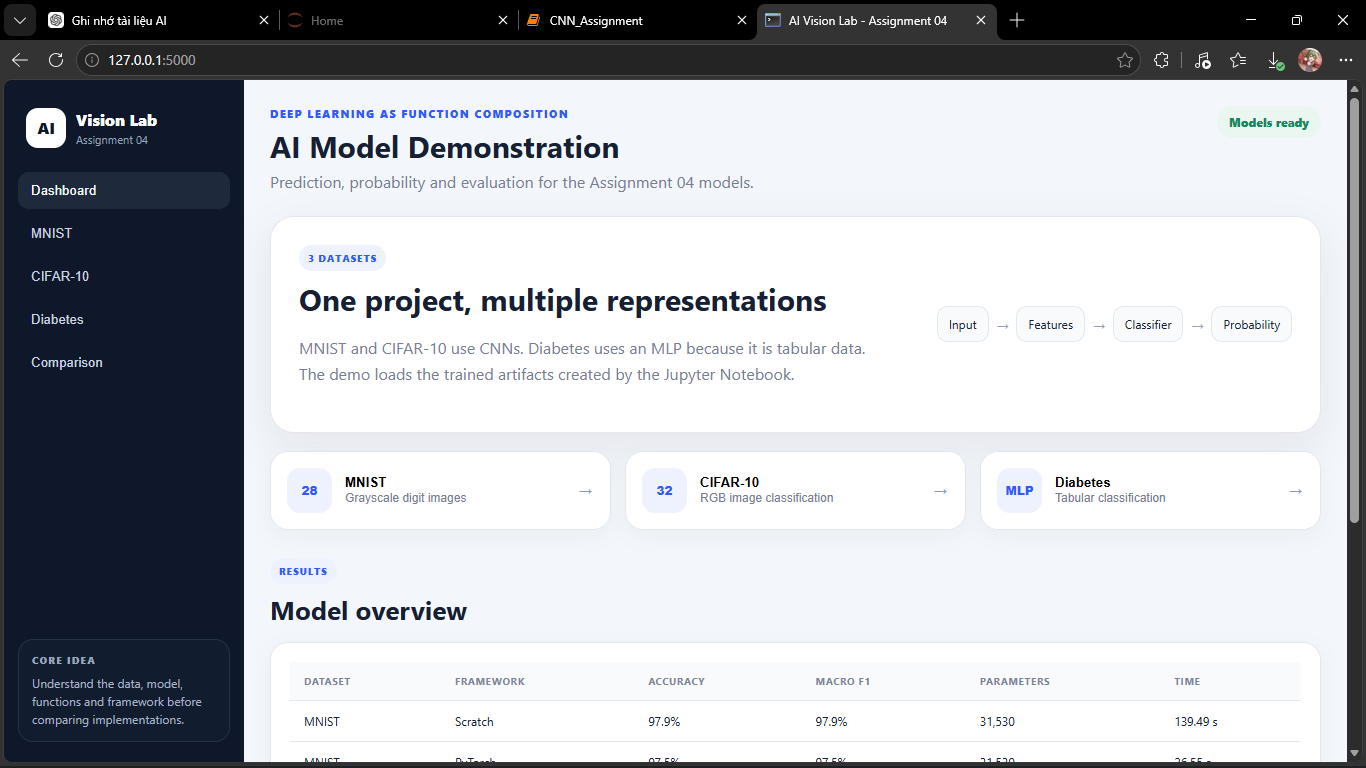
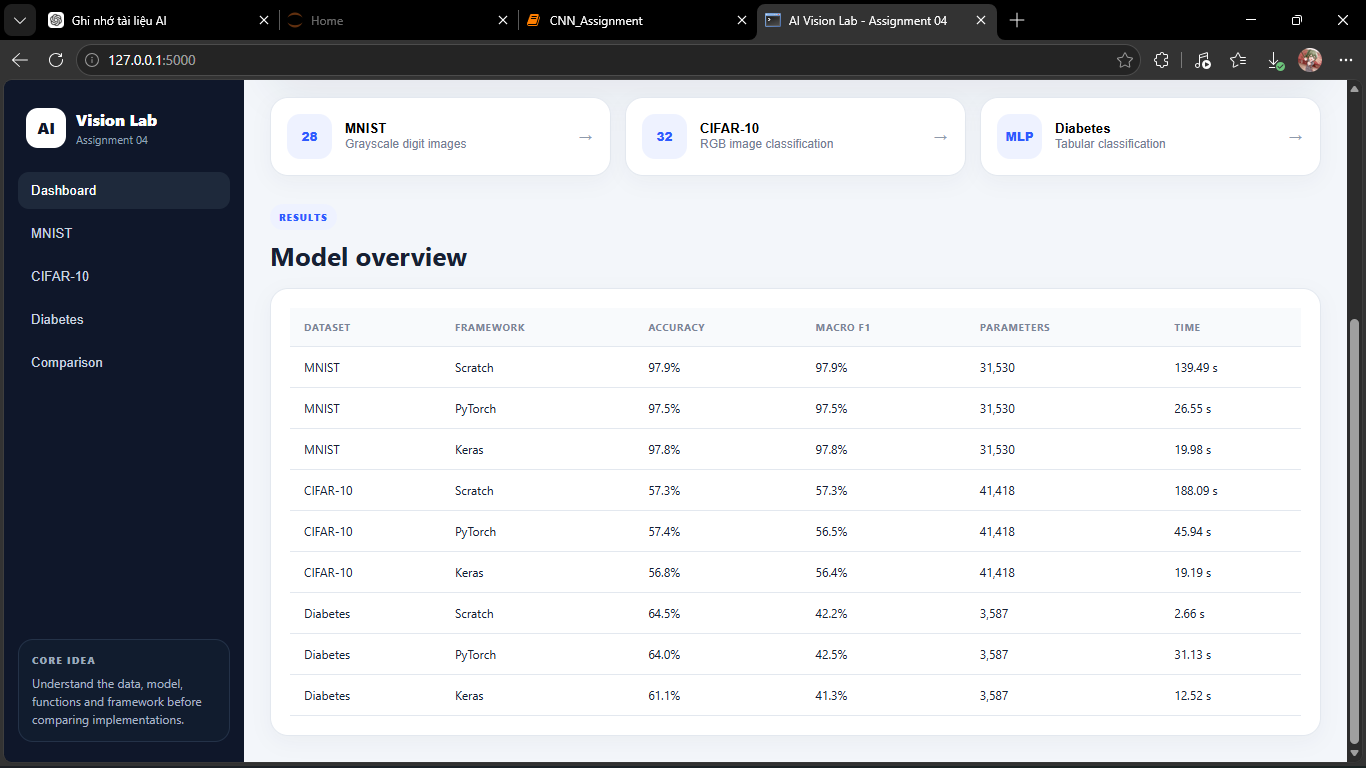
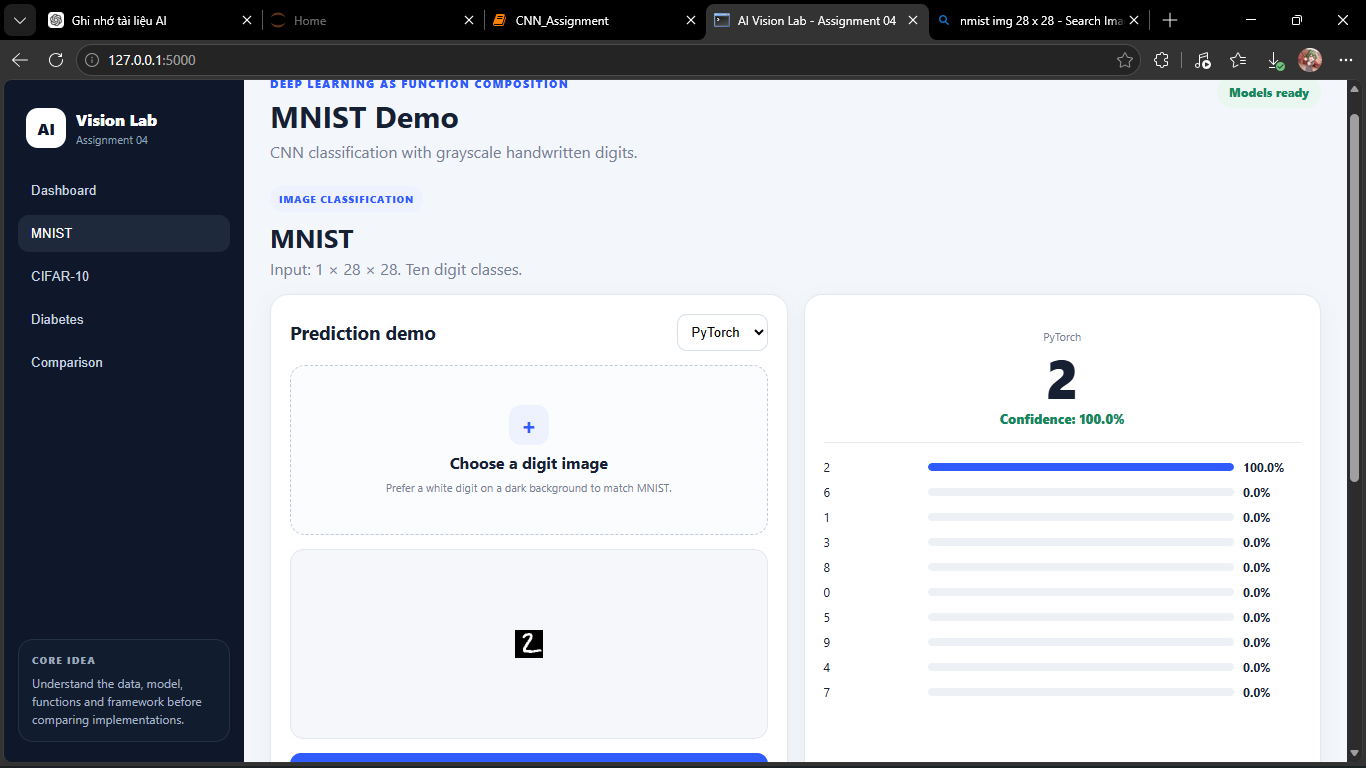
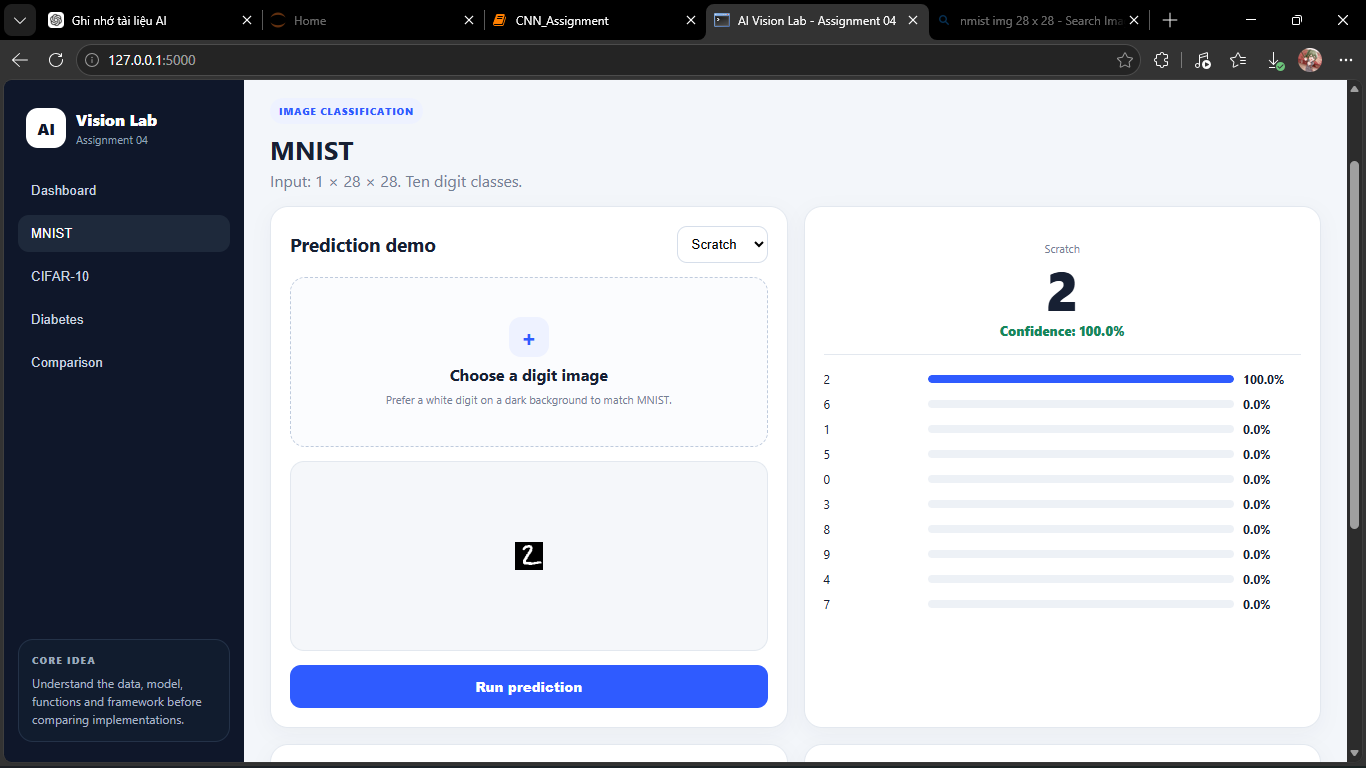
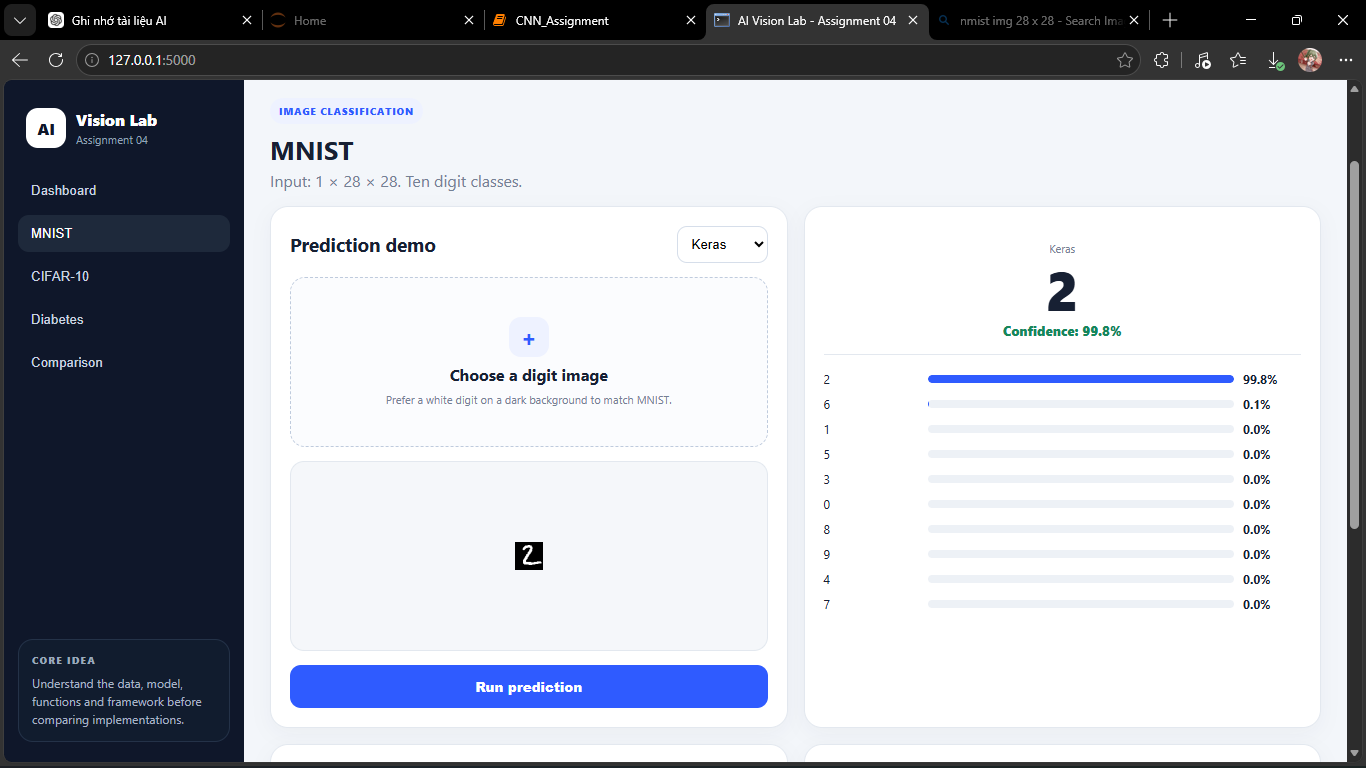
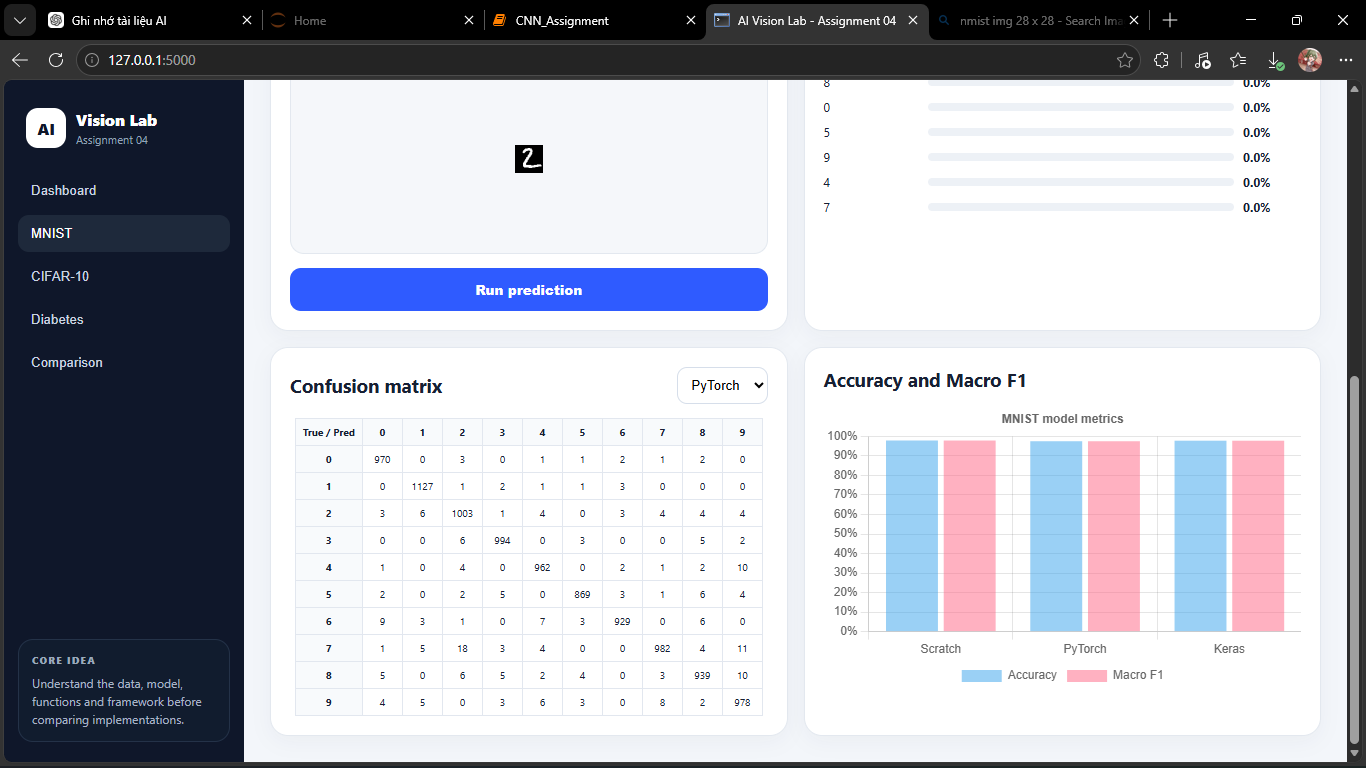
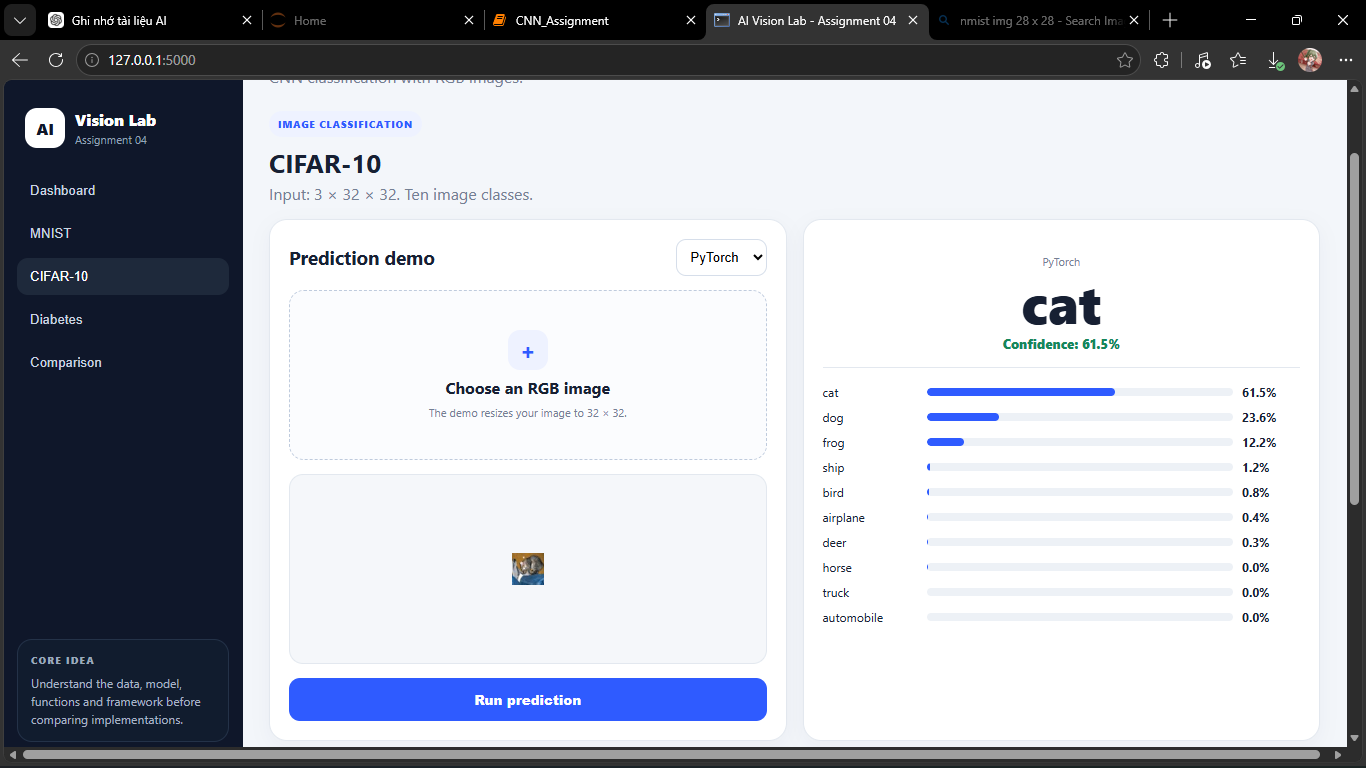
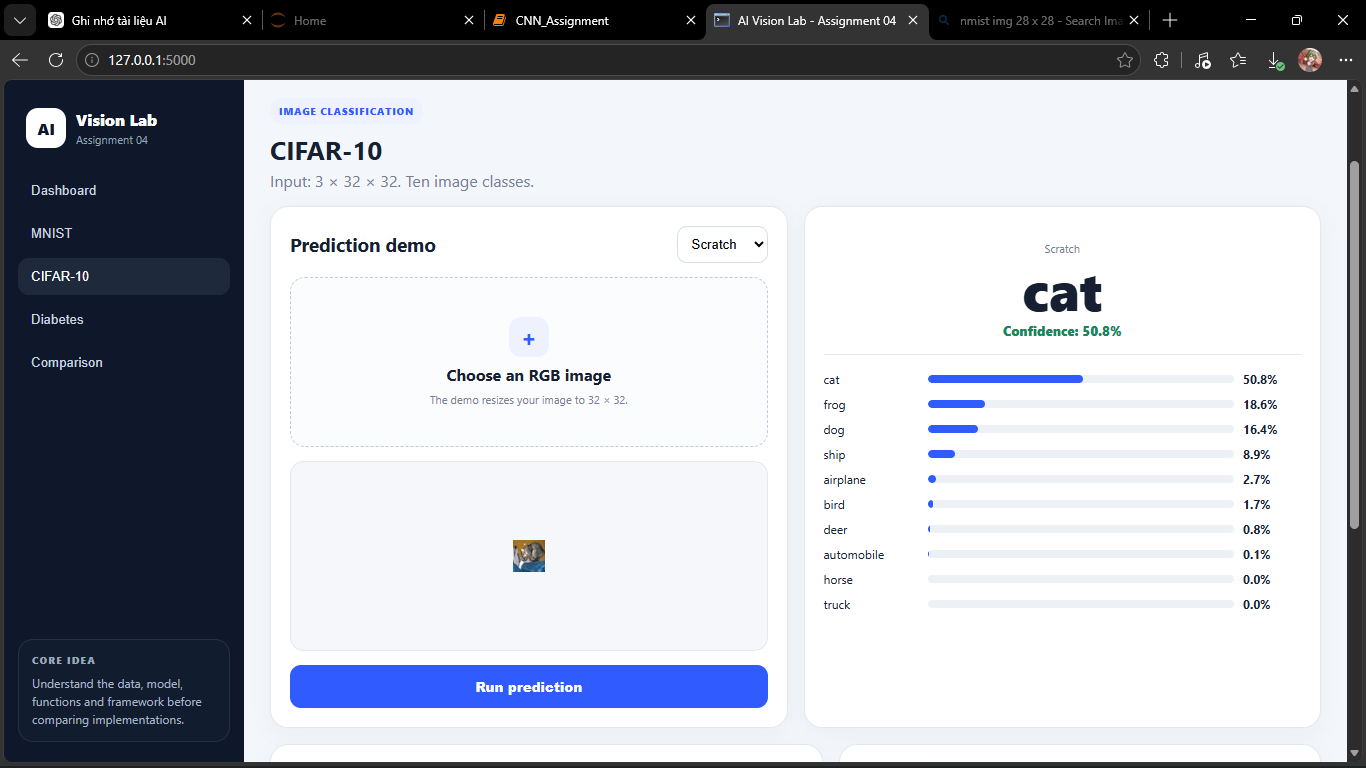
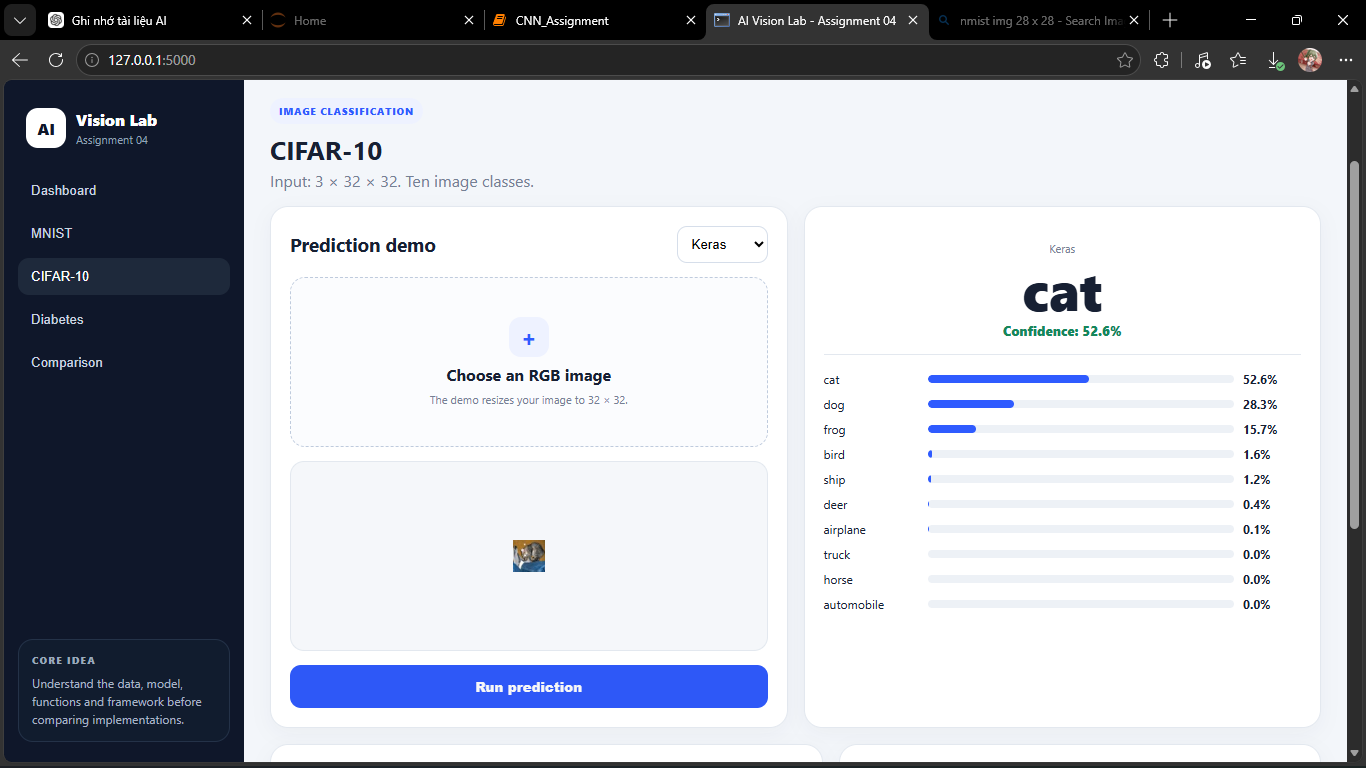
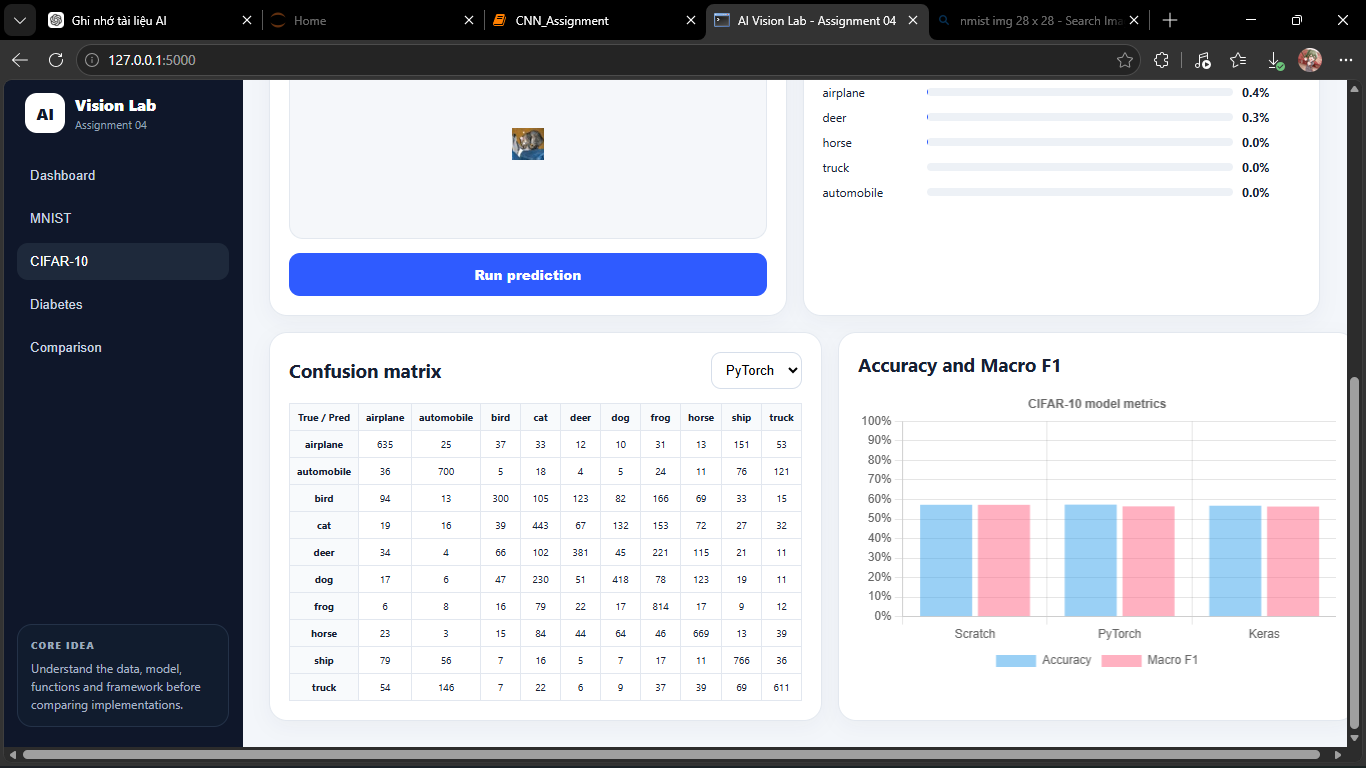
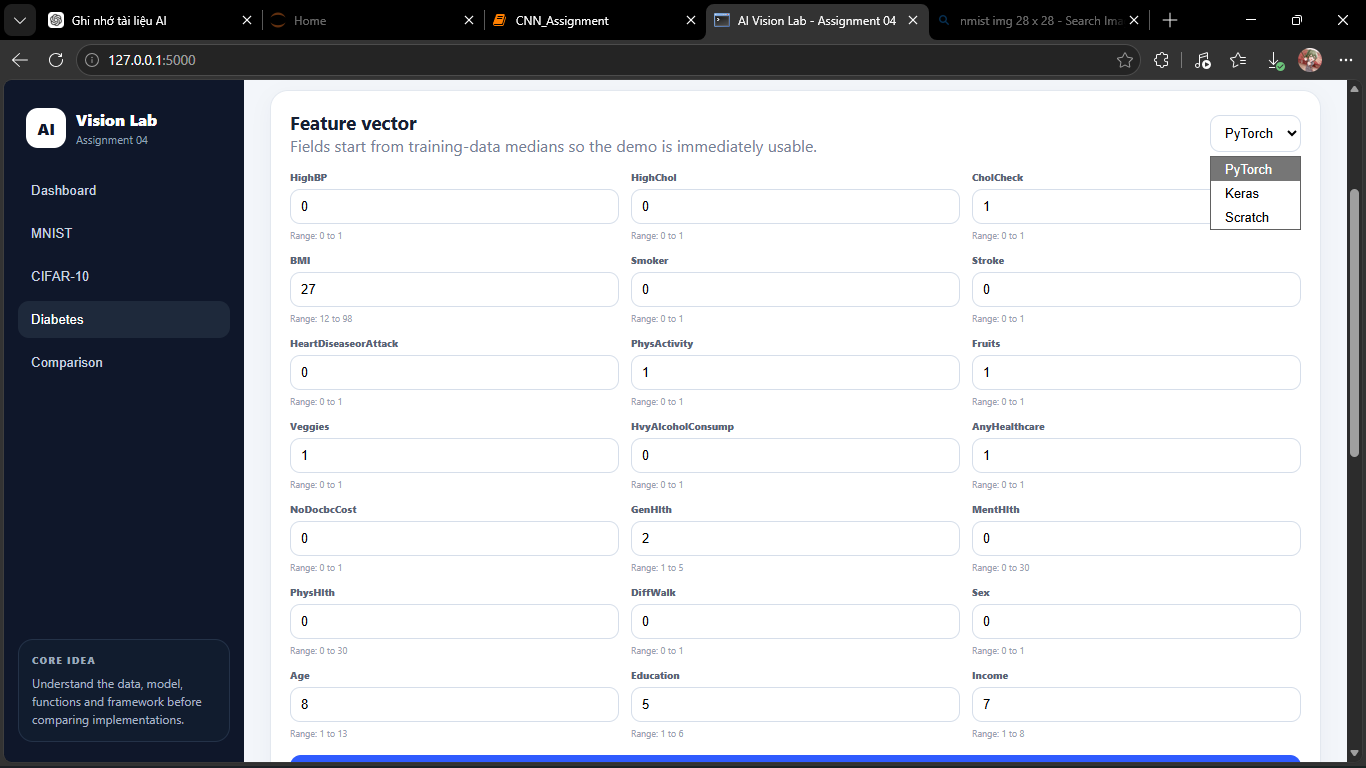
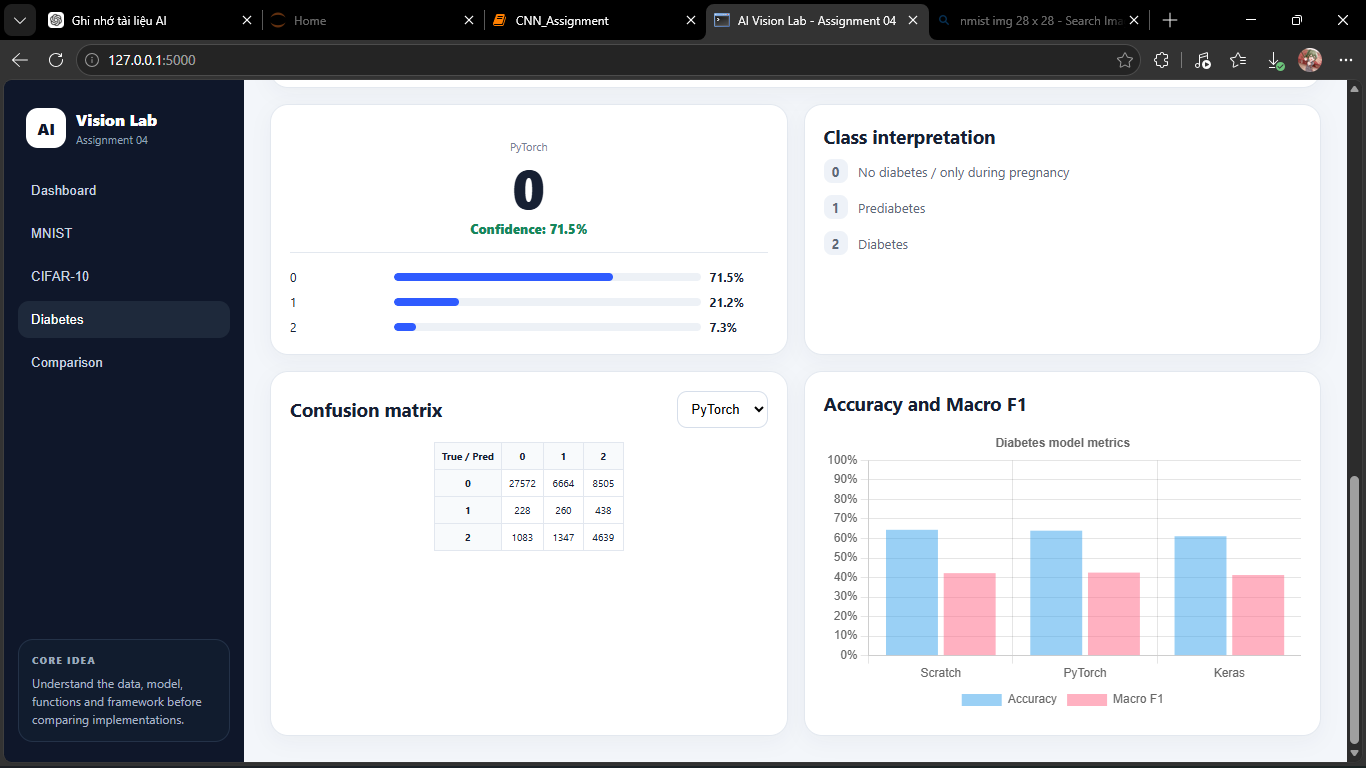
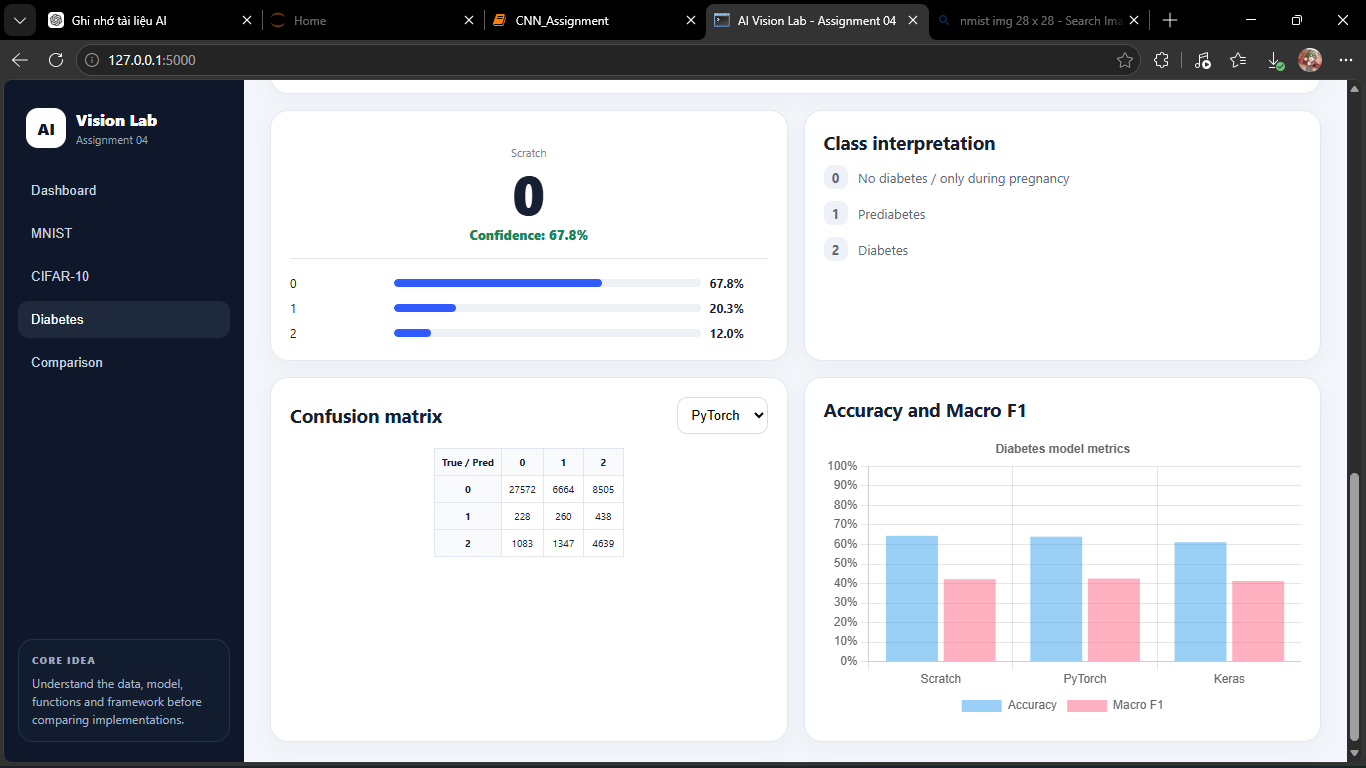
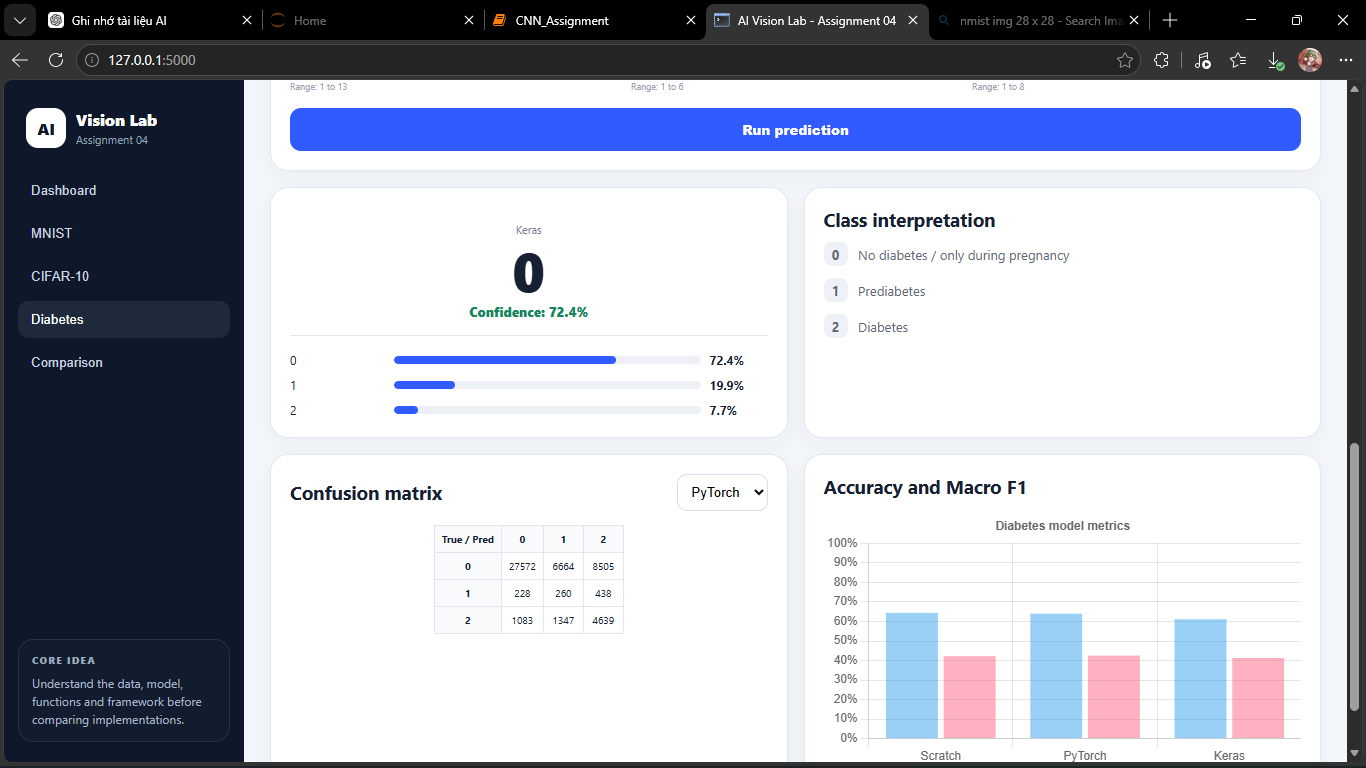
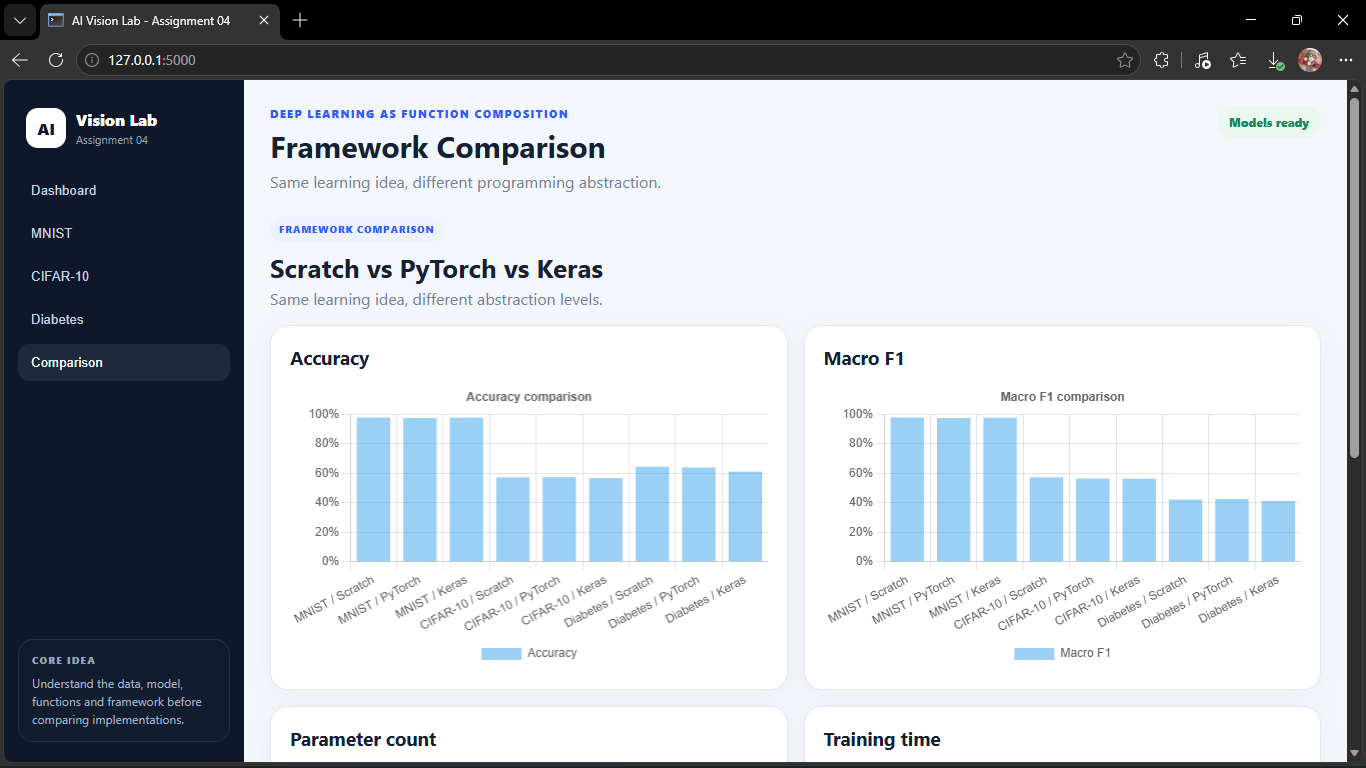
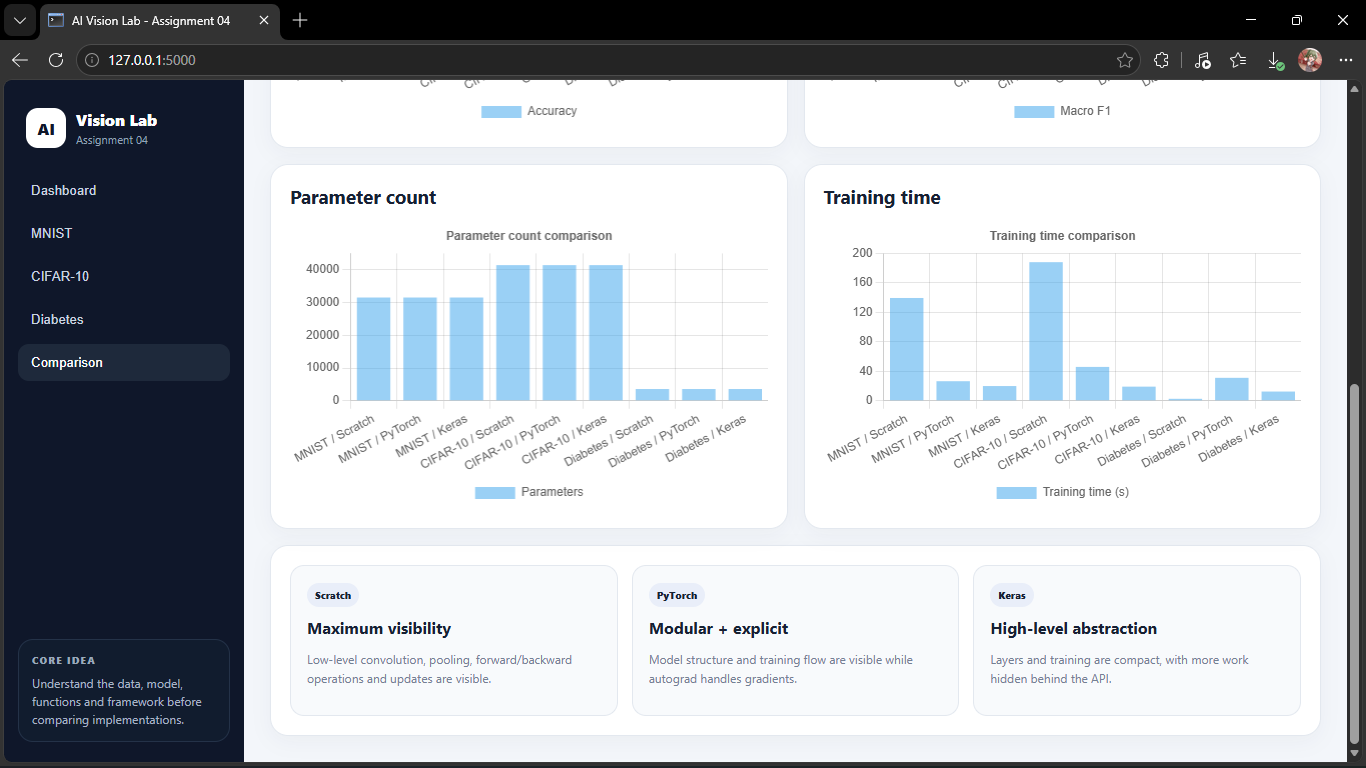